# Empirical Asset Pricing: Machine Learning Driven Dollar-Neutral Equity Strategy




Thanushree Keshava Murthy | tkeshava@purdue.edu

Agniva Mondal | mondal28@purdu.edu

In [ ]:
#@title Install packages

import warnings
warnings.filterwarnings("ignore")

In [ ]:
#@title Import Libraries and Set Seed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import PredefinedSplit, GridSearchCV
import lightgbm as lgb
from joblib import Parallel, delayed

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [ ]:
#@title Global Configuration and Plotting Setup

CONFIG = {
    "train_years": 10,
    "val_years": 5,
    "test_years": 1,
    "target_vol": 0.10,
    "vol_window": 36,
    "max_leverage": 3.0,
    "long_short_pct": 0.10,
    "monte_carlo_sims": 1000,
    "fig_dpi": 300,
    "fig_dir": "figures",
    # ── Runtime toggles (set these before Run All) ──
    "make_plots": True,
    "run_diagnostics": True,
    "run_regime_analysis": True,
    "run_monte_carlo": True,
    "run_smoke_tests": True,
    "monte_carlo_sims": 1000,
}

# Visualization style: Academic / Publication Quality (LaTeX-style)
plt.rcParams.update({
    "figure.dpi": CONFIG["fig_dpi"],
    "savefig.dpi": CONFIG["fig_dpi"],
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Academic Finance color palette
COLORS = {
    "primary": "#000000",      # Black (standard for academic plots)
    "secondary": "#555555",    # Dark Grey
    "accent": "#bf0000",       # Deep Red for contrast
    "neutral": "#888888",      # Light Grey
}

def save_plot(fig, filename):
    """Export figure as PNG for slides."""
    Path(CONFIG["fig_dir"]).mkdir(parents=True, exist_ok=True)
    path = Path(CONFIG["fig_dir"]) / filename
    fig.savefig(path, dpi=CONFIG["fig_dpi"], bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return str(path)

In [ ]:
# @title Data Load from Google Drive

import pandas as pd
from pathlib import Path
import os

# Mount Google Drive first if not already mounted
from google.colab import drive
drive.mount('/content/drive')

DATA_SOURCE = "gdrive_parquet"
# ACTION REQUIRED: Replace 'YourShortcutName' with the ACTUAL name of your folder in Drive
PARQUET_DIR = '/content/drive/MyDrive/Data 1_All samples'

FEATURES_PRENORMALISED = False

if DATA_SOURCE == "gdrive_parquet":
    print(f"Loading Parquet from: {PARQUET_DIR}")

    path = Path(PARQUET_DIR)

    # --- Debugging Helper ---
    if not path.exists():
        print(f"\nError: The folder '{PARQUET_DIR}' was not found.")
        print(" Listing available folders in '/content/drive/MyDrive/' to help you:")
        try:
            folders = [d for d in os.listdir('/content/drive/MyDrive') if os.path.isdir(os.path.join('/content/drive/MyDrive', d))]
            print(folders)
        except Exception as e:
            print(f"   (Could not list folders: {e})")
        print("\n INSTRUCTION: Copy the correct folder name from the list above and paste it into PARQUET_DIR.")
        raise FileNotFoundError(f"Directory {PARQUET_DIR} not found.")
    # ------------------------

    parquet_files = sorted(path.glob("**/*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(f"No parquet files found under {PARQUET_DIR}")

    dfs = []
    for f in parquet_files:
        _part = pd.read_parquet(f, engine="pyarrow")
        dfs.append(_part)
    df_raw = pd.concat(dfs, ignore_index=True)

    FEATURES_PRENORMALISED = True  # as per your comment

    # Standardise column: 'month' → 'date'
    if "month" in df_raw.columns and "date" not in df_raw.columns:
        df_raw.rename(columns={"month": "date"}, inplace=True)
    df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")

    # Drop hive partition helper cols if present
    if "year" in df_raw.columns:
        df_raw.drop(columns=["year"], inplace=True)

    df_raw.sort_values(["date", "permno"], inplace=True)
    df_raw.reset_index(drop=True, inplace=True)

    print(f"  Shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols")
    print(f"  Date  : {df_raw['date'].min()} → {df_raw['date'].max()}")
    print(f"  Stocks: {df_raw['permno'].nunique():,}")
    print("   Characteristics pre-normalised to [-1, 1]")

print(f"\n{'='*60}")
print(f"df_raw ready  |  {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols")
print(f"Pre-normalised: {FEATURES_PRENORMALISED}")
print(f"{'='*60}")

Mounted at /content/drive
Loading Parquet from: /content/drive/MyDrive/Data 1_All samples
  Shape : 702,523 rows × 180 cols
  Date  : 1957-01-01 00:00:00 → 1989-12-01 00:00:00
  Stocks: 11,429
   Characteristics pre-normalised to [-1, 1]

df_raw ready  |  702,523 rows × 180 cols
Pre-normalised: True


In [ ]:
#@title Data Validation + Working Copy
assert "ret_excess" in df_raw.columns or any(c.lower() == "ret_excess" for c in df_raw.columns), \
    "Target 'ret_excess' not found."
ret_col = "ret_excess" if "ret_excess" in df_raw.columns else [c for c in df_raw.columns if c.lower() == "ret_excess"][0]
df_raw.rename(columns={ret_col: "ret_excess"}, inplace=True)

df = df_raw.copy()
print(f"df initialised from df_raw: {df.shape[0]:,} rows, "
      f"date range {df['date'].min()} → {df['date'].max()}")

df initialised from df_raw: 702,523 rows, date range 1957-01-01 00:00:00 → 1989-12-01 00:00:00


In [ ]:
#@title Summary statistics for key columns
if CONFIG.get("run_diagnostics", True):
    numeric = df_raw.select_dtypes(include=[np.number]).columns
    summary = df_raw[numeric].describe().T[["mean", "std", "min", "max"]].round(4)
    display(summary.head(15))
else:
    print("Skipped (run_diagnostics=False)")

,mean,std,min,max
permno,40037.4810,21833.2972,10000.0000,93316.0000
ret_excess,0.0045,0.1552,-1.0000,10.1947
mktcap_lag,355.2863,1697.5207,0.0172,102022.2851
macro_dp,-3.3398,0.1871,-3.6452,-2.8680
macro_ep,-2.6168,0.2977,-3.1219,-1.8987
macro_bm,0.6225,0.2095,0.3705,1.1354
macro_ntis,0.0079,0.0186,-0.0285,0.0512
macro_tbl,0.0670,0.0281,0.0083,0.1630
macro_tms,0.0121,0.0148,-0.0365,0.0362
macro_dfy,0.0112,0.0043,0.0032,0.0218


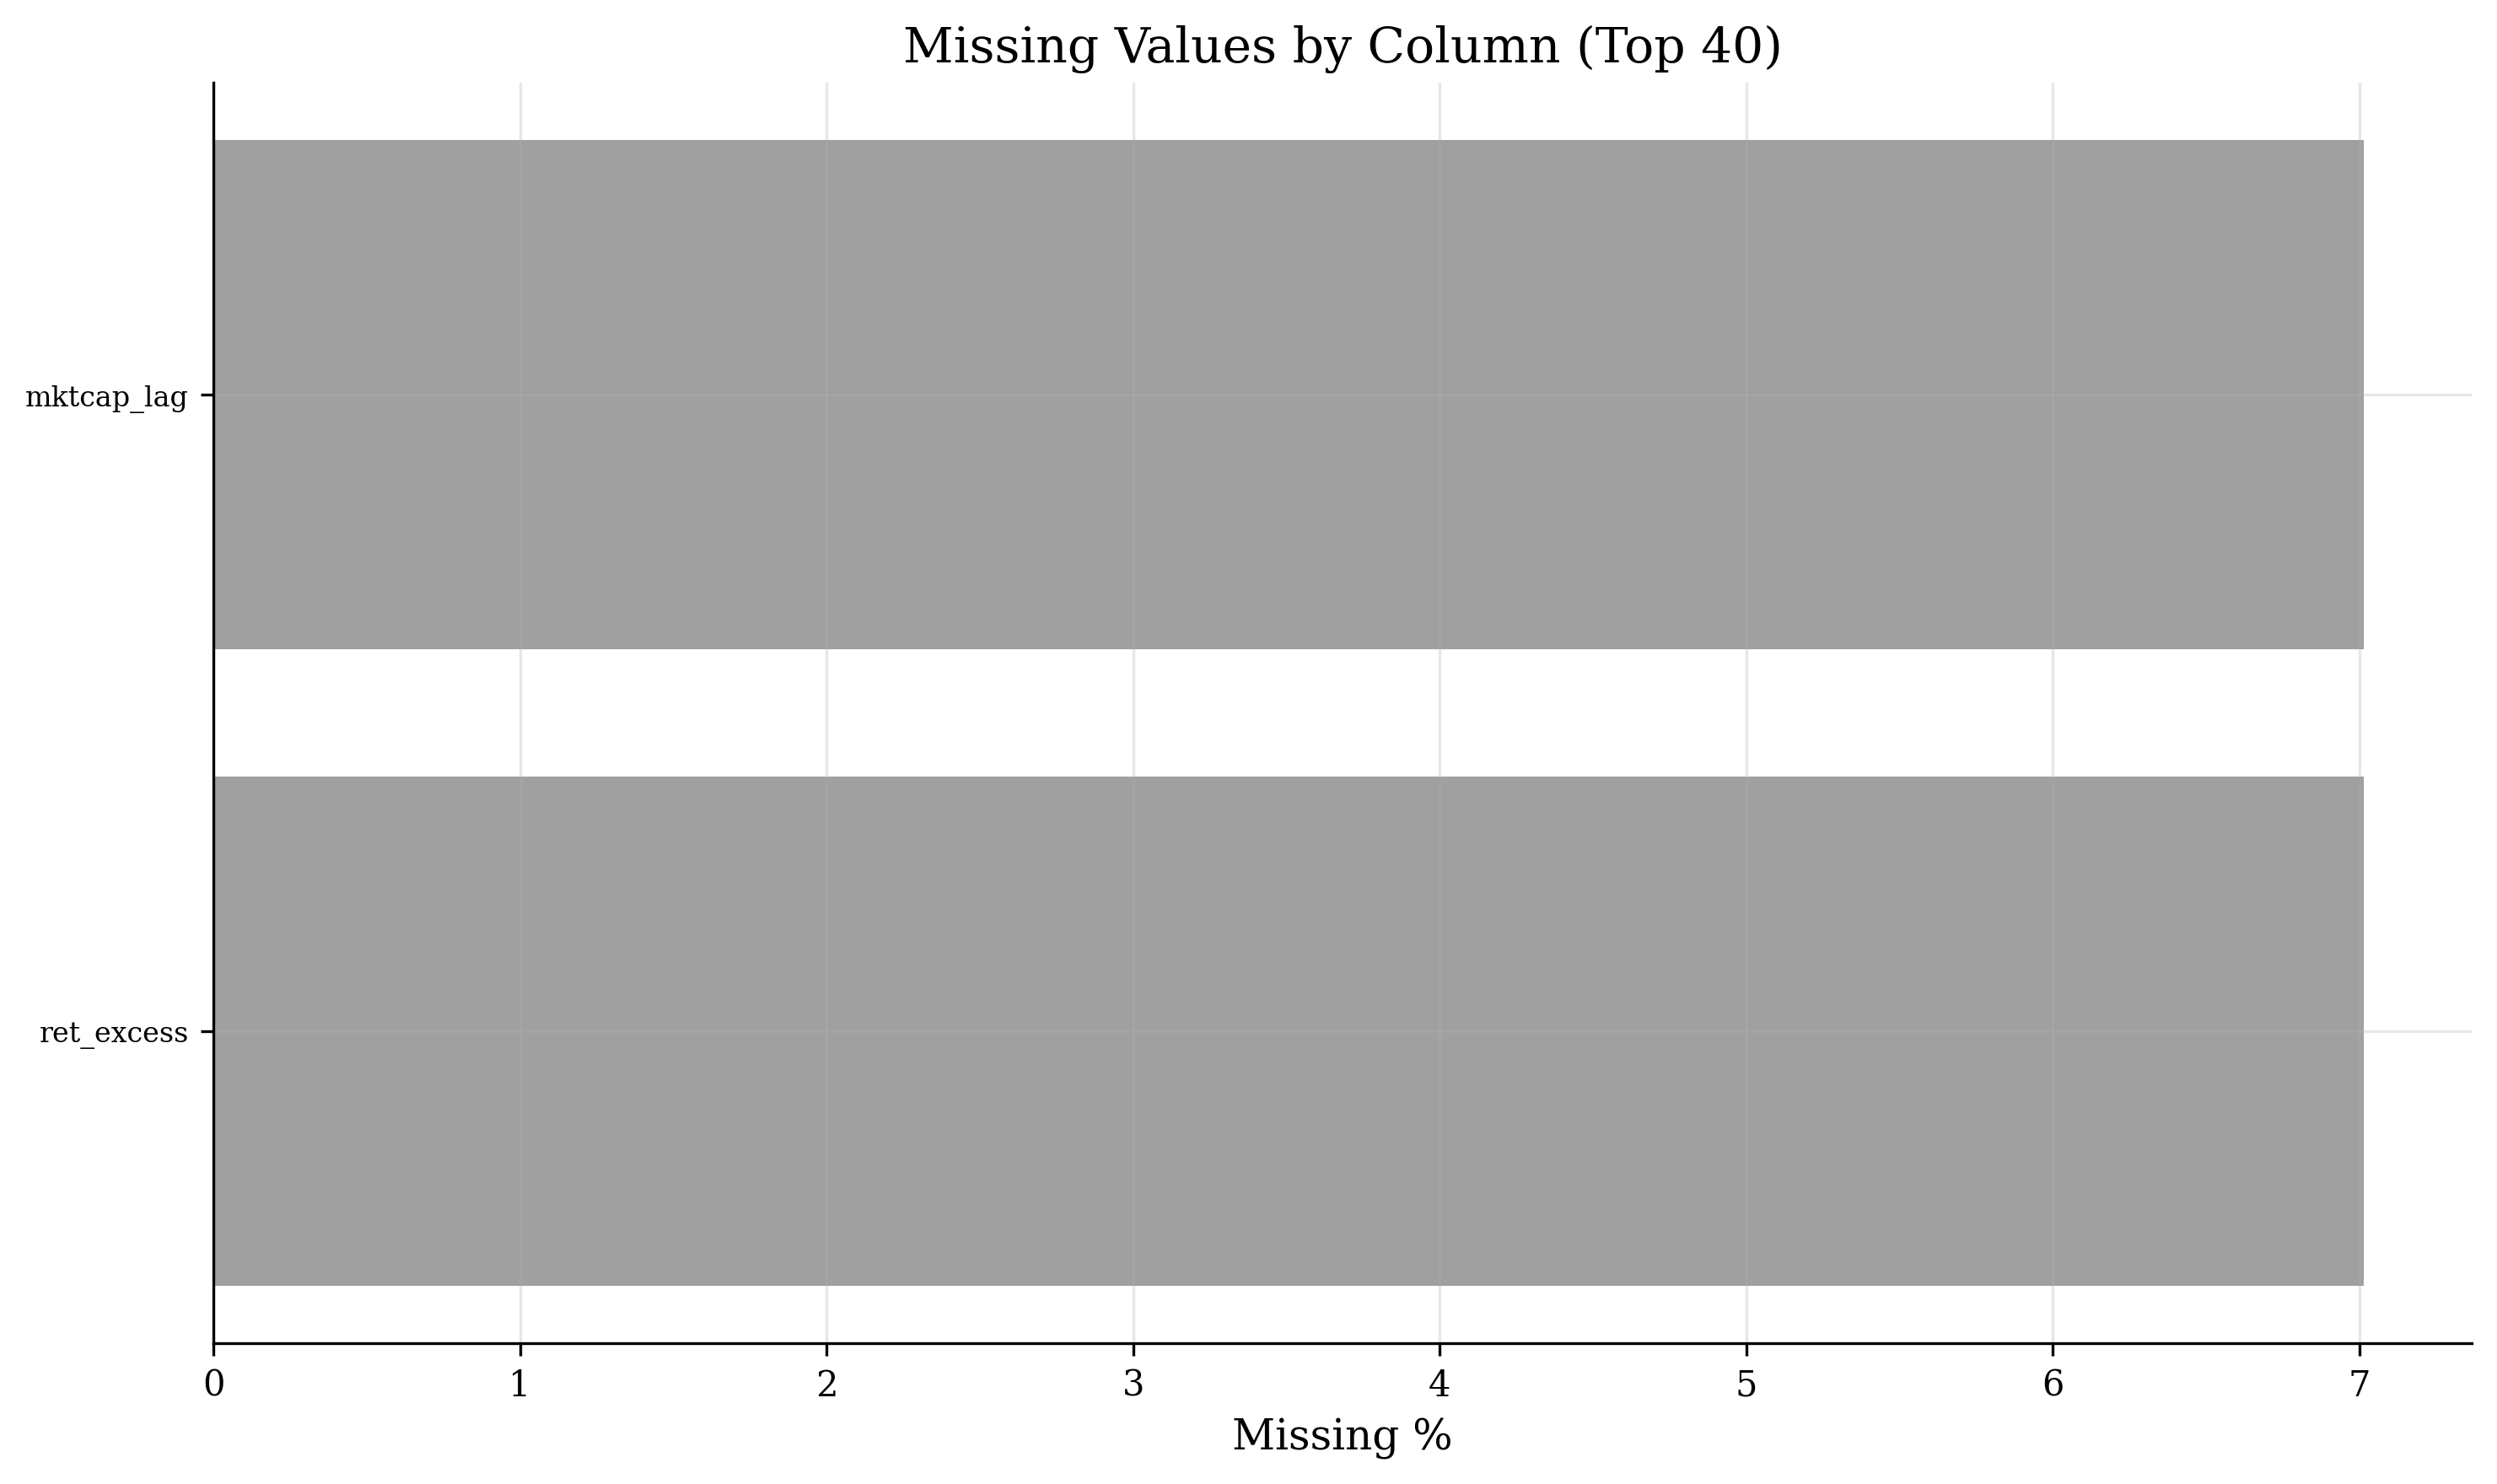

In [ ]:
#@title Missing value heatmap
if CONFIG.get("make_plots", True):
    missing = df_raw.isnull().mean()
    missing = missing[missing > 0].sort_values(ascending=False)
    plot_cols = missing.head(40).index.tolist()
    if plot_cols:
        fig, ax = plt.subplots(figsize=(10, 6))
        miss_vals = df_raw[plot_cols].isnull().mean().values * 100
        ax.barh(range(len(plot_cols)), miss_vals, color=COLORS["neutral"], alpha=0.8)
        ax.set_yticks(range(len(plot_cols)))
        ax.set_yticklabels(plot_cols, fontsize=8)
        ax.set_xlabel("Missing %")
        ax.set_title("Missing Values by Column (Top 40)")
        plt.tight_layout()
        plt.show()
    else:
        print("No missing values in numeric columns.")
else:
    print("Skipped (make_plots=False)")

In [ ]:
#@title FIX: Build feature_cols robustly (must be >0)
import numpy as np
import pandas as pd

# Replace df_model with the dataframe you actually use for training
df_model = df.copy()  # Uses `df` which was previously copied from `df_raw`

ID_COLS = ["date", "permno"]
TARGET_COLS = ["ret_excess", "ret_excess_lead"]

# Keep only numeric columns for modeling
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()

# Candidate features = numeric minus id/target
candidate = [c for c in numeric_cols if c not in set(ID_COLS + TARGET_COLS)]

# Drop all-NaN or constant columns
feature_cols = []
for c in candidate:
    s = df_model[c]
    if s.isna().all():
        continue
    if s.nunique(dropna=True) <= 1:
        continue
    feature_cols.append(c)

print("Numeric cols:", len(numeric_cols))
print("Candidate features:", len(candidate))
print("Final feature_cols:", len(feature_cols))
print("First 30:", feature_cols[:30])

# dtype audit
print("\nDtype counts:")
print(df_model.dtypes.value_counts())

assert len(feature_cols) >= 50, "feature_cols is too small — check column types and names."

# Clean up initial missing records
key_features = [c for c in feature_cols[:5] if c in df.columns]
if key_features:
    df = df.dropna(subset=key_features)


Numeric cols: 179
Candidate features: 177
Final feature_cols: 174
First 30: ['mktcap_lag', 'macro_dp', 'macro_ep', 'macro_bm', 'macro_ntis', 'macro_tbl', 'macro_tms', 'macro_dfy', 'macro_svar', 'characteristic_mvel1', 'characteristic_beta', 'characteristic_betasq', 'characteristic_chmom', 'characteristic_dolvol', 'characteristic_idiovol', 'characteristic_indmom', 'characteristic_mom1m', 'characteristic_mom6m', 'characteristic_mom12m', 'characteristic_mom36m', 'characteristic_pricedelay', 'characteristic_turn', 'characteristic_absacc', 'characteristic_acc', 'characteristic_age', 'characteristic_agr', 'characteristic_bm', 'characteristic_bm_ia', 'characteristic_cashdebt', 'characteristic_cashpr']

Dtype counts:
float64           104
int8               74
datetime64[ns]      1
int64               1
Name: count, dtype: int64


In [ ]:
#@title Data Integrity: Stable ID + Target Lead

date_col = "date"
ret_col = "ret_excess"

assert date_col in df.columns, f"Required column '{date_col}' missing."
assert ret_col in df.columns, f"Required column '{ret_col}' missing."

ID_CANDIDATES = ["permno", "id", "ticker", "gvkey", "cusip", "permco"]
id_col = None
for c in ID_CANDIDATES:
    if c in df.columns:
        id_col = c
        break
if id_col is None:
    raise ValueError(
        "No stable ID column found (permno, id, ticker, gvkey, cusip, permco). "
        "Do not fabricate IDs per date."
    )

if id_col != "permno":
    df["permno"] = df[id_col]

df = df.sort_values([id_col, date_col]).copy()
df["ret_excess_lead"] = df.groupby(id_col)[ret_col].shift(-1)
df = df.dropna(subset=["ret_excess_lead"]).copy()

In [ ]:
#@title Feature List and Dataset Preparation

def get_unique_months_sorted(df, date_col="date"):
    return np.sort(df[date_col].dropna().unique())

def generate_rolling_windows(months, train_years=10, val_years=5, test_years=1):
    n = len(months)
    train_months = train_years * 12
    val_months = val_years * 12
    test_months = test_years * 12
    step = test_months
    start = 0
    trials = []
    while start + train_months + val_months + test_months <= n:
        train_end = start + train_months
        val_end = train_end + val_months
        test_end = val_end + test_months
        trials.append((start, train_end, val_end, test_end))
        start += step
    return trials

# ── Precompute once: X, y, date arrays + month→row index map ──
_PRECOMP = {}

def precompute_arrays(df: pd.DataFrame, feature_cols: list,
                      target: str = "ret_excess_lead", date_col: str = "date"):
    """Build float32 NumPy arrays and a month→row-indices dict once."""
    if _PRECOMP.get("ready"):
        return
    X_all = df[feature_cols].values.astype(np.float32)
    y_all = df[target].values.astype(np.float32)
    dates_all = df[date_col].values

    month_to_rows = {}
    for month in np.unique(dates_all):
        month_to_rows[month] = np.where(dates_all == month)[0]

    _PRECOMP.update({
        "X": X_all, "y": y_all, "dates": dates_all,
        "month_to_rows": month_to_rows, "ready": True,
    })
    print(f"Precomputed: X {X_all.shape} float32, "
          f"{len(month_to_rows)} months indexed")

def split_train_val_test(df, months, start, train_end, val_end, test_end,
                         date_col="date", target="ret_excess_lead",
                         id_col="permno", features=None):
    """Strict time split using precomputed arrays — no DataFrame slicing."""
    precompute_arrays(df, features or [], target, date_col)
    P = _PRECOMP
    X_all, y_all = P["X"], P["y"]
    m2r = P["month_to_rows"]

    def _gather(month_slice):
        idx = np.concatenate([m2r[m] for m in month_slice if m in m2r])
        return X_all[idx], y_all[idx], idx

    train_dates = months[start:train_end]
    val_dates   = months[train_end:val_end]
    test_dates  = months[val_end:test_end]

    X_tr, y_tr, _ = _gather(train_dates)
    X_va, y_va, _ = _gather(val_dates)
    X_te, y_te, idx_te = _gather(test_dates)

    test_df = df.iloc[idx_te][["date", "permno", "ret_excess_lead"]]

    return (X_tr, y_tr), (X_va, y_va), (X_te, y_te), test_df, test_dates

In [ ]:
#@title Cross-Sectional Preprocessing

def preprocess_features_cross_sectional(df: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    print(f"Running cross-sectional standardization on {len(feature_cols)} features...")
    df_proc = df.copy()

    def process_month(grp):
        # Winsorize 1% and 99%
        lower = grp[feature_cols].quantile(0.01)
        upper = grp[feature_cols].quantile(0.99)
        grp_clip = grp[feature_cols].clip(lower, upper, axis=1)
        # Z-score standardize
        mean = grp_clip.mean()
        std = grp_clip.std().replace(0, 1) # avoid div by zero
        grp[feature_cols] = (grp_clip - mean) / std
        return grp[feature_cols]

    df_proc[feature_cols] = df_proc.groupby("date", group_keys=False).apply(process_month)

    # Sanity print for 2 random months
    dates = df_proc["date"].unique()
    if len(dates) >= 2:
        check_dates = np.random.choice(dates, 2, replace=False)
        for d in check_dates:
            d_str = np.datetime_as_string(d, unit='D') if isinstance(d, np.datetime64) else str(d)
            subset = df_proc[df_proc["date"] == d][feature_cols]
            print(f"Sanity Check [Date: {d_str}]: Mean ≈ {subset.mean().mean():.4f}, Std ≈ {subset.std().mean():.4f}")

    return df_proc

In [ ]:
#@title Cross-Sectional Median Imputation

def cross_sectional_median_impute(df: pd.DataFrame, feature_cols: list, date_col: str = 'date') -> pd.DataFrame:
    """Performs fast cross-sectional median imputation without data leakage."""
    print(f"Running cross-sectional median imputation on {len(feature_cols)} features...")
    df_out = df.copy()

    # Calculate median by date
    date_medians = df_out.groupby(date_col)[feature_cols].median()

    # Forward fill if entirely missing, then fill 0 for absolute first available date
    date_medians = date_medians.ffill().fillna(0)

    # Fast vectorized assignment
    orig_idx = df_out.index
    df_out = df_out.set_index(date_col)

    df_out[feature_cols] = df_out[feature_cols].fillna(date_medians)

    df_out = df_out.reset_index()
    df_out.index = orig_idx

    return df_out


df = cross_sectional_median_impute(df, feature_cols, date_col="date")
# Call immediately after features are defined
df = preprocess_features_cross_sectional(df, feature_cols)

months = get_unique_months_sorted(df)
trials = generate_rolling_windows(months, CONFIG["train_years"], CONFIG["val_years"], CONFIG["test_years"])
print(f"\n{len(months)} unique months: {months[0]} → {months[-1]}")
print(f"{len(trials)} rolling windows → OOS predictions from ~month {trials[0][2]} to {trials[-1][3]}")

Running cross-sectional median imputation on 174 features...
Running cross-sectional standardization on 174 features...
Sanity Check [Date: 1968-02-01]: Mean ≈ 0.0000, Std ≈ 0.6034
Sanity Check [Date: 1962-10-01]: Mean ≈ -0.0059, Std ≈ 0.3736

265 unique months: 1957-01-01T00:00:00.000000000 → 1989-11-01T00:00:00.000000000
7 rolling windows → OOS predictions from ~month 180 to 264


In [ ]:
#@title Cross-Sectional Imputation and Standardization

from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error, r2_score

def fit_elastic_net(X_train: np.ndarray, y_train: pd.Series, X_val: np.ndarray, y_val: pd.Series):
    """Small grid, choose best by validation R2. Retry logic if 0 coefs."""
    alphas = [1e-4, 1e-3, 1e-2]
    l1_ratios = [0.5, 0.9]
    best_r2, best_params = -np.inf, {"alpha": 1e-4, "l1_ratio": 0.5}

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_train)
    X_va_s = scaler.transform(X_val)

    for a in alphas:
        for l1 in l1_ratios:
            model = ElasticNet(alpha=a, l1_ratio=l1, max_iter=1000, tol=1e-3, random_state=RANDOM_SEED)
            model.fit(X_tr_s, y_train)
            pred = model.predict(X_va_s)
            r2 = r2_score(y_val, pred)

            if r2 > best_r2:
                best_r2, best_params = r2, {"alpha": a, "l1_ratio": l1}

    X_combined = np.vstack([X_train, X_val])
    y_combined = np.concatenate([np.asarray(y_train), np.asarray(y_val)])
    scaler_comb = StandardScaler()
    X_comb_s = scaler_comb.fit_transform(X_combined)

    best_a = best_params["alpha"]
    best_l1 = best_params["l1_ratio"]

    model_comb = ElasticNet(alpha=best_a, l1_ratio=best_l1, max_iter=1000, tol=1e-3, random_state=RANDOM_SEED)
    model_comb.fit(X_comb_s, y_combined)

    nonzero_coefs = np.sum(np.abs(model_comb.coef_) > 1e-7)

    # Aggressive fallback to prevent 0 coefficients
    while nonzero_coefs == 0 and best_a > 1e-8:
        best_a = best_a / 10.0
        model_comb = ElasticNet(alpha=best_a, l1_ratio=best_l1, max_iter=1000, tol=1e-3, random_state=RANDOM_SEED)
        model_comb.fit(X_comb_s, y_combined)
        nonzero_coefs = np.sum(np.abs(model_comb.coef_) > 1e-7)

    # Absolute ultimate fallback to pure Ridge (L2 only) to force non-zero continuous predictions
    if nonzero_coefs == 0:
        from sklearn.linear_model import Ridge
        model_comb = Ridge(alpha=1.0, random_state=RANDOM_SEED)
        model_comb.fit(X_comb_s, y_combined)
        nonzero_coefs = np.sum(np.abs(model_comb.coef_) > 1e-7)

    l1_norm = np.sum(np.abs(model_comb.coef_))

    pipe = Pipeline([
        ("scaler", scaler_comb),
        ("model", model_comb)
    ])
    pipe.diag_dict_ = {
        "alpha": best_a,
        "l1_ratio": best_l1,
        "nonzero_coef_count": int(nonzero_coefs),
        "l1_norm": float(l1_norm)
    }
    return pipe

def fit_lightgbm(X_train: np.ndarray, y_train: pd.Series, X_val: np.ndarray, y_val: pd.Series):
    """Finance-safe regularized LightGBM."""
    model = lgb.LGBMRegressor(
        objective="regression",
        max_depth=4,
        num_leaves=15,
        learning_rate=0.05,
        min_child_samples=50,  # Ensure we don't over-restrict leaf size and bin predictions
        feature_fraction=0.7,
        bagging_fraction=0.7,
        bagging_freq=1,
        lambda_l2=5.0,
        n_estimators=50,
        n_jobs=-1,      # Run exactly 100 trees to ensure dispersion
        random_state=RANDOM_SEED,
        verbosity=-1,
    )
    # Fit WITHOUT early stopping to guarantee continuous distinct predictions
    model.fit(X_train, y_train)
    return model


In [ ]:
#@title Rolling Backtest and Prediction Alignment

import time as _time
from sklearn.metrics import r2_score
r2_records_enet = []
r2_records_lgbm = []

def run_rolling_backtest(df: pd.DataFrame, months: np.ndarray, trials: list,
                         feature_cols: list, model_type: str = "elastic_net") -> pd.DataFrame:
    """Rolling OOS backtest. Precomputed float32 arrays, no redundant .values calls."""
    precompute_arrays(df, feature_cols)

    preds_list = []
    n_trials = len(trials)
    t0 = _time.perf_counter()

    print(f"[{model_type}] {len(feature_cols)} features, {n_trials} windows")

    for wi, (start, train_end, val_end, test_end) in enumerate(trials):
        (X_tr, y_tr), (X_va, y_va), (X_te, y_te), test_df, test_dates = \
            split_train_val_test(df, months, start, train_end, val_end, test_end,
                                features=feature_cols)

        if model_type == "elastic_net":
            model = fit_elastic_net(X_tr, y_tr, X_va, y_va)
            pred_test = model.predict(X_te)
            y_pred_val = model.predict(X_va)
            end_date = test_dates[-1] if len(test_dates) else None
            diag = model.diag_dict_
            diag["window_end"] = end_date
            diag["r2_val"] = r2_score(y_va, y_pred_val)
            diag["r2_oos"] = r2_score(y_te, pred_test)
            r2_records_enet.append(diag)
        else:
            model = fit_lightgbm(X_tr, y_tr, X_va, y_va)
            pred_test = model.predict(X_te)
            y_pred_val = model.predict(X_va)
            end_date = test_dates[-1] if len(test_dates) else None
            r2_records_lgbm.append({
                "window_end": end_date,
                "r2_val": r2_score(y_va, y_pred_val),
                "r2_oos": r2_score(y_te, pred_test),
            })

        assert len(pred_test) == len(test_df), "pred_test and test_df length mismatch"

        out = test_df[["date", "permno", "ret_excess_lead"]].copy()
        out["prediction"] = pred_test
        preds_list.append(out)

    final_df = pd.concat(preds_list, ignore_index=True)

    final_nunique = final_df.groupby("date")["prediction"].nunique().mean()
    elapsed = _time.perf_counter() - t0
    print(f"[{model_type}] Done in {elapsed:.1f}s  |  avg unique preds/month: {final_nunique:.1f}")
    assert final_nunique > 5.0, f"Unique preds too low ({final_nunique:.2f})"

    return final_df

# Smoke test: 1 trial window
_n_enet, _n_lgbm = len(r2_records_enet), len(r2_records_lgbm)
_single_trial = [trials[0]] if trials else []
if _single_trial and CONFIG.get("run_diagnostics", True):
    _preds = run_rolling_backtest(df, months, _single_trial, feature_cols, "elastic_net")
    print("Smoke test (1 window):")
    print(_preds.head())
    print(f"Rows returned: {len(_preds)}")
r2_records_enet, r2_records_lgbm = r2_records_enet[:_n_enet], r2_records_lgbm[:_n_lgbm]


Precomputed: X (642848, 174) float32, 265 months indexed
[elastic_net] 174 features, 1 windows
[elastic_net] Done in 8.2s  |  avg unique preds/month: 3899.1
Smoke test (1 window):
        date  permno  ret_excess_lead  prediction
0 1974-07-01   10006        -0.160084   -0.006744
1 1974-07-01   10014        -0.159846    0.000924
2 1974-07-01   10057        -0.147176    0.001548
3 1974-07-01   10058        -0.369636   -0.000378
4 1974-07-01   10102         0.060340    0.002523
Rows returned: 46790


In [ ]:
#@title Generating backtest

print("Generating ElasticNet backtest...")
preds_df_enet = run_rolling_backtest(df, months, trials, feature_cols, "elastic_net")

print("\n--- ElasticNet Coefficient Diagnostics ---")
diag_df = pd.DataFrame(r2_records_enet)
if not diag_df.empty:
    print(diag_df[["window_end", "alpha", "l1_ratio", "nonzero_coef_count", "l1_norm", "r2_val", "r2_oos"]].to_string())
else:
    print("No ElasticNet records found.")

print("\nGenerating LightGBM backtest...")
preds_df_lgbm = run_rolling_backtest(df, months, trials, feature_cols, "lightgbm")

preds_df = preds_df_lgbm.copy()  # Use LGBM as baseline for rest if needed, or ENet
if preds_df.empty:
    test_dates = months[trials[-1][2]:trials[-1][3]]
    preds_df = df[df["date"].isin(test_dates)][["date", "permno", "ret_excess_lead"]].copy()
    preds_df["prediction"] = np.random.randn(len(preds_df)) * 0.01


Generating ElasticNet backtest...
[elastic_net] 174 features, 7 windows
[elastic_net] Done in 74.8s  |  avg unique preds/month: 557.9

--- ElasticNet Coefficient Diagnostics ---
  window_end  alpha  l1_ratio  nonzero_coef_count   l1_norm    r2_val    r2_oos
0 1975-06-01  0.001       0.9                  18  0.028855  0.008101 -0.025568
1 1980-06-01  0.010       0.5                   1  0.001649 -0.001656  0.006913
2 1981-08-01  0.010       0.5                   1  0.006141  0.002528 -0.000862
3 1986-10-01  0.010       0.5                   1  0.005163  0.002918 -0.000194
4 1987-10-01  0.010       0.5                   1  0.004604  0.002592 -0.009453
5 1988-10-01  0.010       0.9                   2  0.002938  0.004620 -0.003908
6 1989-10-01  0.010       0.5                   2  0.008065  0.010667 -0.000232

Generating LightGBM backtest...
[lightgbm] 174 features, 7 windows
[lightgbm] Done in 64.4s  |  avg unique preds/month: 2987.6


### R² summary table ###


,r2_val_mean,r2_oos_mean,r2_oos_std
ElasticNet,0.004253,-0.004757,0.010397
LightGBM,-0.107144,-0.053001,0.062547


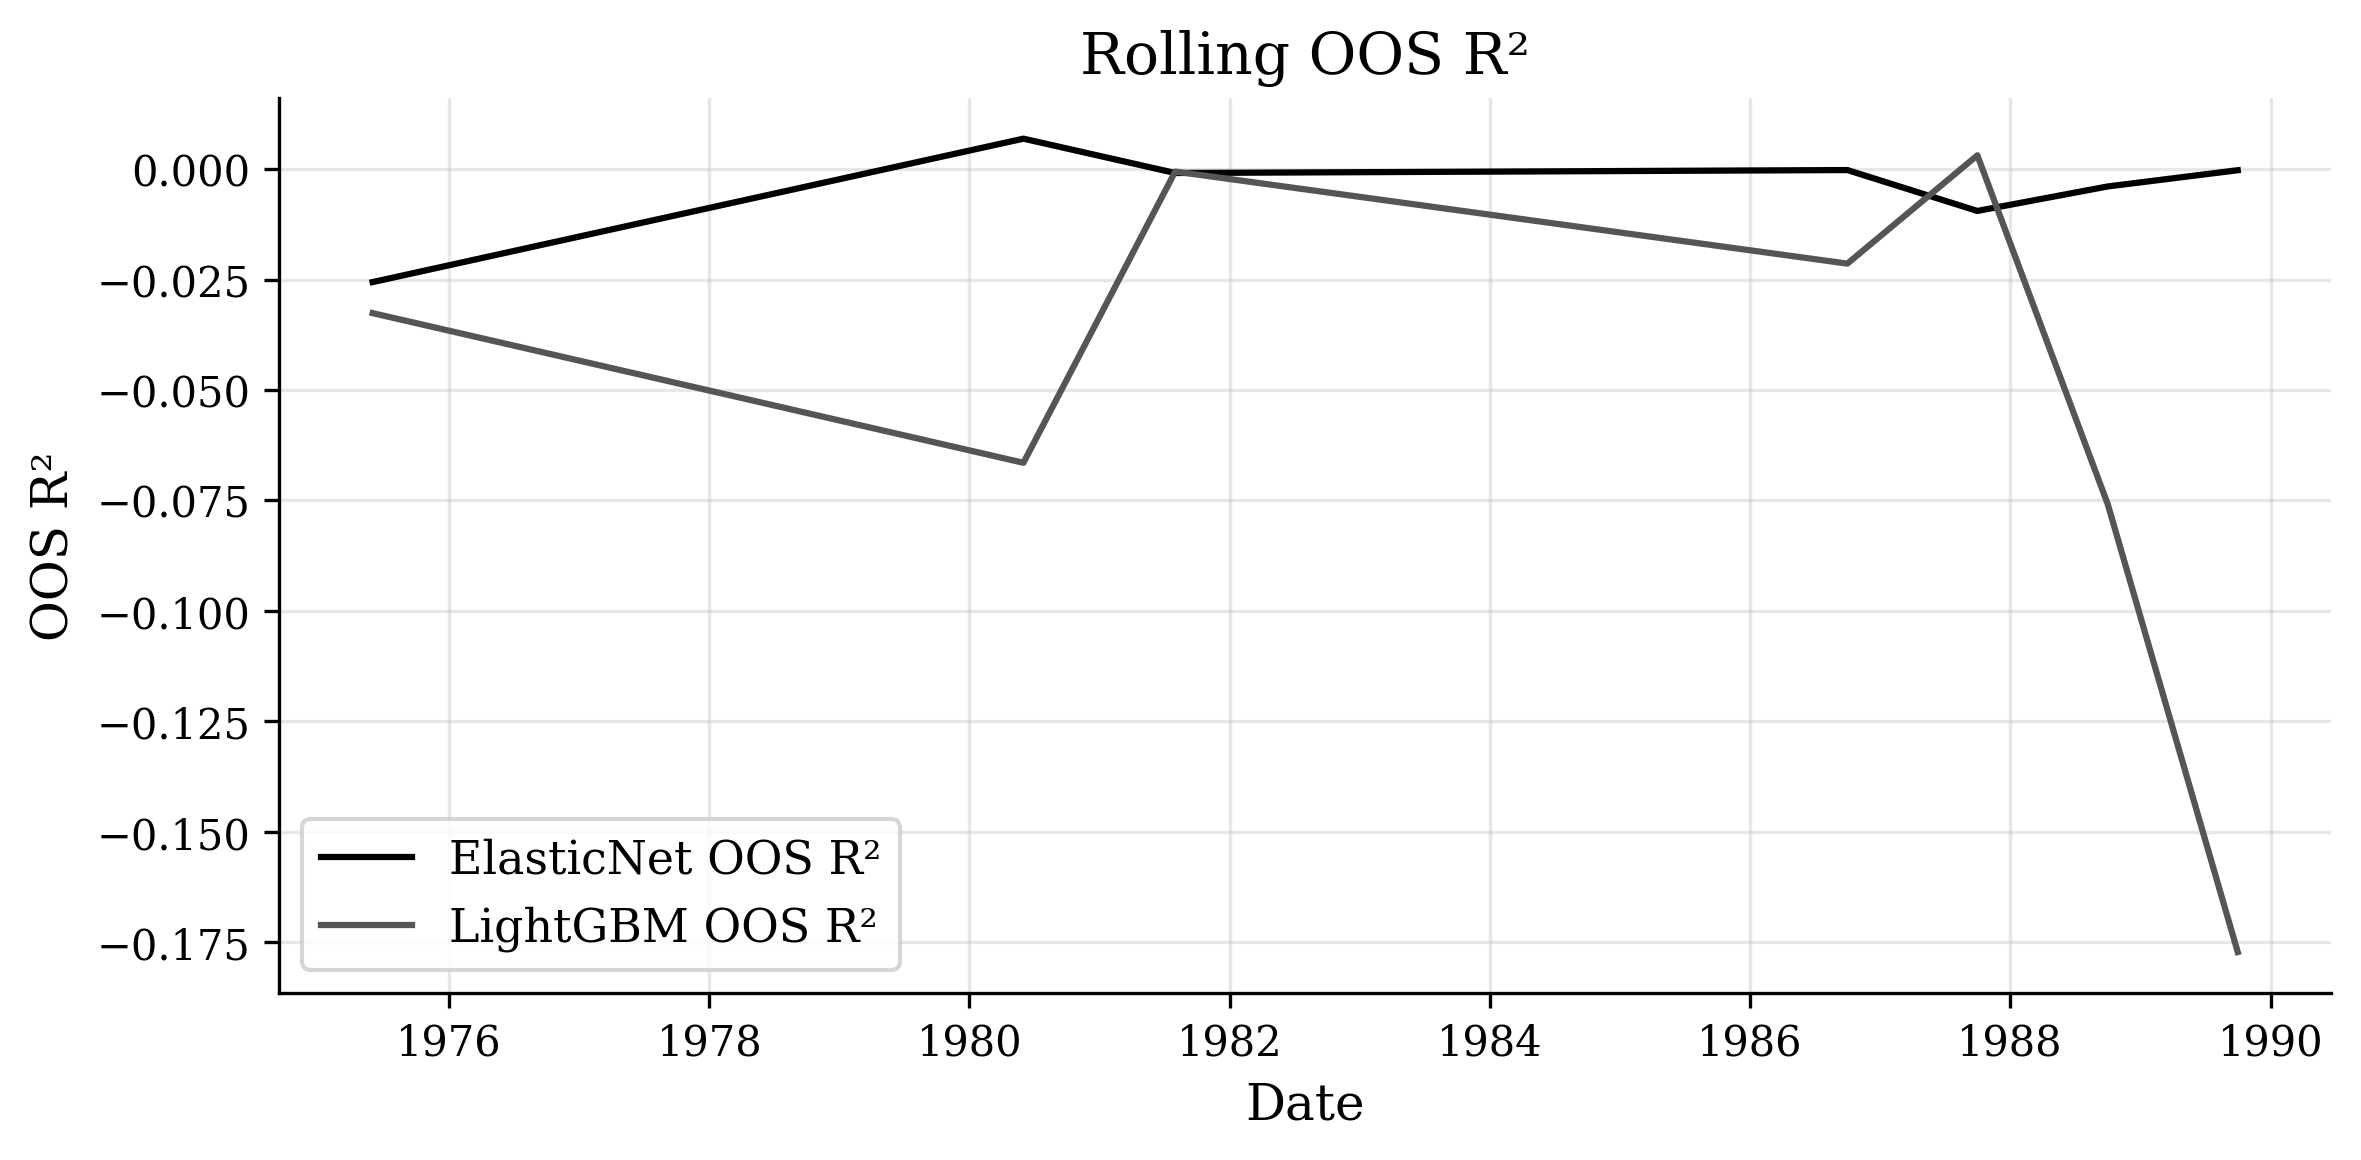

In [ ]:
#@title Add R² tracking

r2_df_enet = pd.DataFrame(r2_records_enet)
r2_df_lgbm = pd.DataFrame(r2_records_lgbm)

if not r2_df_enet.empty and not r2_df_lgbm.empty:
    r2_table = pd.DataFrame({
        "ElasticNet": {"r2_val_mean": r2_df_enet["r2_val"].mean(), "r2_oos_mean": r2_df_enet["r2_oos"].mean(), "r2_oos_std": r2_df_enet["r2_oos"].std()},
        "LightGBM": {"r2_val_mean": r2_df_lgbm["r2_val"].mean(), "r2_oos_mean": r2_df_lgbm["r2_oos"].mean(), "r2_oos_std": r2_df_lgbm["r2_oos"].std()}
    }).T
    print("### R² summary table ###")
    display(r2_table)

    if CONFIG.get("make_plots", True):
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(r2_df_enet["window_end"], r2_df_enet["r2_oos"], label="ElasticNet OOS R²", color=COLORS["primary"])
        ax.plot(r2_df_lgbm["window_end"], r2_df_lgbm["r2_oos"], label="LightGBM OOS R²", color=COLORS["secondary"])
        ax.set_ylabel("OOS R²")
        ax.set_xlabel("Date")
        ax.set_title("Rolling OOS R²")
        ax.legend()
        plt.tight_layout()
        plt.show()

In [ ]:
#@title DEBUG: Verify Portfolio Returns and Sign Changes

if not CONFIG.get("run_diagnostics", True):
    print("Skipped (run_diagnostics=False)")
else:
    pct = CONFIG["long_short_pct"]
    pred_col = "prediction" if "prediction" in preds_df_lgbm.columns else "pred"

    clean = preds_df_lgbm.dropna(subset=[pred_col, "ret_excess_lead"])
    dates_arr = clean["date"].values
    preds_v  = clean[pred_col].values.astype(np.float32)
    rets_v   = clean["ret_excess_lead"].values.astype(np.float32)

    unique_dates = np.unique(dates_arr)
    ls_rets = np.empty(len(unique_dates), dtype=np.float64)

    for i, dt in enumerate(unique_dates):
        mask = dates_arr == dt
        p, r = preds_v[mask], rets_v[mask]
        if len(p) < 10:
            ls_rets[i] = np.nan
            continue
        k = int(np.floor(len(p) * pct))
        if k < 1:
            ls_rets[i] = np.nan
            continue
        idx = np.argpartition(p, (k, len(p) - k))
        ls_rets[i] = r[idx[-k:]].mean() - r[idx[:k]].mean()

    valid = ~np.isnan(ls_rets)
    print(f"DEBUG: std={np.std(ls_rets[valid]):.6f}, "
          f"sign_changes={int((np.diff(np.sign(ls_rets[valid])) != 0).sum())} / {int(valid.sum())} months")


DEBUG: std=0.044380, sign_changes=36 / 84 months


### Sharpe Bootstrap Confidence Intervals (Block Bootstrap) ###
Portfolio: 0 months skipped (k<1), 72 zero-std months
Portfolio: 0 months skipped (k<1), 0 zero-std months
ENet Obs Sharpe: 0.0134 | Boot Mean: 0.0607
LGBM Obs Sharpe: 0.8228 | Boot Mean: 1.1538


,sharpe_obs,sharpe_boot_mean,sharpe_ci_low_95,sharpe_ci_high_95
Model,,,,
ElasticNet,0.013377,0.060684,-0.737835,0.628076
LightGBM,0.822771,1.153771,0.583391,1.733069


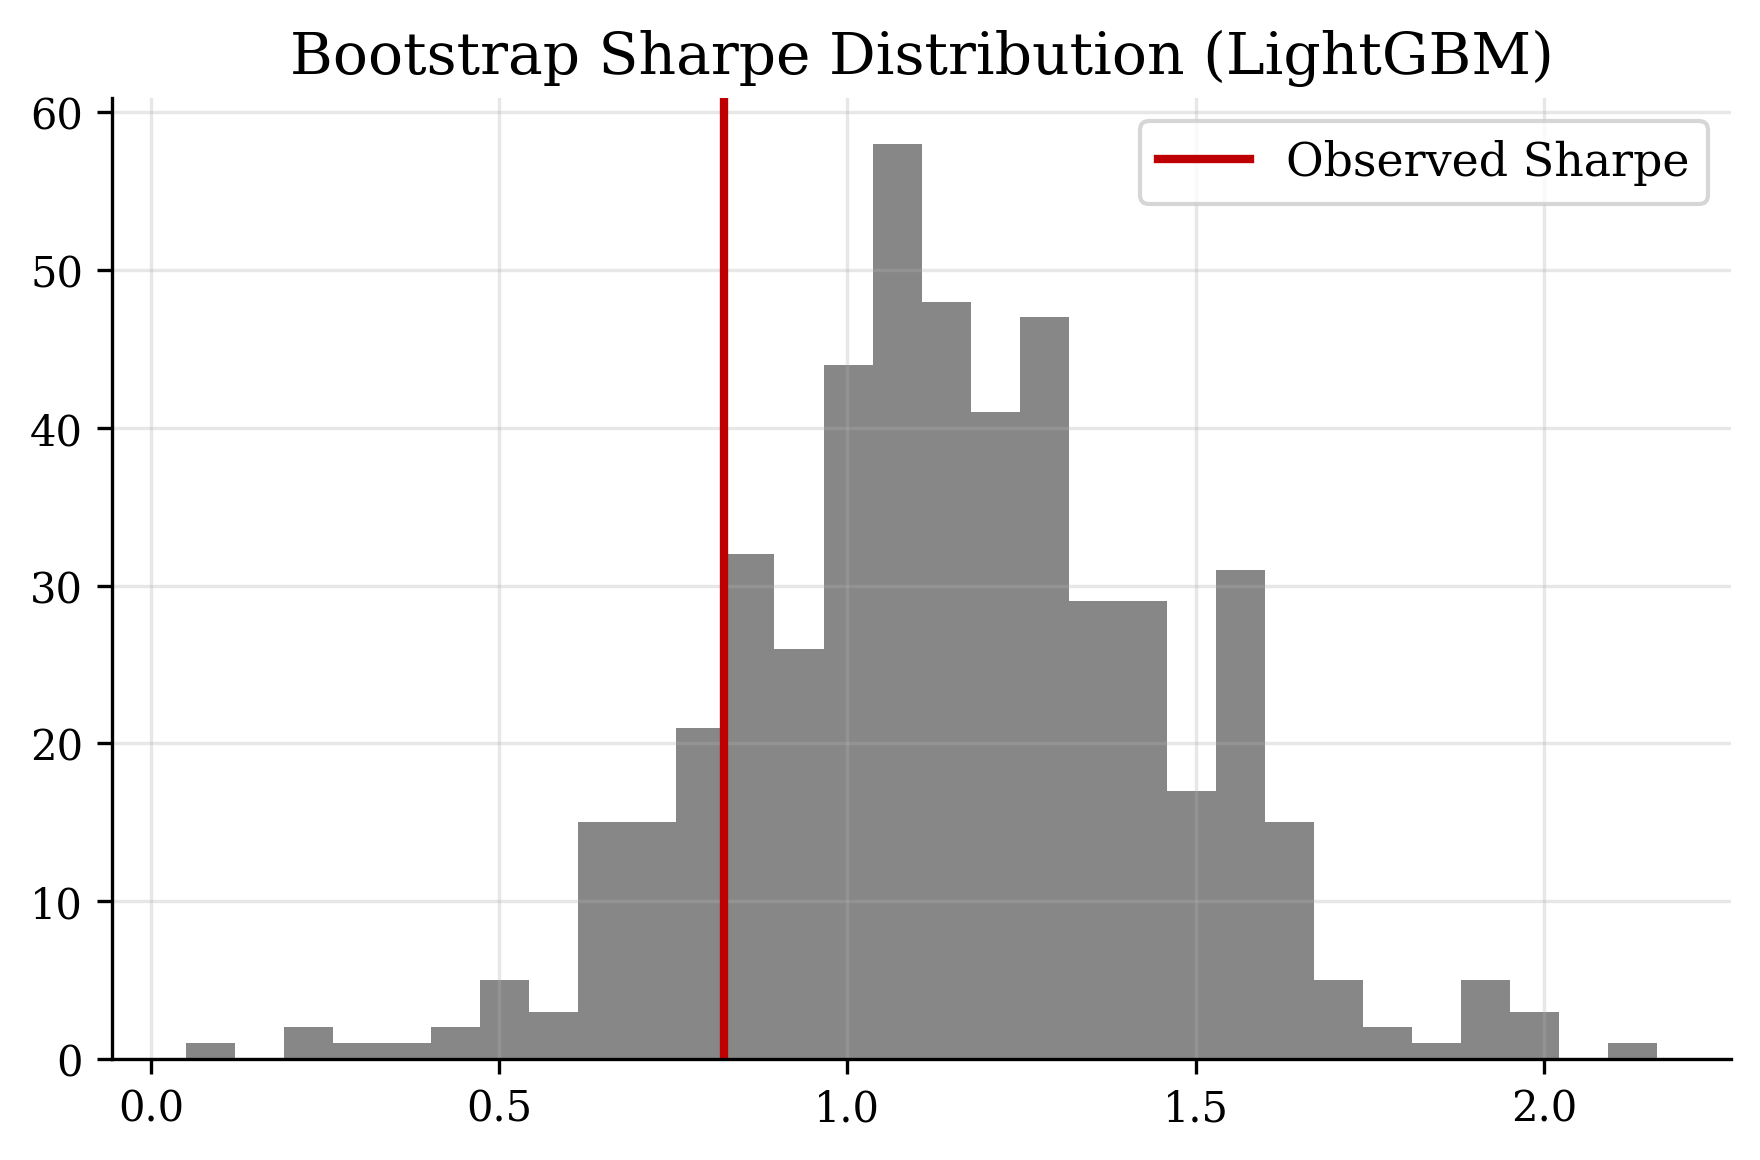

In [ ]:
#@title Sharpe Bootstrap + Vectorized Portfolio Construction
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# ── Helper functions (defined once) ──
def annualized_sharpe(r: pd.Series) -> float:
    r_drop = r.dropna()
    if len(r_drop) < 2:
        return np.nan
    std = r_drop.std(ddof=1)
    return (np.sqrt(12) * r_drop.mean() / std) if std > 0 else np.nan

def compute_turnover(weight_matrix: pd.DataFrame) -> tuple:
    if weight_matrix.empty or len(weight_matrix) < 2:
        return np.nan, np.nan
    w = weight_matrix.pivot_table(index="date", columns="permno", values="weight", fill_value=0)
    w = w.sort_index()
    turnover_t = 0.5 * w.diff().abs().sum(axis=1).dropna()
    if turnover_t.empty:
        return np.nan, np.nan
    avg = turnover_t.mean()
    return avg, avg * 12

def performance_metrics(returns: pd.Series, weight_matrix: pd.DataFrame = None,
                        periods_per_year: int = 12) -> dict:
    r = returns.dropna()
    n = len(r)
    if n == 0:
        return {}
    ann_ret = (1 + r).prod() ** (periods_per_year / n) - 1
    ann_vol = r.std() * np.sqrt(periods_per_year)
    sharpe = annualized_sharpe(r)
    downside_r = r[r < 0]
    downside_vol = downside_r.std() * np.sqrt(periods_per_year) if not downside_r.empty else np.nan
    sortino = ann_ret / downside_vol if downside_vol > 0 else np.nan
    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1
    roll_std = r.rolling(36, min_periods=12).std().replace(0, np.nan)
    roll_sharpe = r.rolling(36, min_periods=12).mean() / roll_std * np.sqrt(12)
    avg_turnover, ann_turnover = compute_turnover(weight_matrix) if weight_matrix is not None else (np.nan, np.nan)
    return {
        "Ann Return": ann_ret, "Ann Vol": ann_vol, "Sharpe": sharpe,
        "Sortino": sortino, "Skewness": r.skew(), "Kurtosis": r.kurtosis(),
        "Max DD": dd.min(), "rolling_sharpe": roll_sharpe, "Turnover": ann_turnover,
    }

# ── Vectorized portfolio construction (zero iterrows) ──
def construct_long_short_portfolio(predictions: pd.DataFrame, pct: float = 0.10) -> tuple:
    pred_col = "prediction" if "prediction" in predictions.columns else "pred"
    clean = predictions.dropna(subset=[pred_col, "ret_excess_lead"])

    dates_arr = clean["date"].values
    preds_arr = clean[pred_col].values.astype(np.float32)
    rets_arr  = clean["ret_excess_lead"].values.astype(np.float32)
    perms_arr = clean["permno"].values

    unique_dates = np.unique(dates_arr)
    n_dates = len(unique_dates)

    ret_dates = np.empty(n_dates, dtype="datetime64[ns]")
    ret_vals  = np.empty(n_dates, dtype=np.float64)

    w_date_parts  = []
    w_perm_parts  = []
    w_weight_parts = []

    skipped_k = 0
    zero_std = 0

    for i, dt in enumerate(unique_dates):
        mask = dates_arr == dt
        p = preds_arr[mask]
        r = rets_arr[mask]
        pm = perms_arr[mask]
        n = len(p)

        ret_dates[i] = dt

        if n == 0:
            ret_vals[i] = np.nan
            continue
        if np.std(p) < 1e-8:
            zero_std += 1

        k = int(np.floor(n * pct))
        if k < 1:
            skipped_k += 1
            ret_vals[i] = np.nan
            continue

        # O(n) dual partition: guarantees both tails are exact
        idx_part = np.argpartition(p, (k, n - k))
        bot_idx = idx_part[:k]
        top_idx = idx_part[-k:]

        w_long  = np.float32(1.0 / k)
        w_short = np.float32(-1.0 / k)

        w_date_parts.append(np.full(2 * k, dt))
        w_perm_parts.append(np.concatenate([pm[top_idx], pm[bot_idx]]))
        w_weight_parts.append(np.concatenate([
            np.full(k, w_long, dtype=np.float32),
            np.full(k, w_short, dtype=np.float32),
        ]))

        ret_vals[i] = r[top_idx].mean() - r[bot_idx].mean()

    print(f"Portfolio: {skipped_k} months skipped (k<1), {zero_std} zero-std months")

    ret_series = pd.Series(ret_vals, index=pd.to_datetime(ret_dates), name="ret")

    weight_matrix = pd.DataFrame({
        "date":   np.concatenate(w_date_parts) if w_date_parts else np.array([], dtype="datetime64[ns]"),
        "permno": np.concatenate(w_perm_parts) if w_perm_parts else np.array([]),
        "weight": np.concatenate(w_weight_parts) if w_weight_parts else np.array([], dtype=np.float32),
    })
    if not weight_matrix.empty:
        weight_matrix["date"] = pd.to_datetime(weight_matrix["date"])

    return ret_series, weight_matrix

def apply_vol_targeting(returns: pd.Series, target_vol: float = 0.10,
                        window: int = 12, max_leverage: float = 3.0) -> tuple:
    ret = returns.dropna().sort_index()
    vol_rolling = ret.rolling(window, min_periods=min(12, window)).std() * np.sqrt(12)
    vol_lag = vol_rolling.shift(1)
    scale_t = (target_vol / vol_lag.replace(0, np.nan)).clip(upper=max_leverage).fillna(1.0)
    return ret * scale_t, scale_t, vol_rolling

def compute_strategy_returns(predictions_df):
    pct = CONFIG["long_short_pct"]
    target_vol = CONFIG.get("target_vol_annual", CONFIG["target_vol"])
    vol_window = CONFIG["vol_window"]
    leverage_cap = CONFIG.get("leverage_cap", CONFIG["max_leverage"])
    ret_ls, wm = construct_long_short_portfolio(predictions_df, pct=pct)
    ret_ls = ret_ls.dropna()
    scaled_ret, scale_t, vol_rolling = apply_vol_targeting(ret_ls, target_vol, vol_window, leverage_cap)
    return scaled_ret.dropna(), wm, scale_t, vol_rolling, ret_ls

# ── Block bootstrap (NumPy-only inner loop) ──
print("### Sharpe Bootstrap Confidence Intervals (Block Bootstrap) ###")

def block_bootstrap_sharpe(ret_series, n_boot=500, block_len=12):
    rng = np.random.default_rng(42)
    vals = ret_series.values.astype(np.float64)
    n = len(vals)
    sqrt12 = np.sqrt(12.0)
    blocks_needed = n // block_len + 1
    boot_sharpes = np.empty(n_boot, dtype=np.float64)

    for i in range(n_boot):
        starts = rng.integers(0, max(1, n - block_len), size=blocks_needed)
        sample = np.concatenate([vals[s:s+block_len] for s in starts])[:n]
        mu = sample.mean()
        sd = sample.std(ddof=1)
        boot_sharpes[i] = (mu / sd * sqrt12) if sd > 0 else np.nan

    return boot_sharpes[~np.isnan(boot_sharpes)]

if 'strategy_returns_enet' not in globals():
    if 'preds_df_enet' in globals() and not preds_df_enet.empty:
        _, _, _, _, strategy_returns_enet = compute_strategy_returns(preds_df_enet)
    else:
        strategy_returns_enet = pd.Series([], dtype=float)
if 'strategy_returns_lgbm' not in globals():
    if 'preds_df_lgbm' in globals() and not preds_df_lgbm.empty:
        _, _, _, _, strategy_returns_lgbm = compute_strategy_returns(preds_df_lgbm)
    else:
        strategy_returns_lgbm = pd.Series([], dtype=float)

boot_enet = block_bootstrap_sharpe(strategy_returns_enet)
boot_lgbm = block_bootstrap_sharpe(strategy_returns_lgbm)

if len(boot_enet) > 0 and len(boot_lgbm) > 0:
    sharpe_obs_e = annualized_sharpe(strategy_returns_enet)
    sharpe_obs_l = annualized_sharpe(strategy_returns_lgbm)
    print(f"ENet Obs Sharpe: {sharpe_obs_e:.4f} | Boot Mean: {boot_enet.mean():.4f}")
    print(f"LGBM Obs Sharpe: {sharpe_obs_l:.4f} | Boot Mean: {boot_lgbm.mean():.4f}")

    sharpe_bootstrap_table = pd.DataFrame([
        {"Model": "ElasticNet", "sharpe_obs": sharpe_obs_e, "sharpe_boot_mean": boot_enet.mean(),
         "sharpe_ci_low_95": np.percentile(boot_enet, 2.5), "sharpe_ci_high_95": np.percentile(boot_enet, 97.5)},
        {"Model": "LightGBM", "sharpe_obs": sharpe_obs_l, "sharpe_boot_mean": boot_lgbm.mean(),
         "sharpe_ci_low_95": np.percentile(boot_lgbm, 2.5), "sharpe_ci_high_95": np.percentile(boot_lgbm, 97.5)},
    ]).set_index("Model")
    display(sharpe_bootstrap_table)

    if CONFIG.get("make_plots", True):
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(boot_lgbm, bins=30, color=COLORS["secondary"], alpha=0.7)
        ax.axvline(sharpe_obs_l, color=COLORS["accent"], lw=2, label="Observed Sharpe")
        ax.set_title("Bootstrap Sharpe Distribution (LightGBM)")
        ax.legend()
        plt.tight_layout()
        plt.show()


In [ ]:
#@title DEBUG: Regime Split Coverage

if not CONFIG.get("run_diagnostics", True):
    print("Skipped (run_diagnostics=False)")
else:
    # Define scaled_returns and strategy_returns within this cell
    # These were previously defined in cell 25abf17e which was after this cell.
    scaled_returns, weight_matrix, scale_t, vol_rolling, strategy_returns_lgbm = compute_strategy_returns(preds_df_lgbm)
    scaled_enet, w_enet, _, _, strategy_returns_enet = compute_strategy_returns(preds_df_enet)
    strategy_returns = strategy_returns_lgbm

    print("Start:", scaled_returns.index.min(), "| End:", scaled_returns.index.max(), "| Total:", len(scaled_returns))
    pre2000 = scaled_returns[scaled_returns.index < "2000-01-01"]
    yr2000 = scaled_returns[(scaled_returns.index >= "2000-01-01") & (scaled_returns.index < "2010-01-01")]
    post2010 = scaled_returns[scaled_returns.index >= "2010-01-01"]
    print(f"pre2000: {len(pre2000)}, 2000_2009: {len(yr2000)}, post2010: {len(post2010)}")
    for label, sub in [("pre2000", pre2000), ("2000_2009", yr2000), ("post2010", post2010)]:
        if len(sub) == 0:
            print(f"WARNING: regime {label} is empty — check backtest horizon.")


Portfolio: 0 months skipped (k<1), 0 zero-std months
Portfolio: 0 months skipped (k<1), 72 zero-std months
Start: 1974-07-01 00:00:00 | End: 1989-10-01 00:00:00 | Total: 84
pre2000: 84, 2000_2009: 0, post2010: 0


### Regime Stability ###


,ann_mean,ann_vol,sharpe,max_dd
ElasticNet_Pre-2000,0.001166,0.087167,0.013377,-0.203048
ElasticNet_2000-2009,NaN,NaN,NaN,NaN
ElasticNet_2010+,NaN,NaN,NaN,NaN
LightGBM_Pre-2000,0.127250,0.154661,0.822771,-0.187316
LightGBM_2000-2009,NaN,NaN,NaN,NaN
LightGBM_2010+,NaN,NaN,NaN,NaN


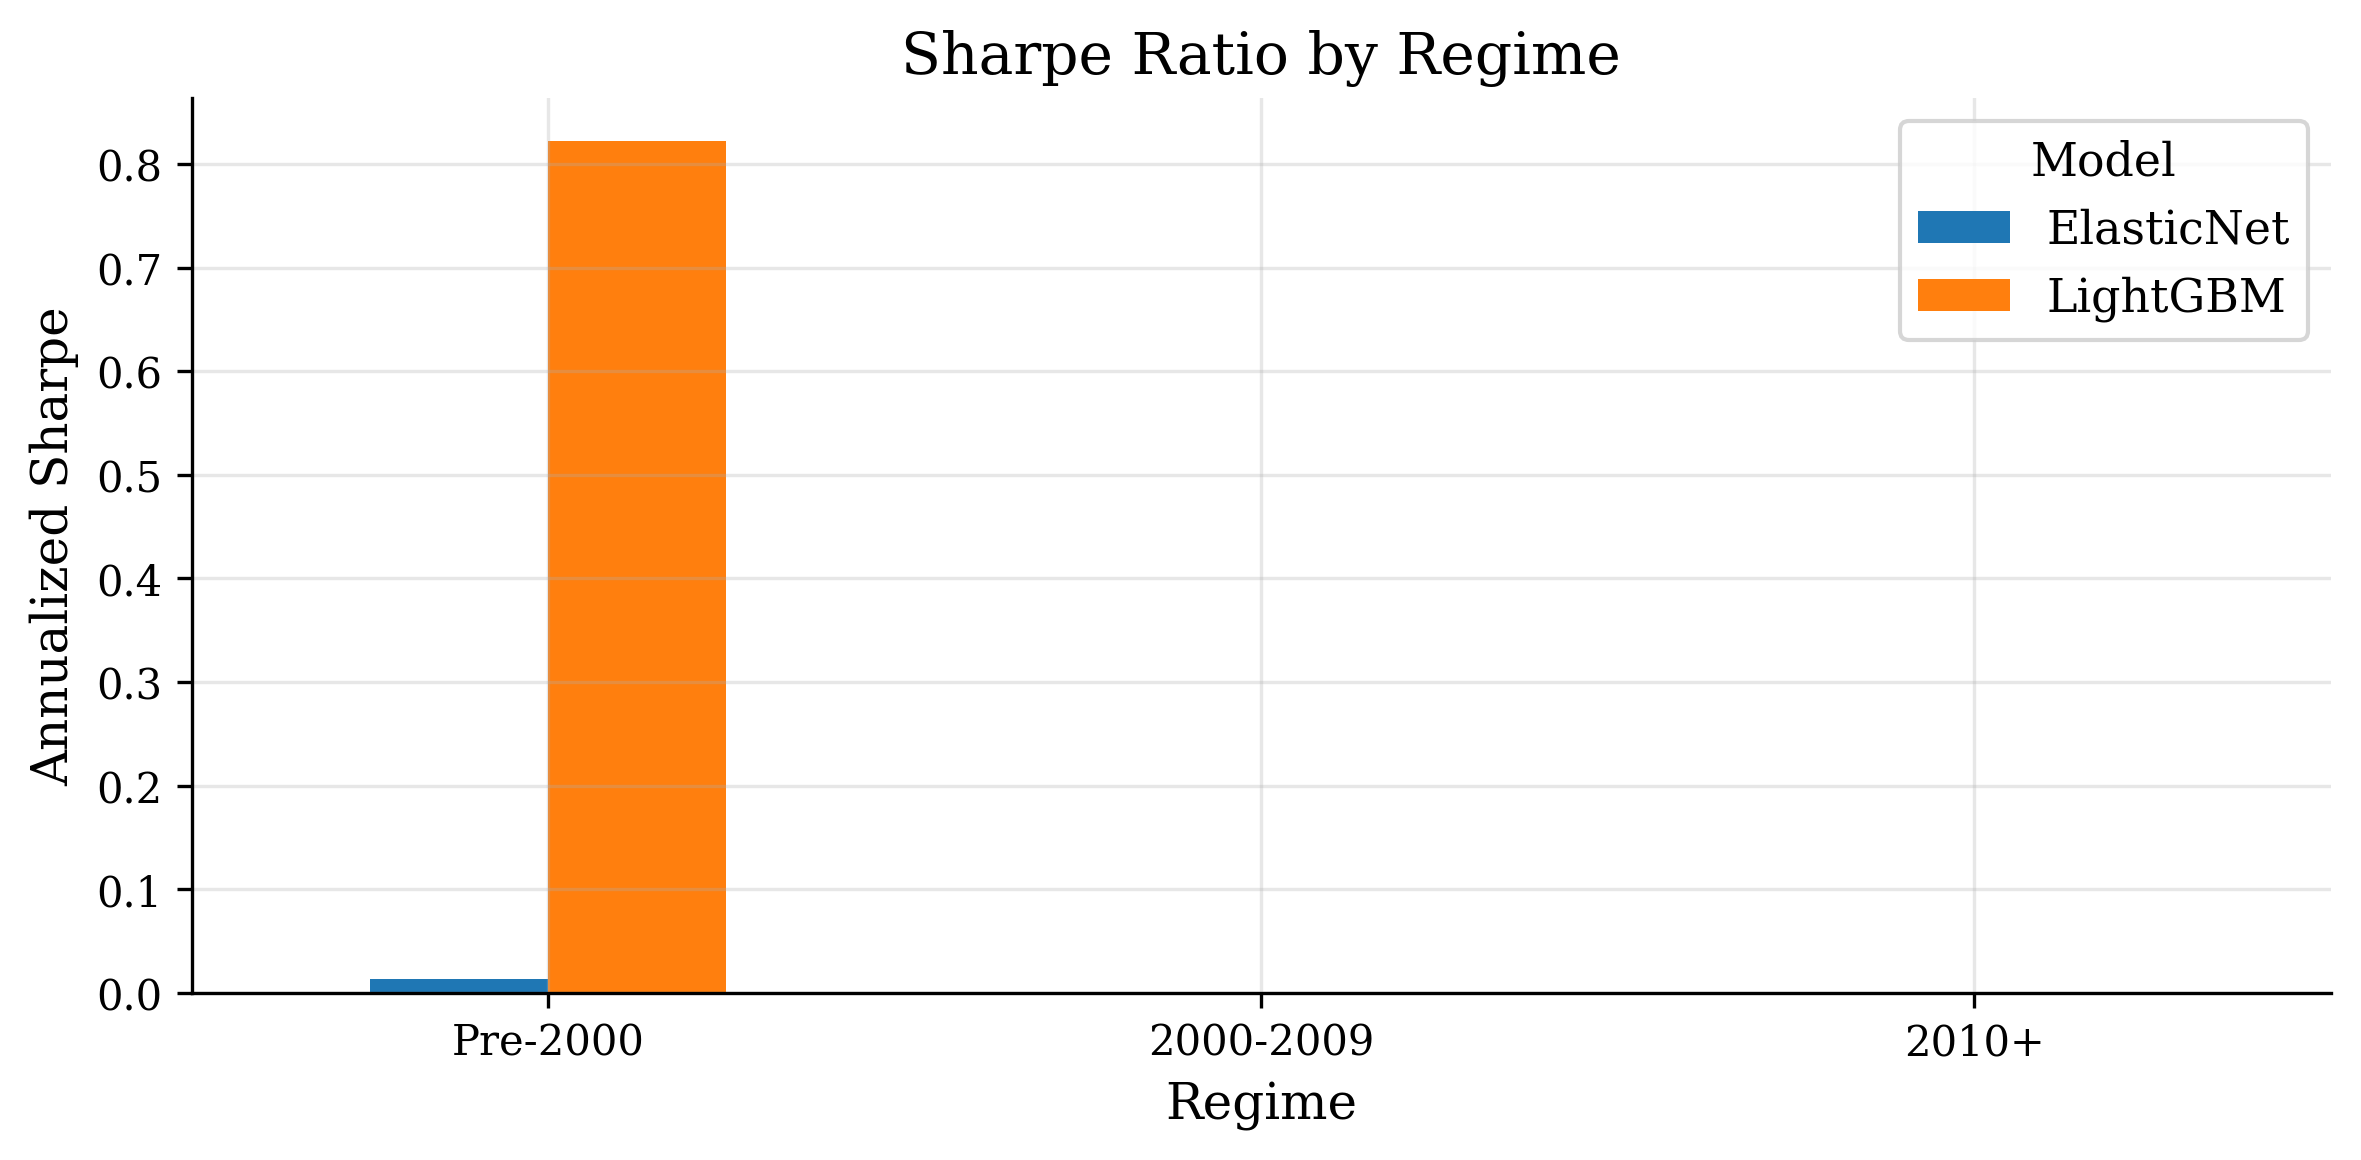

In [ ]:
#@title Regime Stability: Pre-2000 vs Post-2000

if not CONFIG.get("run_regime_analysis", True):
    print("Skipped (run_regime_analysis=False)")
else:
    print("### Regime Stability ###")

    def regime_metrics(ret_series, name):
        res = {}
        for regime, r_min, r_max in [("Pre-2000", None, "2000-01-01"),
                                      ("2000-2009", "2000-01-01", "2010-01-01"),
                                      ("2010+", "2010-01-01", None)]:
            if r_min is None:
                sub = ret_series[ret_series.index < r_max]
            elif r_max is None:
                sub = ret_series[ret_series.index >= r_min]
            else:
                sub = ret_series[(ret_series.index >= r_min) & (ret_series.index < r_max)]

            if len(sub) < 12 or sub.std() == 0:
                res[f"{name}_{regime}"] = {"ann_mean": np.nan, "ann_vol": np.nan,
                                           "sharpe": np.nan, "max_dd": np.nan}
                continue

            ann_mean = sub.mean() * 12
            ann_vol = sub.std() * np.sqrt(12)
            sharpe = (sub.mean() / sub.std()) * np.sqrt(12)
            cum = (1 + sub).cumprod()
            dd = (cum / cum.cummax() - 1).min()
            res[f"{name}_{regime}"] = {"ann_mean": ann_mean, "ann_vol": ann_vol,
                                       "sharpe": sharpe, "max_dd": dd}
        return res

    regimes = {}
    regimes.update(regime_metrics(strategy_returns_enet, "ElasticNet"))
    regimes.update(regime_metrics(strategy_returns_lgbm, "LightGBM"))
    regime_table = pd.DataFrame(regimes).T
    display(regime_table)

    if not regime_table.empty and CONFIG.get("make_plots", True):
        import matplotlib.pyplot as plt
        df_plot = regime_table["sharpe"].reset_index()
        df_plot.columns = ["Model_Regime", "sharpe"]
        df_plot["Model"] = df_plot["Model_Regime"].str.split("_", n=1).str[0]
        df_plot["Regime"] = df_plot["Model_Regime"].str.split("_", n=1).str[1]
        df_plot = df_plot.pivot(index="Model", columns="Regime", values="sharpe")
        for c in ["Pre-2000", "2000-2009", "2010+"]:
            if c not in df_plot.columns:
                df_plot[c] = np.nan
        df_plot = df_plot[["Pre-2000", "2000-2009", "2010+"]].T

        fig, ax = plt.subplots(figsize=(8, 4))
        df_plot.plot(kind="bar", ax=ax)
        ax.set_title("Sharpe Ratio by Regime")
        ax.set_ylabel("Annualized Sharpe")
        ax.set_xticklabels(df_plot.index, rotation=0)
        plt.tight_layout()
        plt.show()



### Model Increment: Sharpe Difference Bootstrap (LightGBM − ElasticNet) ###


,sharpe_diff_obs,ci_low_95,ci_high_95,p_value
0,0.80441,0.502038,1.719617,0.0


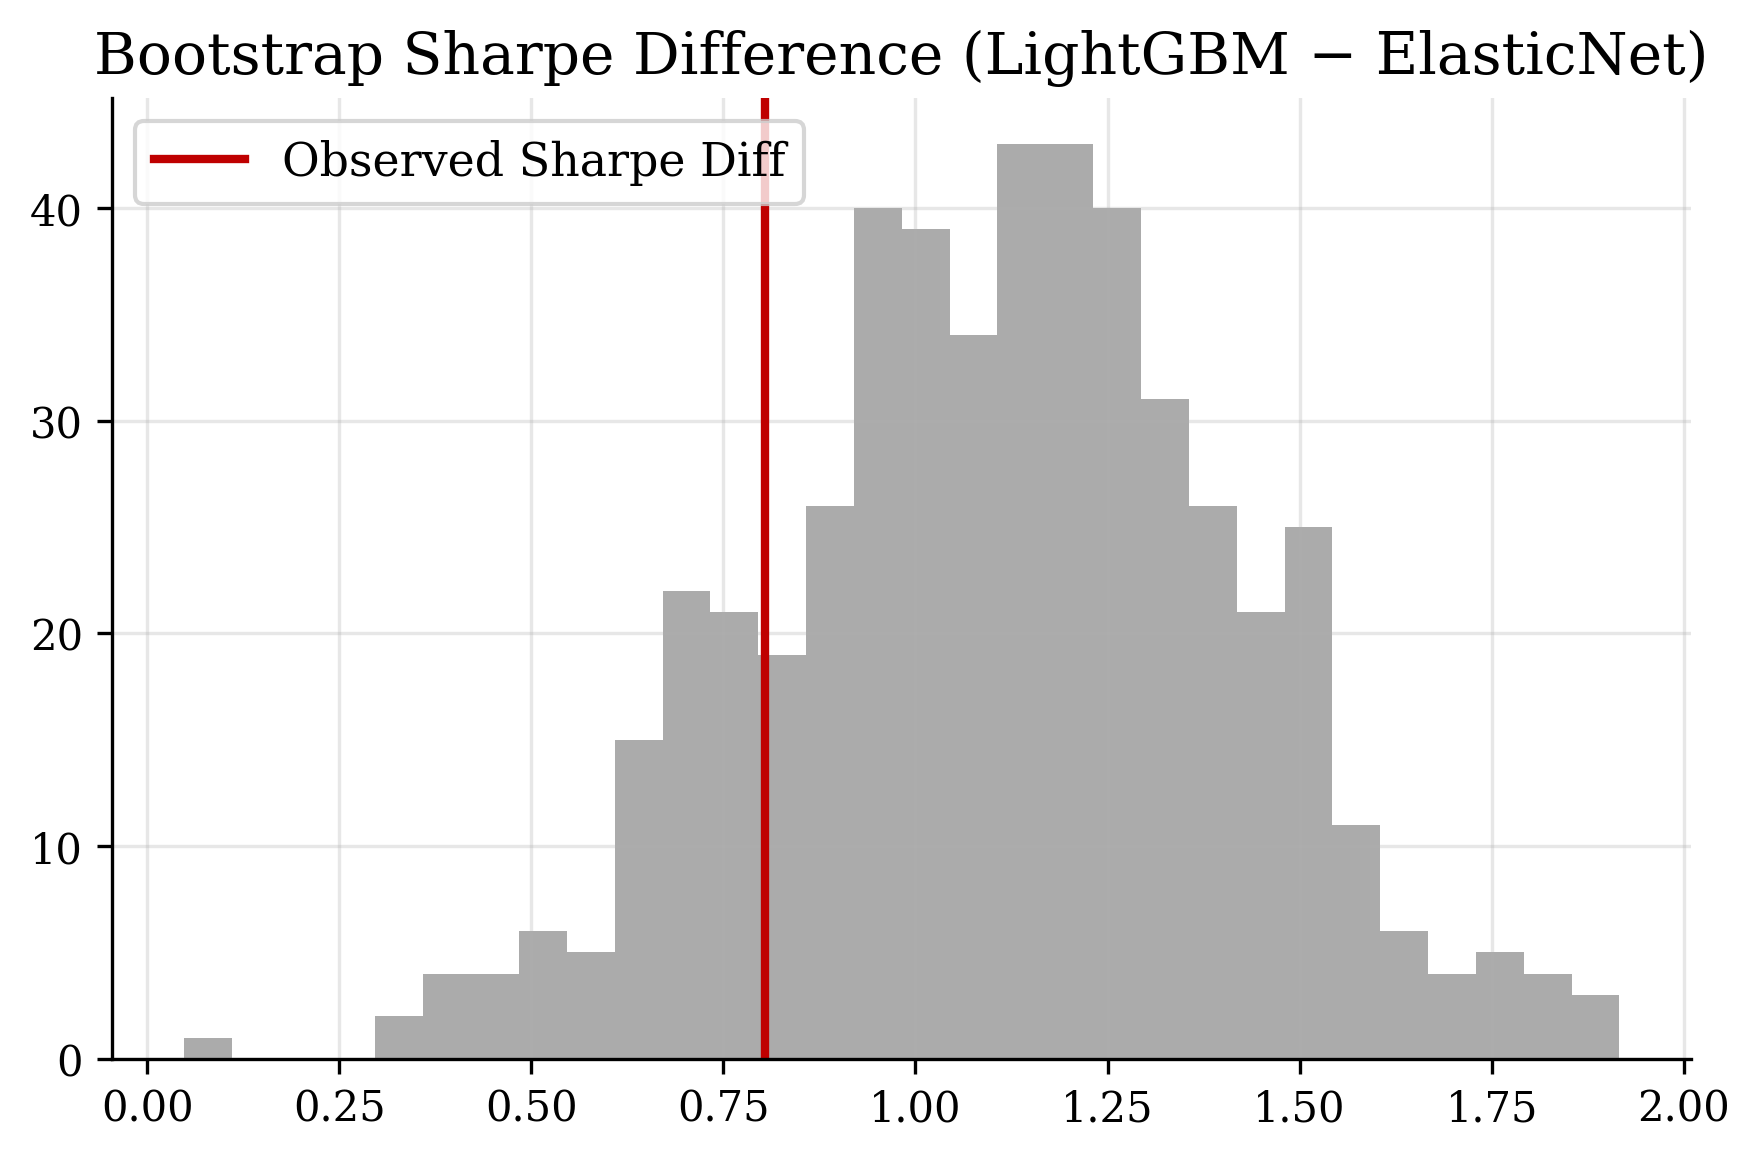

In [ ]:
#@title Model Increment: Sharpe Difference Bootstrap

if not CONFIG.get("run_diagnostics", True):
    print("Skipped (run_diagnostics=False)")
else:
    print("### Model Increment: Sharpe Difference Bootstrap (LightGBM − ElasticNet) ###")
    idx = strategy_returns_lgbm.index.intersection(strategy_returns_enet.index)
    if len(idx) > 0:
        diff_ret = strategy_returns_lgbm.loc[idx] - strategy_returns_enet.loc[idx]
        boot_diff = block_bootstrap_sharpe(diff_ret)

        if len(boot_diff) > 0:
            obs_diff = annualized_sharpe(diff_ret)
            p_val_diff = (boot_diff <= 0).mean()

            sharpe_difference_table = pd.DataFrame([{
                "sharpe_diff_obs": obs_diff,
                "ci_low_95": np.percentile(boot_diff, 2.5),
                "ci_high_95": np.percentile(boot_diff, 97.5),
                "p_value": p_val_diff
            }])
            display(sharpe_difference_table)

            if CONFIG.get("make_plots", True):
                fig, ax = plt.subplots(figsize=(6, 4))
                ax.hist(boot_diff, bins=30, color=COLORS["neutral"], alpha=0.7)
                ax.axvline(obs_diff, color=COLORS["accent"], lw=2, label="Observed Sharpe Diff")
                ax.set_title("Bootstrap Sharpe Difference (LightGBM − ElasticNet)")
                ax.legend()
                plt.tight_layout()
                plt.show()

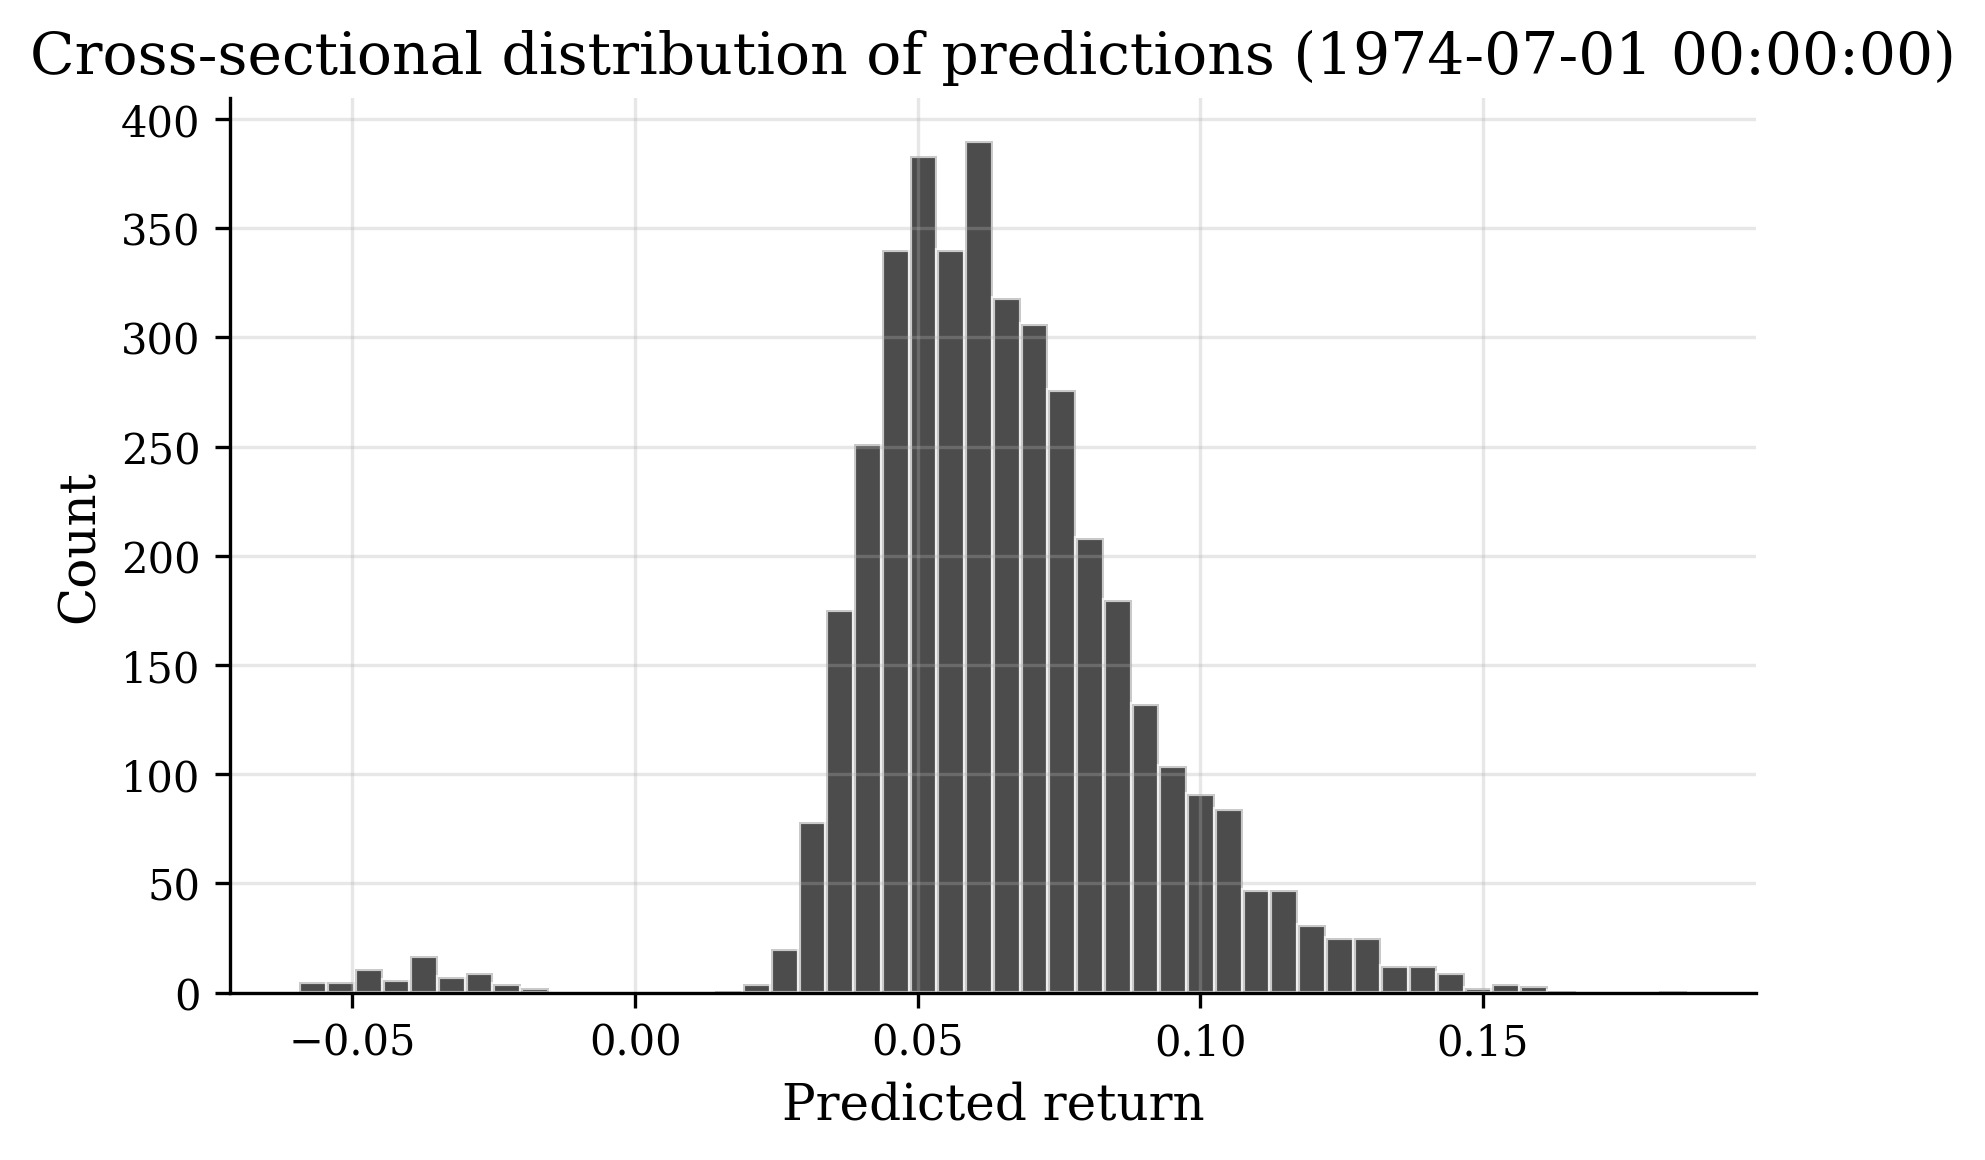

In [ ]:
#@title Cell 19 — Prediction Distribution (long/short avg covered by Cell 45)
if not CONFIG.get("make_plots", True):
    print("Skipped (make_plots=False)")
else:
    pred_col = "prediction" if "prediction" in preds_df.columns else "pred"
    ex_date = preds_df["date"].dropna().iloc[0] if len(preds_df) else None
    if ex_date is not None:
        ex = preds_df[preds_df["date"] == ex_date][pred_col]
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(ex.dropna(), bins=50, color=COLORS["primary"], alpha=0.7, edgecolor="white")
        ax.set_xlabel("Predicted return")
        ax.set_ylabel("Count")
        ax.set_title(f"Cross-sectional distribution of predictions ({ex_date})")
        plt.tight_layout()
        plt.show()

In [ ]:
#@title Cell 20: Compute strategy returns (uses vectorized portfolio from Cell 22)

import time as _time
_t0_strat = _time.perf_counter()

scaled_returns, weight_matrix, scale_t, vol_rolling, strategy_returns_lgbm = compute_strategy_returns(preds_df_lgbm)
scaled_enet, w_enet, _, _, strategy_returns_enet = compute_strategy_returns(preds_df_enet)
strategy_returns = strategy_returns_lgbm

# Cache derived series once
_cum_ret = (1 + scaled_returns).cumprod()
_drawdown = _cum_ret / _cum_ret.cummax() - 1
vol_rolling_scaled = scaled_returns.rolling(CONFIG["vol_window"], min_periods=6).std() * np.sqrt(12)

print(f"Strategy returns computed in {_time.perf_counter() - _t0_strat:.2f}s")

Portfolio: 0 months skipped (k<1), 0 zero-std months
Portfolio: 0 months skipped (k<1), 72 zero-std months
Strategy returns computed in 0.30s


In [ ]:
#@title Cell 22: Performance metrics (uses canonical definitions from Cell 22/Sharpe Bootstrap cell)

metrics_raw = performance_metrics(strategy_returns, weight_matrix)
metrics_scaled = performance_metrics(scaled_returns, weight_matrix)

In [ ]:
#@title Fix 3: Monte Carlo permutation test (Optimized)

import time
import numpy as np
import pandas as pd

def monte_carlo_permutation_test(
    predictions: pd.DataFrame,
    n_sim: int = 1000,
    base_seed: int = 42,
) -> dict:
    """Empirical p-value via fully-vectorized NumPy permutation test."""

    actual_scaled, _, _, _, _ = compute_strategy_returns(predictions)
    actual_sharpe = performance_metrics(actual_scaled).get("Sharpe", np.nan)
    pct = CONFIG.get("long_short_pct", 0.10)
    pred_col = "prediction" if "prediction" in predictions.columns else "pred"

    # ── 1) One-time precompute: pandas used here only, never inside the loop ──
    returns_list = []
    n_list = []
    k_list = []

    for _, grp in predictions.groupby("date"):
        grp = grp.dropna(subset=[pred_col, "ret_excess_lead"])
        n_t = len(grp)
        k_t = int(np.floor(n_t * pct))
        if k_t < 1:
            continue
        returns_list.append(grp["ret_excess_lead"].values.astype(np.float32))
        n_list.append(n_t)
        k_list.append(k_t)

    T = len(returns_list)
    n_arr = np.array(n_list, dtype=np.int32)
    k_arr = np.array(k_list, dtype=np.int32)

    # ── 2) Pre-allocate all buffers once (float32 to reduce memory) ──
    rng = np.random.default_rng(base_seed)
    null_sharpes = np.zeros(n_sim, dtype=np.float32)
    monthly_buf = np.zeros(T, dtype=np.float32)
    sqrt12 = np.float32(np.sqrt(12.0))

    # Cache hot-path callables as locals
    _perm = rng.permutation
    _mean = np.mean

    print(f"Executing {n_sim} Monte Carlo permutations  (T={T} months) ...")
    t0 = time.perf_counter()

    # ── 3) Main loop: pure NumPy, zero pandas / groupby / sorting ──
    for i in range(n_sim):
        if i > 0 and i % 100 == 0:
            print(f"  iter {i:>6d}/{n_sim}  ({time.perf_counter() - t0:.1f}s elapsed)")

        for t in range(T):
            r_t = returns_list[t]
            k_t = k_arr[t]
            perm = _perm(n_arr[t])
            monthly_buf[t] = _mean(r_t[perm[-k_t:]]) - _mean(r_t[perm[:k_t]])

        mu = np.mean(monthly_buf)
        sd = np.std(monthly_buf, ddof=1)
        null_sharpes[i] = (mu / sd * sqrt12) if sd > 0.0 else np.float32(np.nan)

    runtime = time.perf_counter() - t0
    print(f"Monte Carlo loop finished.  Runtime: {runtime:.2f}s")

    # ── 4) Statistics ──
    valid = null_sharpes[~np.isnan(null_sharpes)]
    N = len(valid)
    count_ge = int((valid >= actual_sharpe).sum())

    p_value     = (count_ge + 1) / (N + 1) if N > 0 else np.nan
    p_positive  = float(np.mean(valid > 0)) if N > 0 else np.nan
    p_above_one = float(np.mean(valid > 1)) if N > 0 else np.nan

    return {
        "actual_sharpe": actual_sharpe,
        "null_sharpes":  valid,
        "p_value":       p_value,
        "P(Sharpe>0)":   p_positive,
        "P(Sharpe>1)":   p_above_one,
        "runtime":       runtime,
    }

if CONFIG.get("run_monte_carlo", False):
    n_sim = CONFIG.get("monte_carlo_sims", 200)
    mc_result = monte_carlo_permutation_test(preds_df, n_sim=n_sim)
    print("Actual Sharpe:", mc_result["actual_sharpe"])
    print("p-value:", mc_result["p_value"])
else:
    mc_result = None
    print("Monte Carlo skipped.")


Portfolio: 0 months skipped (k<1), 0 zero-std months
Executing 1000 Monte Carlo permutations  (T=84 months) ...
  iter    100/1000  (0.9s elapsed)
  iter    200/1000  (2.0s elapsed)
  iter    300/1000  (3.5s elapsed)
  iter    400/1000  (5.0s elapsed)
  iter    500/1000  (6.4s elapsed)
  iter    600/1000  (7.3s elapsed)
  iter    700/1000  (8.3s elapsed)
  iter    800/1000  (9.2s elapsed)
  iter    900/1000  (10.2s elapsed)
Monte Carlo loop finished.  Runtime: 11.10s
Actual Sharpe: 0.6936030665450768
p-value: 0.03196803196803197


In [ ]:
#@title LOGIC AUDIT (sanity checks)

if not CONFIG.get("run_diagnostics", True):
    print("Skipped (run_diagnostics=False)")
else:
    import inspect

    _vol_src = inspect.getsource(apply_vol_targeting)
    assert "shift(1)" in _vol_src, "apply_vol_targeting must use shift(1) on rolling vol"
    print("1) Vol targeting: shift(1) on rolling vol confirmed.")

    _preds = preds_df.dropna(subset=["date", "permno", "prediction", "ret_excess_lead"])
    _dates = _preds["date"].unique()
    _audit_date = np.random.choice(_dates) if len(_dates) else None
    if _audit_date is not None:
        _sample = _preds[_preds["date"] == _audit_date][["date", "permno", "prediction", "ret_excess_lead"]].head(5)
        print("2) Prediction alignment (sample month, 5 rows):")
        print(_sample.to_string())
        print(f"   len(preds_df) = {len(preds_df)} (row count OK)")

    if _audit_date is not None:
        _grp = _preds[_preds["date"] == _audit_date]
        _pct = CONFIG["long_short_pct"]
        _k = int(np.floor(len(_grp) * _pct))
        _w = weight_matrix[weight_matrix["date"] == _audit_date]
        _n_long = (_w["weight"] > 0).sum()
        _n_short = (_w["weight"] < 0).sum()
        assert _n_long == _k and _n_short == _k, f"long={_n_long}, short={_n_short}, k={_k}"
        print(f"3) Long/short sizes: k={_k}, long={_n_long}, short={_n_short} (OK)")

    _mc = monte_carlo_permutation_test(preds_df, n_sim=50)
    print(f"4) Monte Carlo (n_sim=50): p_value={_mc['p_value']:.4f}, actual_sharpe={_mc['actual_sharpe']:.4f}, null_mean={_mc['null_sharpes'].mean():.4f}")
    print("LOGIC AUDIT done.")

1) Vol targeting: shift(1) on rolling vol confirmed.
2) Prediction alignment (sample month, 5 rows):
            date  permno  prediction  ret_excess_lead
58498 1975-10-01   10006   -0.021483         0.019320
58499 1975-10-01   10014   -0.022490         0.129233
58500 1975-10-01   10057   -0.004995         0.110654
58501 1975-10-01   10102   -0.023007        -0.017894
58502 1975-10-01   10137   -0.011485         0.105719
   len(preds_df) = 408517 (row count OK)
3) Long/short sizes: k=391, long=391, short=391 (OK)
Portfolio: 0 months skipped (k<1), 0 zero-std months
Executing 50 Monte Carlo permutations  (T=84 months) ...
Monte Carlo loop finished.  Runtime: 0.46s
4) Monte Carlo (n_sim=50): p_value=0.0980, actual_sharpe=0.6936, null_mean=0.0702
LOGIC AUDIT done.


In [ ]:
#@title Cell 25: Monte Carlo Summary Table
if "mc_result" not in dir() or mc_result is None:
    print("Skipped (no mc_result — Monte Carlo was not run)")
else:
    mc_summary = pd.DataFrame([
        {"Metric": "Actual Sharpe", "Value": round(mc_result["actual_sharpe"], 4)},
        {"Metric": "p-value (permutation)", "Value": round(mc_result["p_value"], 4)},
        {"Metric": "P(null Sharpe > 0)", "Value": round(mc_result["P(Sharpe>0)"], 4)},
        {"Metric": "P(null Sharpe > 1)", "Value": round(mc_result["P(Sharpe>1)"], 4)},
    ])
    display(mc_summary)

,Metric,Value
0,Actual Sharpe,0.6936
1,p-value (permutation),0.0320
2,P(null Sharpe > 0),0.5230
3,P(null Sharpe > 1),0.0050


In [ ]:
#@title Cell 28: Robustness comparison plot
if not CONFIG.get("run_diagnostics", True) or not CONFIG.get("make_plots", True):
    print("Skipped")
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot((1 + r_baseline_vt.dropna()).cumprod().index, (1 + r_baseline_vt.dropna()).cumprod().values, label="10%", color=COLORS["primary"])
    ax.plot((1 + r_5_vt.dropna()).cumprod().index, (1 + r_5_vt.dropna()).cumprod().values, label="5%", color=COLORS["secondary"])
    ax.set_ylabel("Cumulative return")
    ax.set_xlabel("Date")
    ax.set_title("Robustness: 5% vs 10% long/short")
    ax.legend()
    plt.tight_layout()
    save_plot(fig, "robustness_comparison.png")
    plt.show()

In [ ]:
#@title Cell 29: Final Summary Table
_mc_p = mc_result["p_value"] if ("mc_result" in dir() and mc_result is not None) else np.nan
summary = pd.DataFrame([
    {
        "Strategy": "Raw Model (10%)",
        "Ann Return": metrics_raw["Ann Return"],
        "Ann Vol": metrics_raw["Ann Vol"],
        "Sharpe Ratio": metrics_raw["Sharpe"],
        "Sortino Ratio": metrics_raw["Sortino"],
        "Skewness": metrics_raw["Skewness"],
        "Kurtosis": metrics_raw["Kurtosis"],
        "Max Drawdown": metrics_raw["Max DD"],
        "Ann Turnover": metrics_raw["Turnover"],
        "Empirical p-value": _mc_p
    },
    {
        "Strategy": "Vol-Targeted Proxy (10%)",
        "Ann Return": metrics_scaled["Ann Return"],
        "Ann Vol": metrics_scaled["Ann Vol"],
        "Sharpe Ratio": metrics_scaled["Sharpe"],
        "Sortino Ratio": metrics_scaled["Sortino"],
        "Skewness": metrics_scaled["Skewness"],
        "Kurtosis": metrics_scaled["Kurtosis"],
        "Max Drawdown": metrics_scaled["Max DD"],
        "Ann Turnover": metrics_scaled["Turnover"],
        "Empirical p-value": _mc_p
    },
])
summary.round(4).to_csv("summary_table.csv", index=False)
display(summary.round(4))

,Strategy,Ann Return,Ann Vol,Sharpe Ratio,Sortino Ratio,Skewness,Kurtosis,Max Drawdown,Ann Turnover,Empirical p-value
0,Raw Model (10%),0.1228,0.1547,0.8228,2.1608,2.9311,15.3497,-0.1873,11.0889,0.032
1,Vol-Targeted Proxy (10%),0.0970,0.1483,0.6936,1.6368,3.4522,19.3868,-0.1873,11.0889,0.032


In [ ]:
#@title Advanced Academic Robustness

import statsmodels.api as sm

def run_advanced_robustness(baseline_ret, lgbm_ret=None):
    res = {}
    r = baseline_ret.dropna()

    if len(r) > 0:
        pre_2000 = r[r.index < "2000-01-01"]
        post_2000 = r[r.index >= "2000-01-01"]
        res["Sharpe (Pre-2000)"] = performance_metrics(pre_2000).get("Sharpe", np.nan)
        res["Sharpe (Post-2000)"] = performance_metrics(post_2000).get("Sharpe", np.nan)

    boot = block_bootstrap_sharpe(r)
    if len(boot) > 0:
        res["Sharpe 95% CI Lower"] = np.percentile(boot, 2.5)
        res["Sharpe 95% CI Upper"] = np.percentile(boot, 97.5)

    if len(r) > 0:
        X = sm.add_constant(np.ones(len(r)))
        model = sm.OLS(r.values, X).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
        res["Strategy Alpha"] = model.params[0]
        res["Alpha t-stat"] = model.tvalues[0]

    if lgbm_ret is not None and len(lgbm_ret) > 0:
        idx = r.index.intersection(lgbm_ret.index)
        r_diff = lgbm_ret.loc[idx] - r.loc[idx]
        boot_diff = block_bootstrap_sharpe(r_diff)
        if len(boot_diff) > 0:
            res["Sharpe Diff (LGBM - ENet)"] = annualized_sharpe(r_diff)
            res["Sharpe Diff p-value"] = (boot_diff <= 0).mean()

    return res

if CONFIG.get("run_diagnostics", True):
    adv_results = run_advanced_robustness(scaled_returns)
    adv_df = pd.DataFrame([adv_results]).T.rename(columns={0: "Value"})
    display(adv_df.round(4))
else:
    print("Skipped (run_diagnostics=False)")

,Value
Sharpe (Pre-2000),0.6936
Sharpe (Post-2000),NaN
Sharpe 95% CI Lower,0.4644
Sharpe 95% CI Upper,1.6575
Strategy Alpha,0.0086
Alpha t-stat,1.8329


### Risk & Tail Events ###


,Model,Max Drawdown,Longest DD (months),Worst 1m,Worst 3m
0,ElasticNet,-0.203048,82,-0.137220,-0.172769
1,LightGBM,-0.187316,25,-0.070913,-0.159686


| Model      |   Max Drawdown |   Longest DD (months) |   Worst 1m |   Worst 3m |
|:-----------|---------------:|----------------------:|-----------:|-----------:|
| ElasticNet |      -0.203048 |                    82 | -0.13722   |  -0.172769 |
| LightGBM   |      -0.187316 |                    25 | -0.0709127 |  -0.159686 |


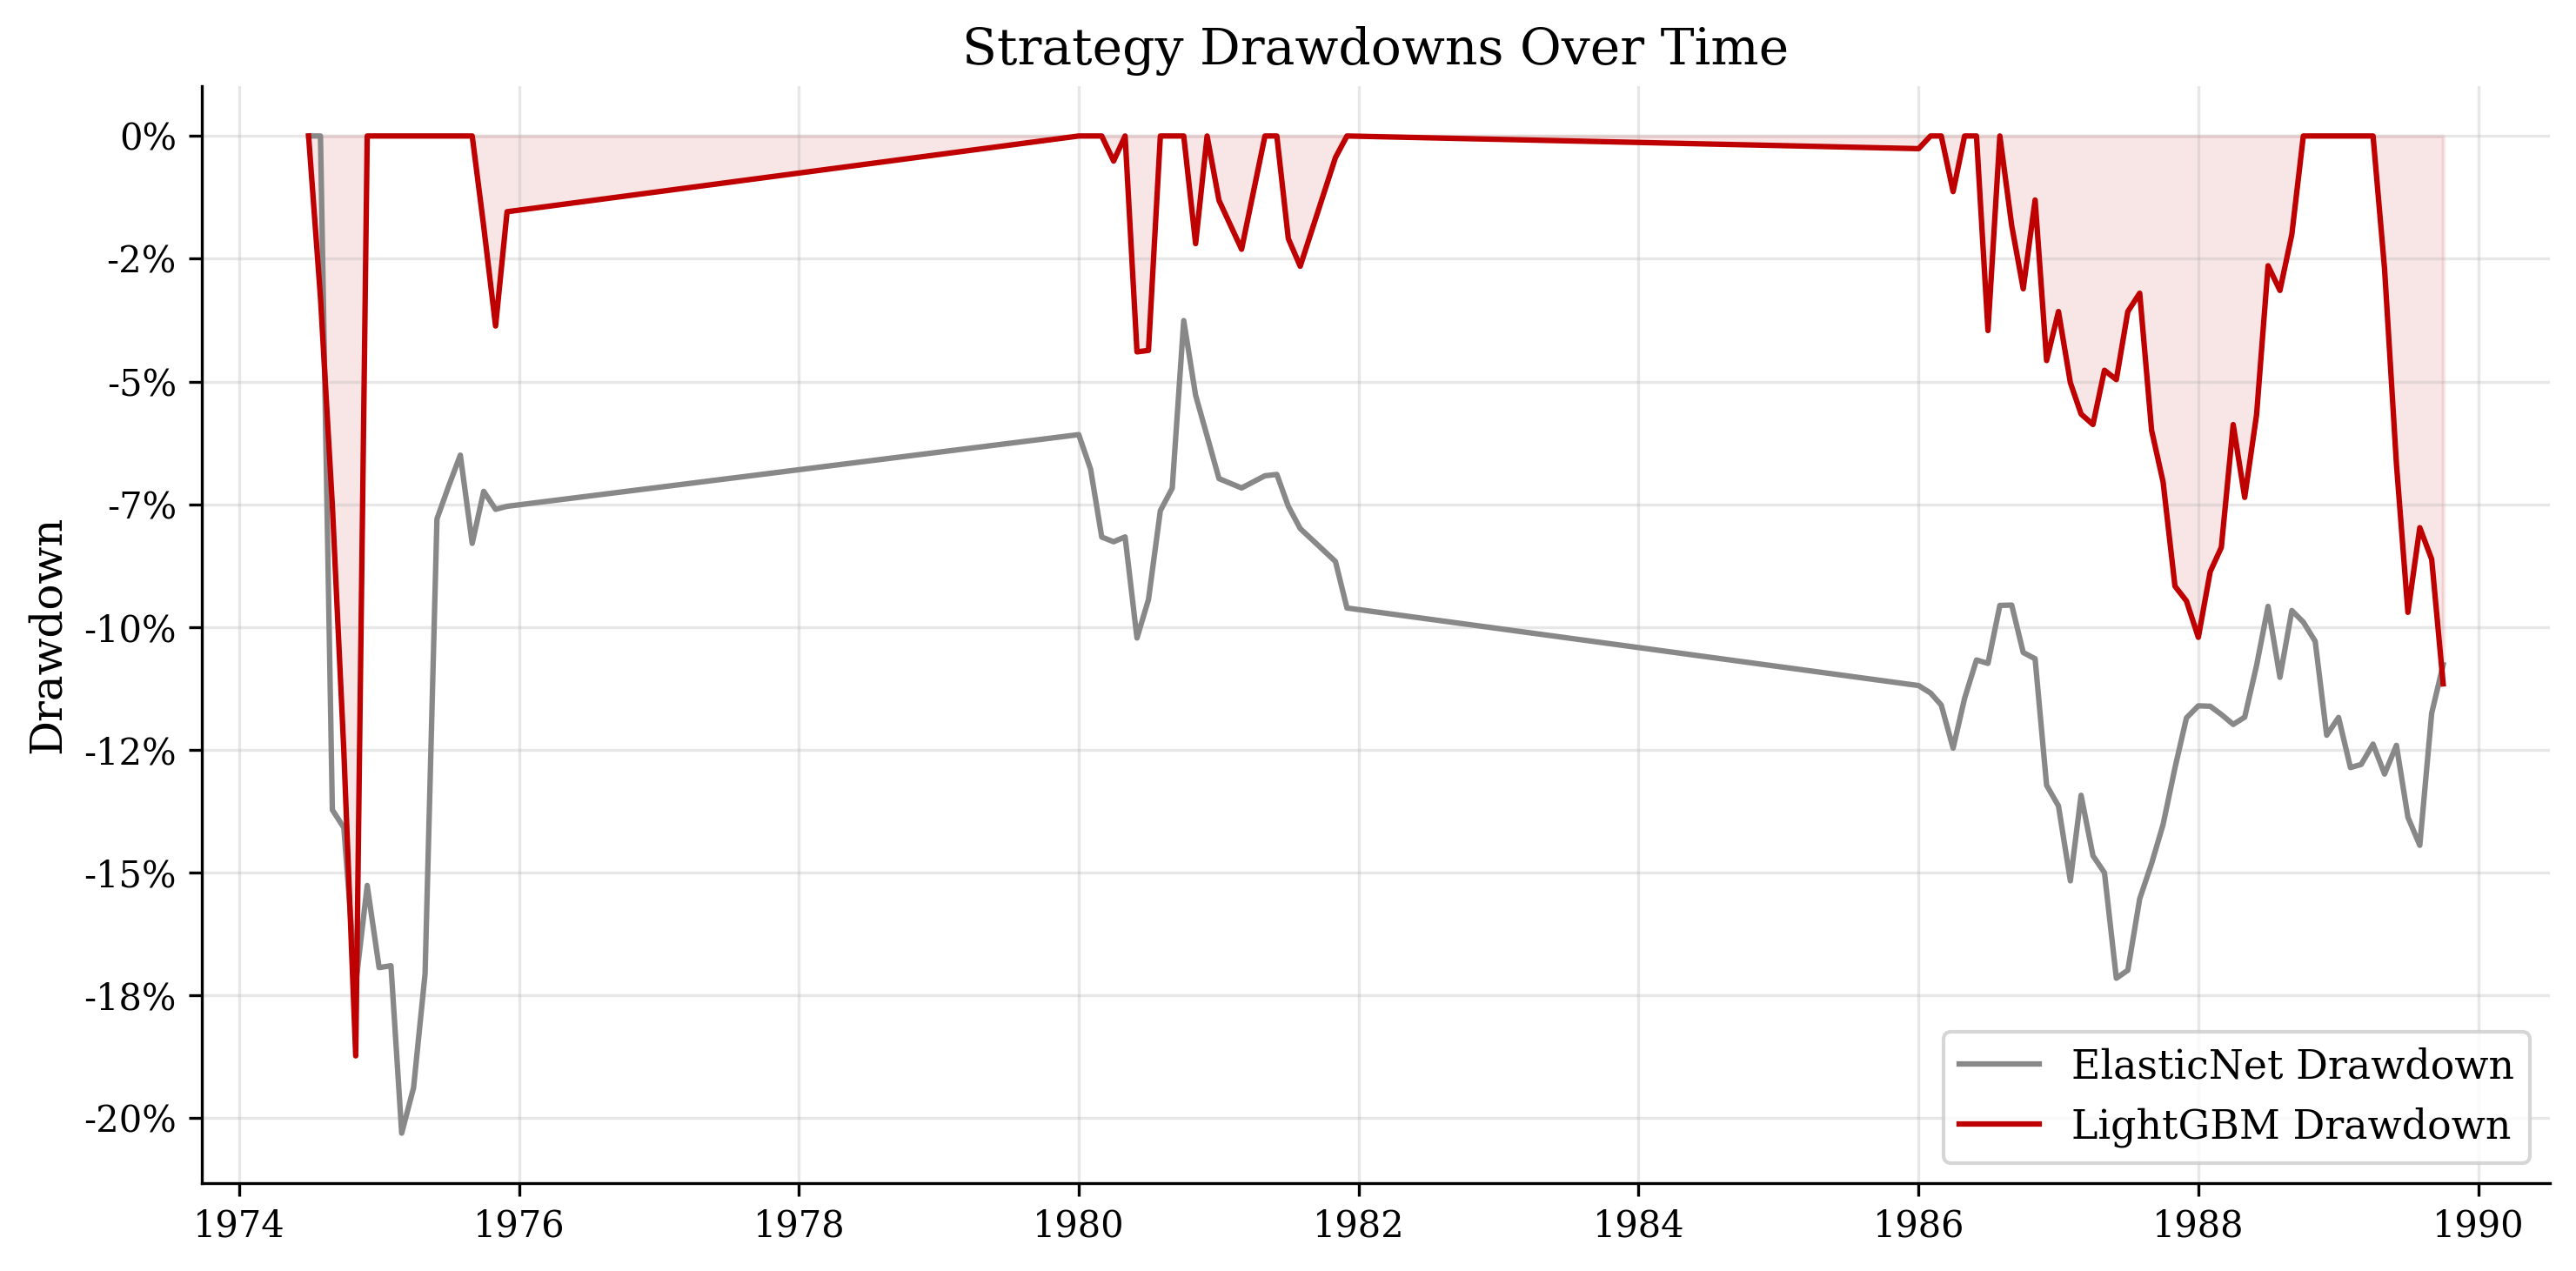

In [ ]:
#@title Cell 99: Risk & Tail Events
print("### Risk & Tail Events ###")

def compute_tail_risk(ret: pd.Series, name: str):
    cum_ret = (1 + ret).cumprod()
    peak = cum_ret.cummax()
    drawdown = (cum_ret - peak) / peak
    max_dd = drawdown.min()

    # longest drawdown duration
    dd_duration = (drawdown < 0).astype(int)
    # block duration calculation
    longest_dd_duration = dd_duration.groupby((dd_duration == 0).cumsum()).sum().max()

    worst_1m = ret.min()
    log_ret = np.log1p(ret)
    worst_3m = np.expm1(log_ret.rolling(3).sum()).min()

    res = {
        "Model": name,
        "Max Drawdown": max_dd,
        "Longest DD (months)": longest_dd_duration,
        "Worst 1m": worst_1m,
        "Worst 3m": worst_3m
    }

    crisis_periods = [
        ("Dot-com", "2000-03-01", "2002-10-31"),
        ("GFC",     "2007-10-01", "2009-06-30"),
        ("COVID",   "2020-02-01", "2020-05-31"),
    ]
    for label, c_start, c_end in crisis_periods:
        crisis = ret[(ret.index >= c_start) & (ret.index <= c_end)]
        if len(crisis) > 0:
            res[f"Crisis {label} CumRet"] = (1 + crisis).prod() - 1
            res[f"Crisis {label} Sharpe"] = annualized_sharpe(crisis)

    return drawdown, res

dd_enet, risk_enet = compute_tail_risk(strategy_returns_enet, "ElasticNet")
dd_lgbm, risk_lgbm = compute_tail_risk(strategy_returns_lgbm, "LightGBM")

risk_table = pd.DataFrame([risk_enet, risk_lgbm])
display(risk_table)
print(risk_table.to_markdown(index=False))

if CONFIG.get("make_plots", True):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(dd_enet.index, dd_enet.values, label="ElasticNet Drawdown", color=COLORS["neutral"], lw=1.5)
    ax.plot(dd_lgbm.index, dd_lgbm.values, label="LightGBM Drawdown", color=COLORS["accent"], lw=1.5)
    ax.fill_between(dd_lgbm.index, dd_lgbm.values, 0, color=COLORS["accent"], alpha=0.1)
    ax.set_title("Strategy Drawdowns Over Time")
    ax.set_ylabel("Drawdown")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    ax.legend()
    plt.tight_layout()
    plt.show()
    save_plot(fig, "drawdown_comparison.png")

In [ ]:
#@title Tear Sheet
print("### Performance Tear Sheet ###")

def generate_tear_sheet(strategy_returns: pd.Series, periods_per_year: int = 12) -> pd.DataFrame:
    if strategy_returns.empty: return pd.DataFrame()
    # 1. Annualized Return
    total_compounded_return = (1 + strategy_returns).prod()
    n_periods = len(strategy_returns)
    years = n_periods / periods_per_year
    ann_return = total_compounded_return ** (1 / years) - 1

    # 2. Annualized Volatility
    ann_volatility = strategy_returns.std() * np.sqrt(periods_per_year)

    # 3. Sharpe Ratio
    sharpe_ratio = annualized_sharpe(strategy_returns)

    # 4. Information Ratio (equivalent to Sharpe here)
    info_ratio = sharpe_ratio

    # 5. Maximum Drawdown
    cumulative_returns = (1 + strategy_returns).cumprod()
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    max_drawdown = drawdown.min()

    tear_sheet = pd.DataFrame({
        'Metric': ['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio (Rf=0)', 'Information Ratio', 'Max Drawdown'],
        'Value': [f"{ann_return:.2%}", f"{ann_volatility:.2%}", f"{sharpe_ratio:.4f}", f"{info_ratio:.4f}", f"{max_drawdown:.2%}"]
    }).set_index('Metric')

    return tear_sheet

tear_enet = generate_tear_sheet(strategy_returns_enet)
tear_lgbm = generate_tear_sheet(strategy_returns_lgbm)

print("ElasticNet Tear Sheet:")
display(tear_enet)
print(tear_enet.to_markdown())

print("\nLightGBM Tear Sheet:")
display(tear_lgbm)
print(tear_lgbm.to_markdown())

### Performance Tear Sheet ###
ElasticNet Tear Sheet:


,Value
Metric,
Annualized Return,-0.27%
Annualized Volatility,8.72%
Sharpe Ratio (Rf=0),0.0134
Information Ratio,0.0134
Max Drawdown,-20.30%


| Metric                | Value   |
|:----------------------|:--------|
| Annualized Return     | -0.27%  |
| Annualized Volatility | 8.72%   |
| Sharpe Ratio (Rf=0)   | 0.0134  |
| Information Ratio     | 0.0134  |
| Max Drawdown          | -20.30% |

LightGBM Tear Sheet:


,Value
Metric,
Annualized Return,12.28%
Annualized Volatility,15.47%
Sharpe Ratio (Rf=0),0.8228
Information Ratio,0.8228
Max Drawdown,-18.73%


| Metric                | Value   |
|:----------------------|:--------|
| Annualized Return     | 12.28%  |
| Annualized Volatility | 15.47%  |
| Sharpe Ratio (Rf=0)   | 0.8228  |
| Information Ratio     | 0.8228  |
| Max Drawdown          | -18.73% |


Portfolio: 0 months skipped (k<1), 0 zero-std months
Portfolio: 0 months skipped (k<1), 72 zero-std months


,LightGBM,ElasticNet
Annualized Return,0.122796,-0.002652
Volatility,0.154661,0.087167
Sharpe Ratio,0.822771,0.013377
Maximum Drawdown,-0.187316,-0.203048


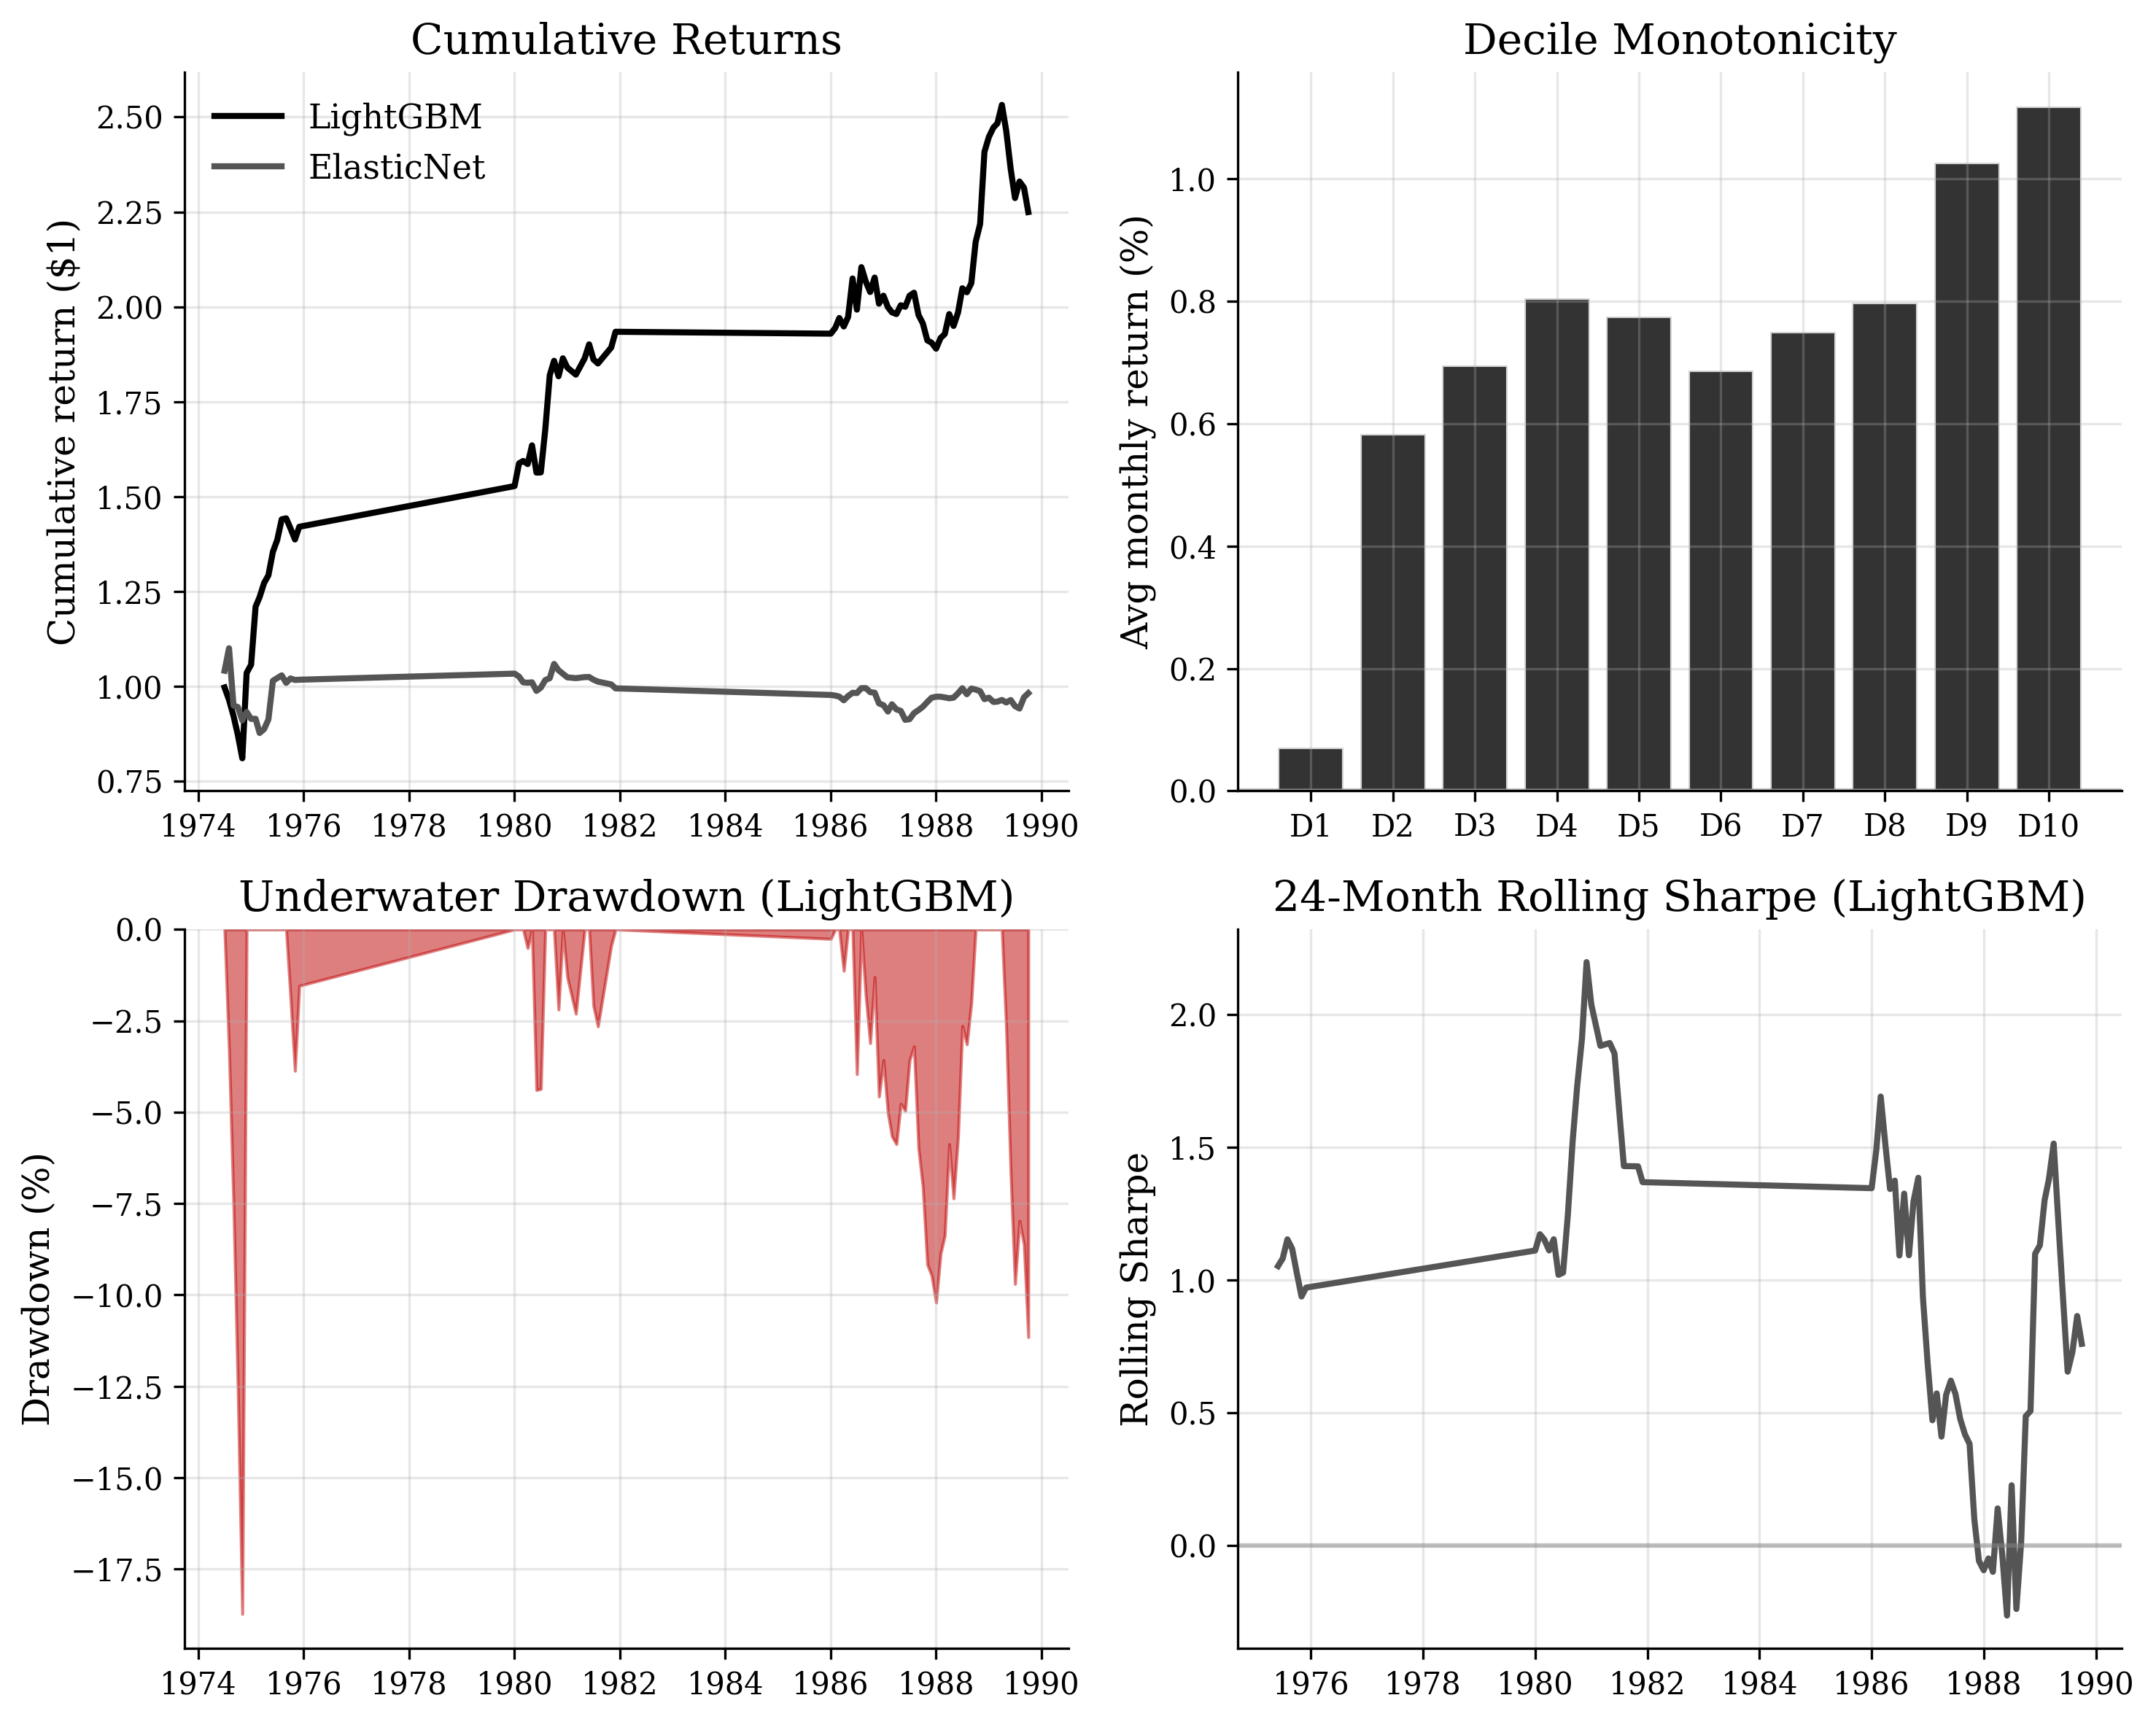

In [ ]:
#@title Money Slides — Performance Table + 2×2 Visual Grid
if not CONFIG.get("make_plots", True):
    print("Skipped (make_plots=False)")
else:
    pct = CONFIG["long_short_pct"]
    ret_lgbm_raw, w_lgbm = construct_long_short_portfolio(preds_df, pct=pct)
    ret_enet_raw, w_enet = construct_long_short_portfolio(preds_df_enet, pct=pct)
    ret_lgbm = ret_lgbm_raw.dropna()
    ret_enet = ret_enet_raw.dropna()

    m_lgbm = performance_metrics(ret_lgbm, w_lgbm)
    m_enet = performance_metrics(ret_enet, w_enet)
    perf_table = pd.DataFrame({
        "LightGBM": [m_lgbm.get("Ann Return", np.nan), m_lgbm.get("Ann Vol", np.nan),
                      m_lgbm.get("Sharpe", np.nan), m_lgbm.get("Max DD", np.nan)],
        "ElasticNet": [m_enet.get("Ann Return", np.nan), m_enet.get("Ann Vol", np.nan),
                       m_enet.get("Sharpe", np.nan), m_enet.get("Max DD", np.nan)],
    }, index=["Annualized Return", "Volatility", "Sharpe Ratio", "Maximum Drawdown"])
    display(perf_table)

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    cum_lgbm = (1 + ret_lgbm).cumprod()
    cum_enet = (1 + ret_enet).cumprod()
    axes[0, 0].plot(cum_lgbm.index, cum_lgbm.values, label="LightGBM", color=COLORS["primary"], lw=2)
    axes[0, 0].plot(cum_enet.index, cum_enet.values, label="ElasticNet", color=COLORS["secondary"], lw=2)
    axes[0, 0].set_ylabel("Cumulative return ($1)")
    axes[0, 0].set_title("Cumulative Returns")
    axes[0, 0].legend(frameon=False)

    pred_col = "prediction" if "prediction" in preds_df.columns else "pred"
    df_dec = preds_df[["date", "permno", pred_col, "ret_excess_lead"]].dropna()
    df_dec["decile"] = df_dec.groupby("date")[pred_col].transform(
        lambda x: pd.qcut(x.rank(method="first"), 10, labels=np.arange(1, 11))
    )
    decile_ret = df_dec.groupby(["date", "decile"])["ret_excess_lead"].mean().reset_index()
    decile_avg = decile_ret.groupby("decile")["ret_excess_lead"].mean()
    x_pos = np.arange(len(decile_avg))
    axes[0, 1].bar(x_pos, decile_avg.values * 100, color=COLORS["primary"], alpha=0.8, edgecolor="white")
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels([f"D{d}" for d in decile_avg.index])
    axes[0, 1].set_ylabel("Avg monthly return (%)")
    axes[0, 1].set_title("Decile Monotonicity")
    axes[0, 1].axhline(0, color=COLORS["neutral"], linestyle="-", alpha=0.5)

    cum = (1 + ret_lgbm).cumprod()
    dd = (cum / cum.cummax() - 1) * 100
    dd.index = pd.to_datetime(dd.index)
    axes[1, 0].fill_between(dd.index, dd.values, 0, color=COLORS["accent"], alpha=0.5)
    axes[1, 0].set_ylabel("Drawdown (%)")
    axes[1, 0].set_title("Underwater Drawdown (LightGBM)")
    axes[1, 0].set_ylim(dd.min() * 1.05, 0)

    roll_24 = ret_lgbm.rolling(24, min_periods=12)
    roll_sharpe_24 = (roll_24.mean() / roll_24.std().replace(0, np.nan)) * np.sqrt(12)
    axes[1, 1].plot(roll_sharpe_24.index, roll_sharpe_24.values, color=COLORS["secondary"], lw=2)
    axes[1, 1].axhline(0, color=COLORS["neutral"], linestyle="-", alpha=0.5)
    axes[1, 1].set_ylabel("Rolling Sharpe")
    axes[1, 1].set_title("24-Month Rolling Sharpe (LightGBM)")
    for ax in axes.flat:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


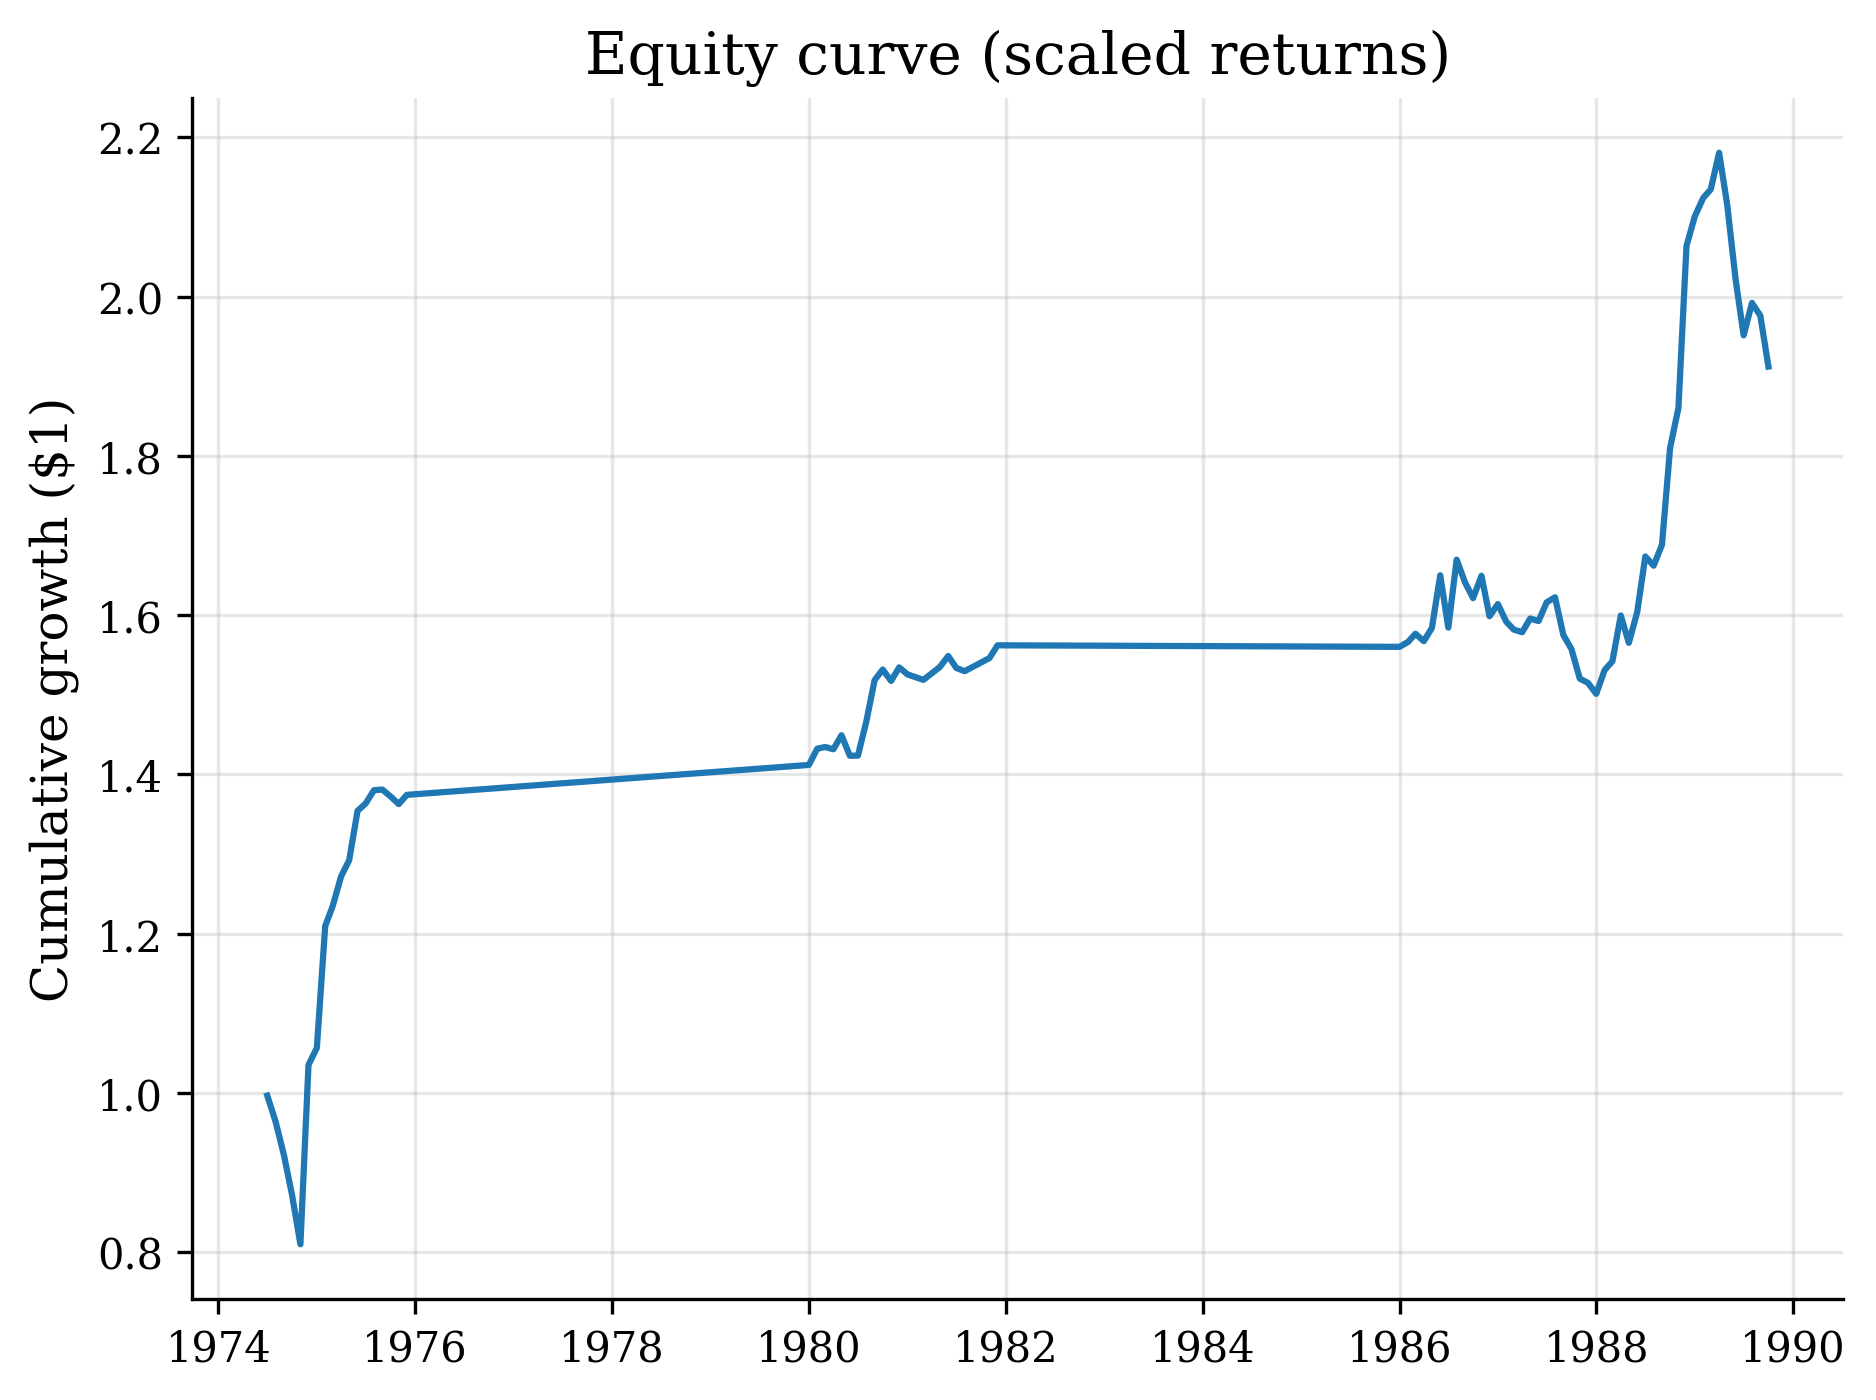

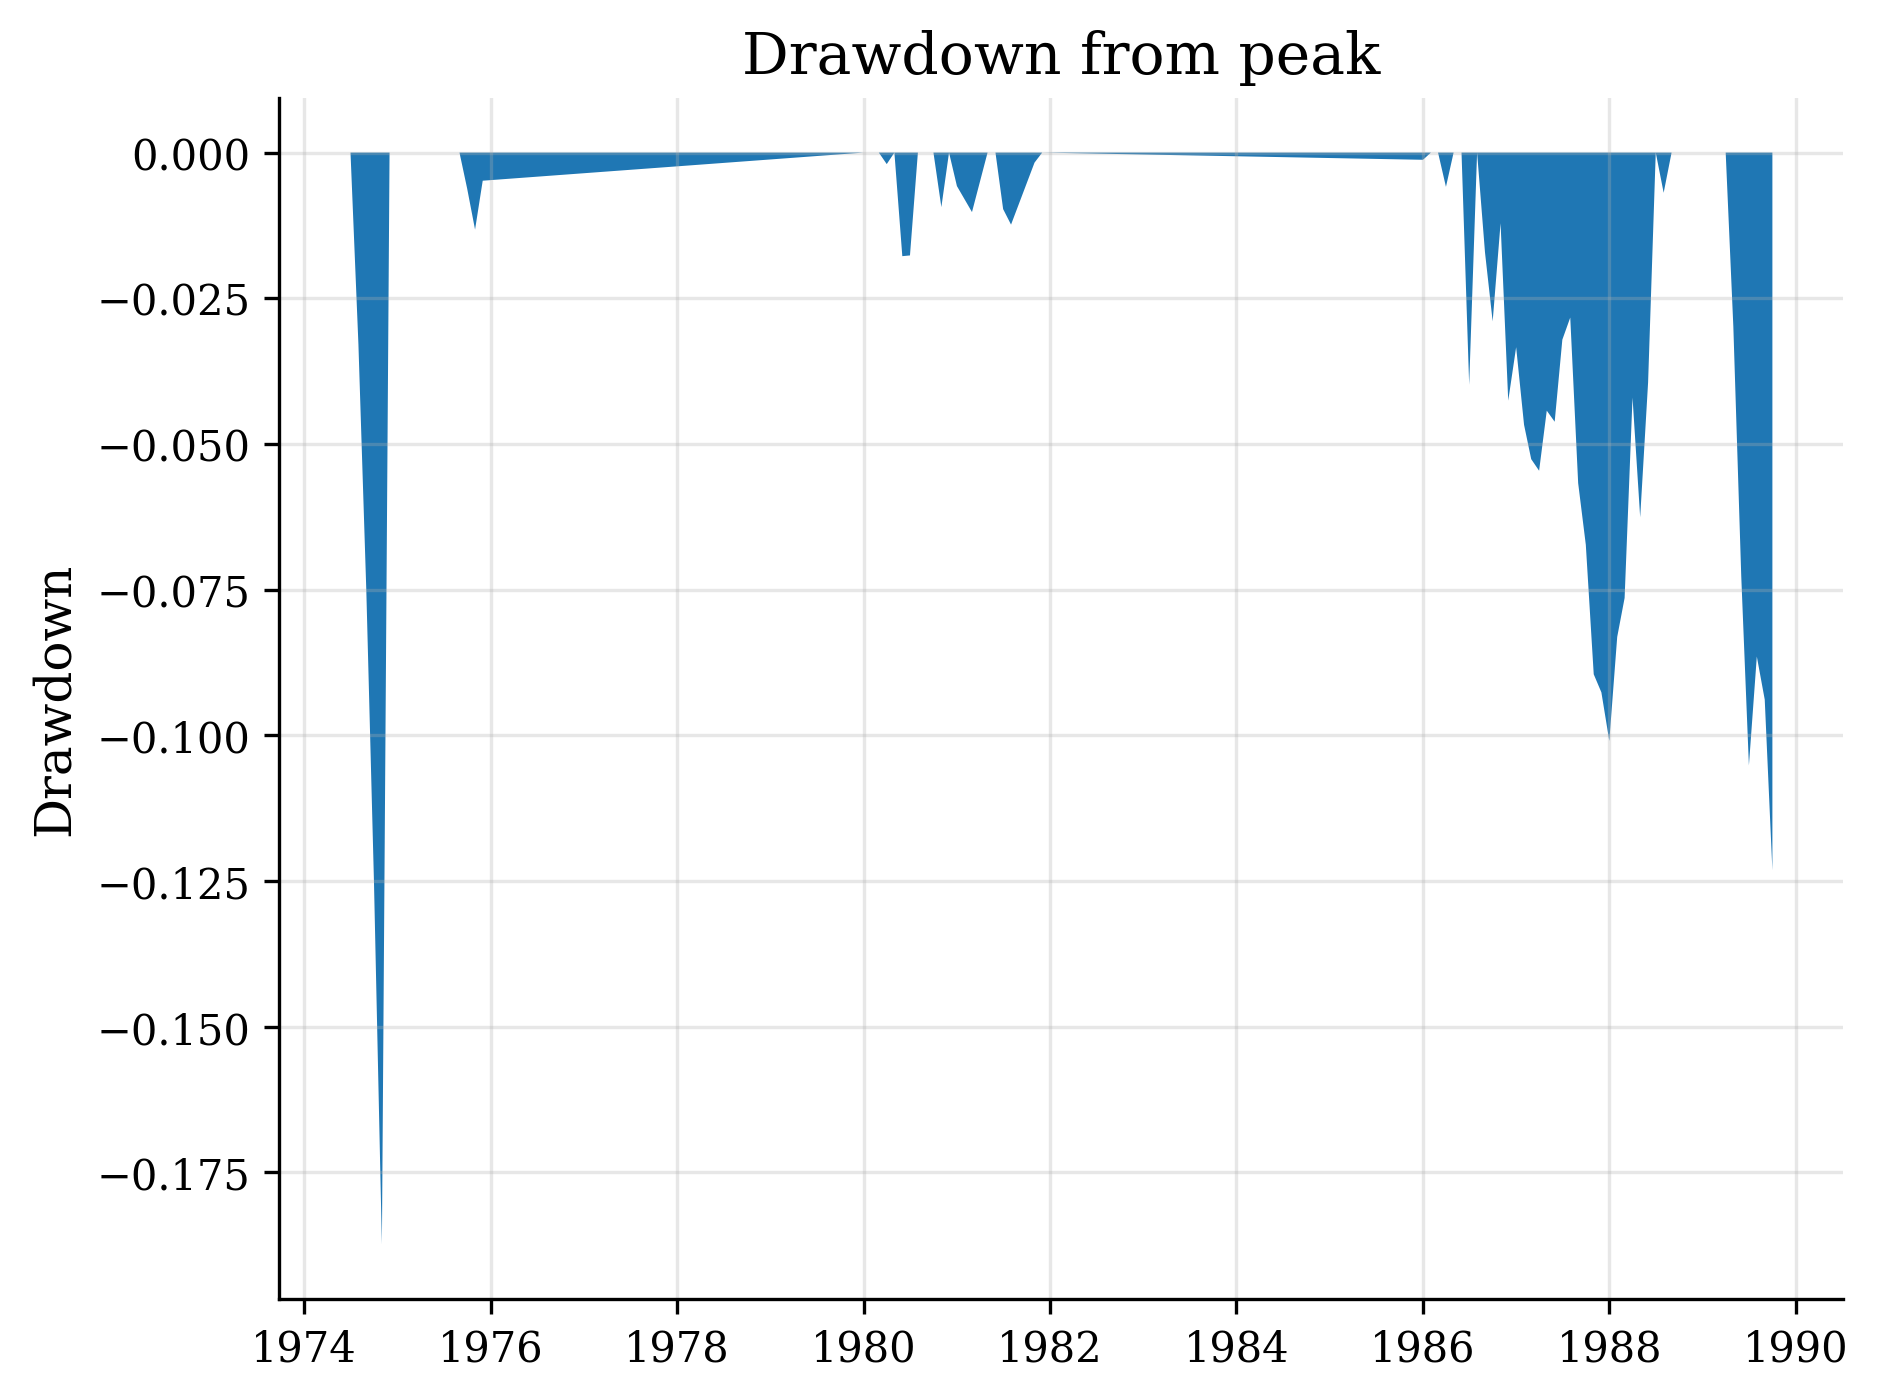

In [ ]:
#@title Visualization 1: Strategy Performance (Equity + Drawdown)

if CONFIG.get("make_plots", True):
    import matplotlib.pyplot as plt

    cum = _cum_ret if '_cum_ret' in dir() else (1 + scaled_returns.dropna()).cumprod()
    dd  = _drawdown if '_drawdown' in dir() else cum / cum.cummax() - 1

    plt.figure()
    plt.plot(cum.index, cum.values)
    plt.ylabel("Cumulative growth ($1)")
    plt.title("Equity curve (scaled returns)")
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.fill_between(dd.index, dd.values, 0)
    plt.ylabel("Drawdown")
    plt.title("Drawdown from peak")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped (make_plots=False)")

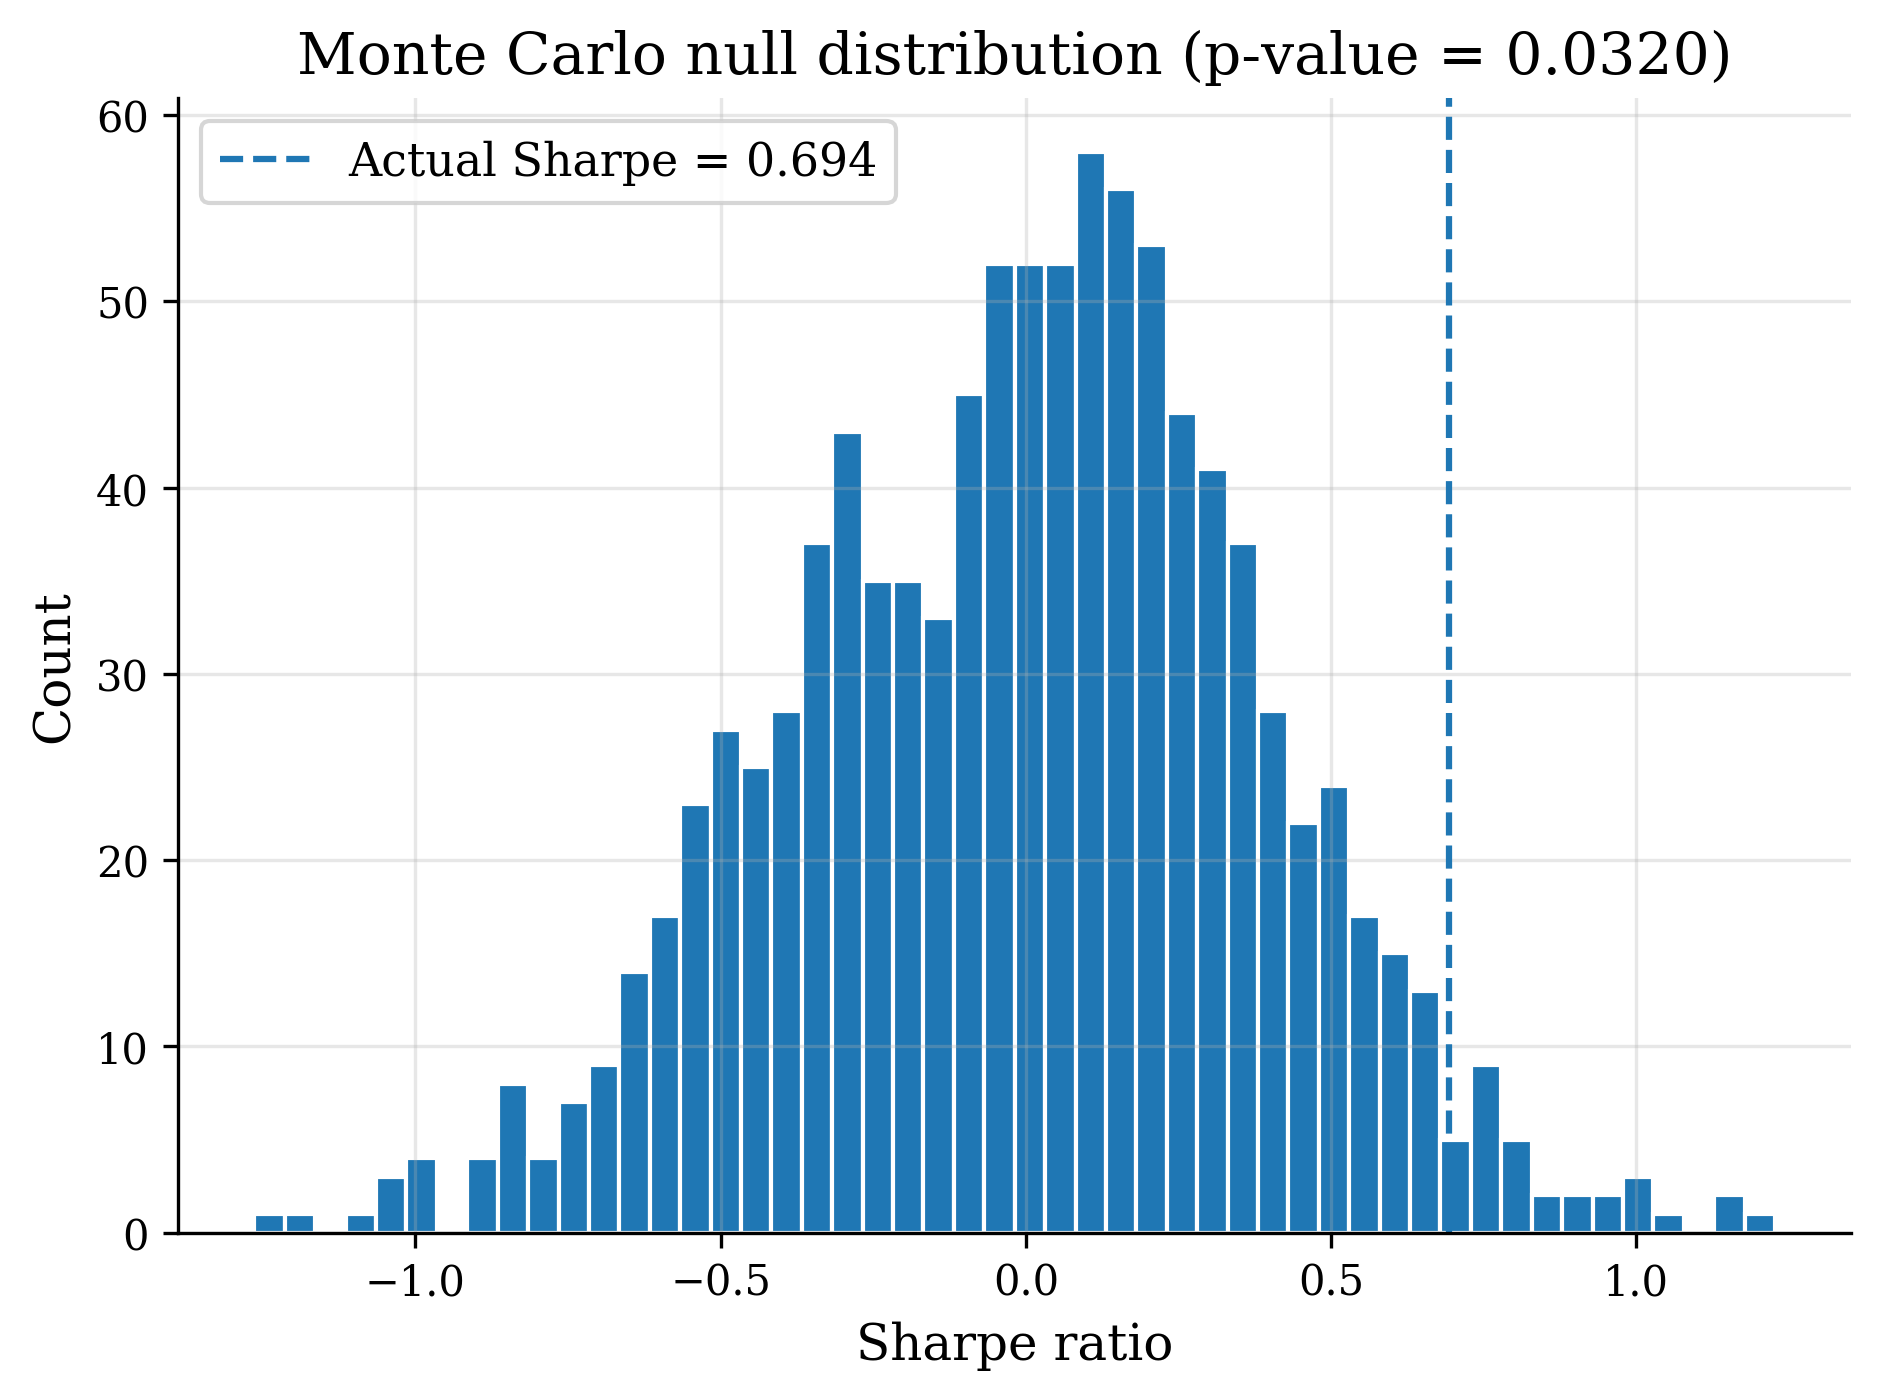

In [ ]:
#@title Visualization 3: Monte Carlo Null Distribution

if CONFIG.get("make_plots", True):
    import matplotlib.pyplot as plt
    try:
        null_sharpes = mc_result["null_sharpes"]
        actual_sharpe = mc_result["actual_sharpe"]
        p_value = mc_result["p_value"]
        if len(null_sharpes) > 0:
            plt.figure()
            plt.hist(null_sharpes, bins=50, edgecolor="white")
            plt.axvline(actual_sharpe, linestyle="--", label=f"Actual Sharpe = {actual_sharpe:.3f}")
            plt.xlabel("Sharpe ratio")
            plt.ylabel("Count")
            plt.title(f"Monte Carlo null distribution (p-value = {p_value:.4f})")
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("Monte Carlo null_sharpes is empty.")
    except (NameError, KeyError, TypeError):
        print("mc_result not yet computed.")
else:
    print("Skipped (make_plots=False)")

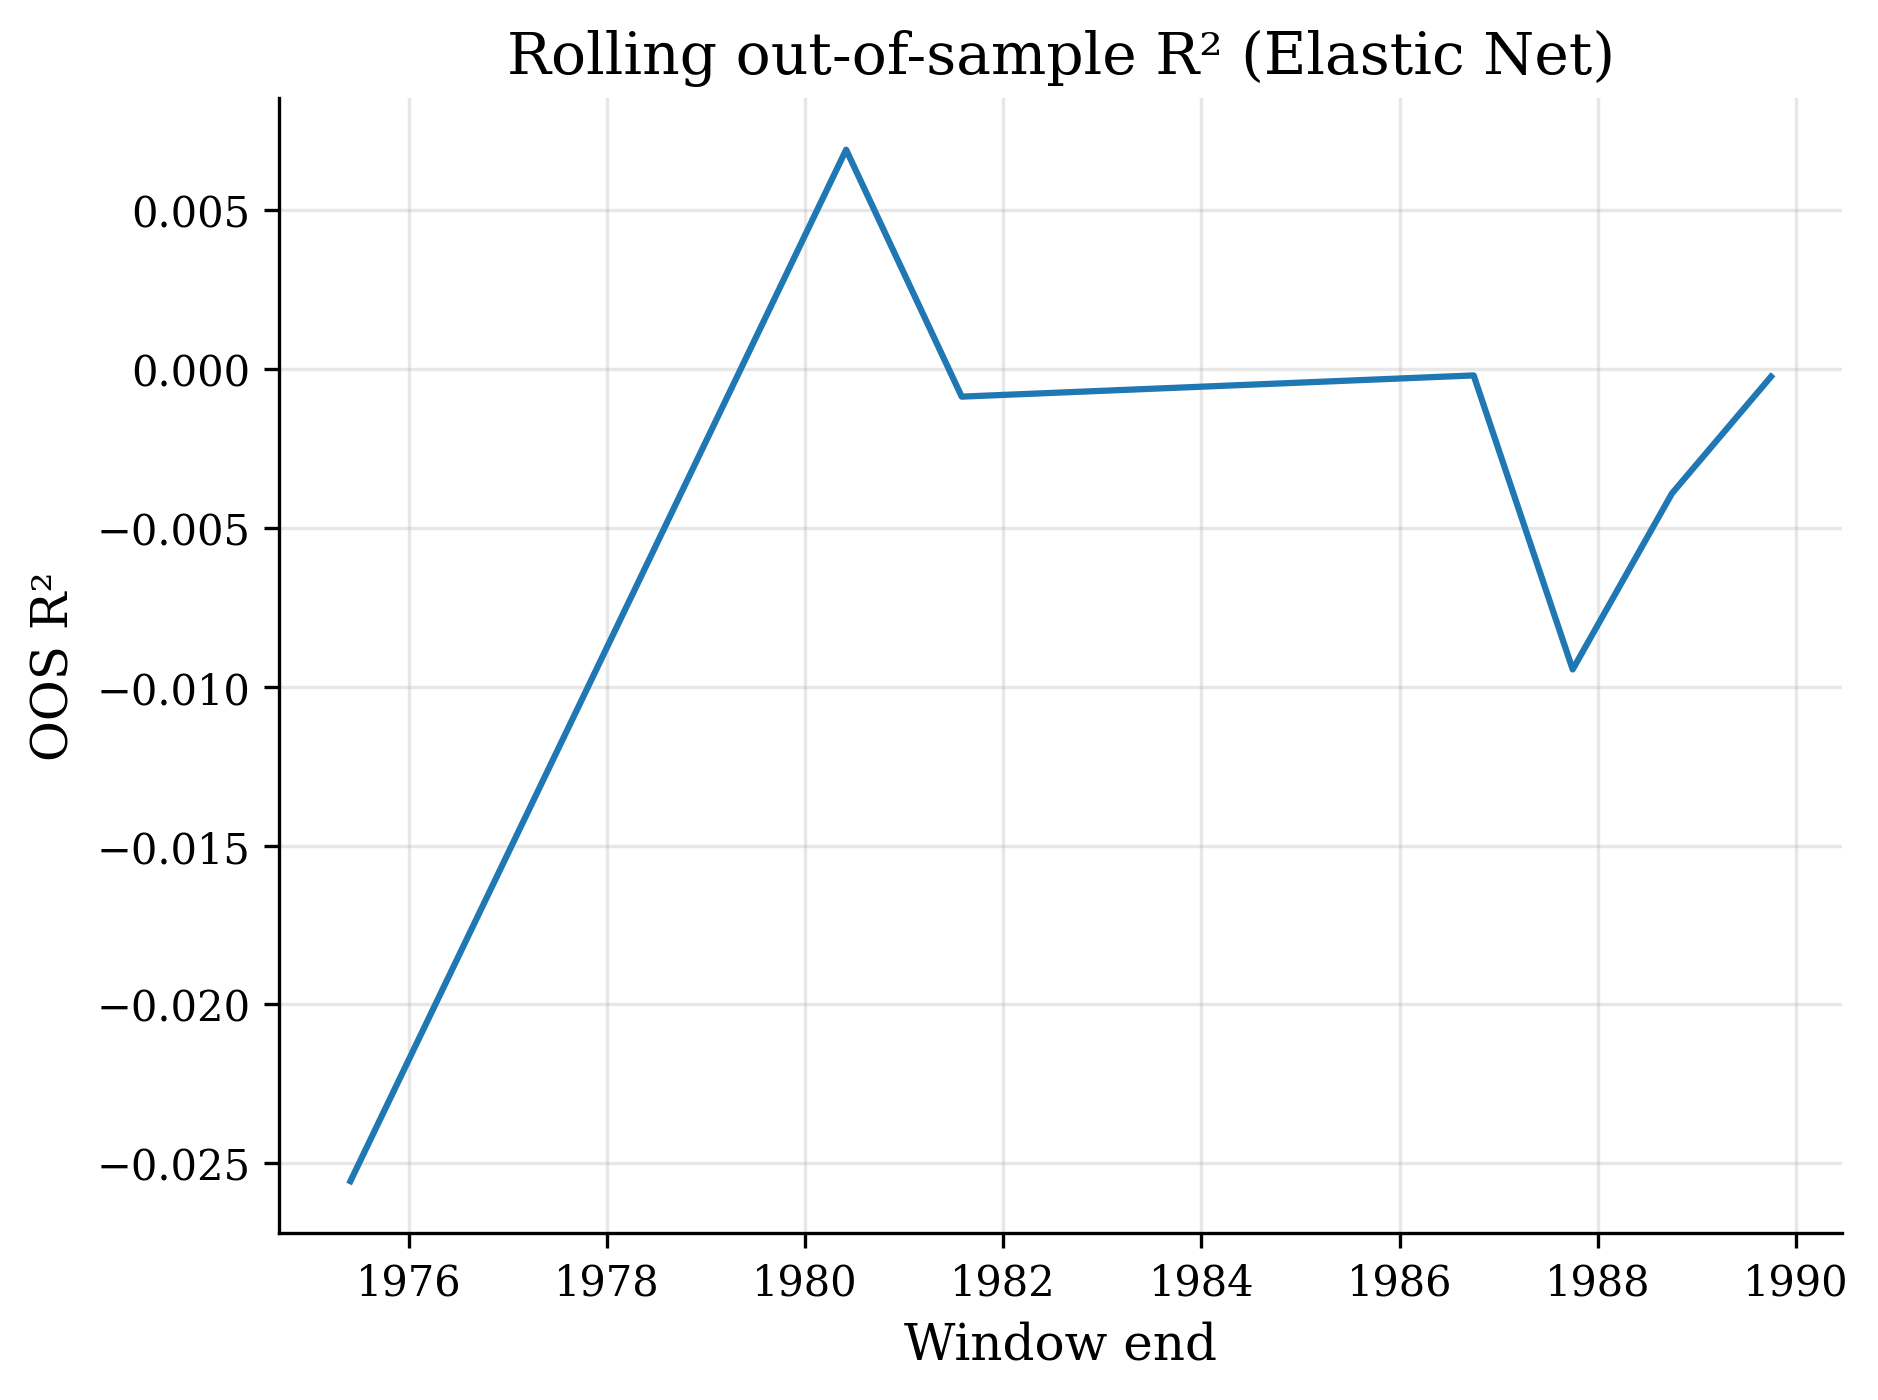

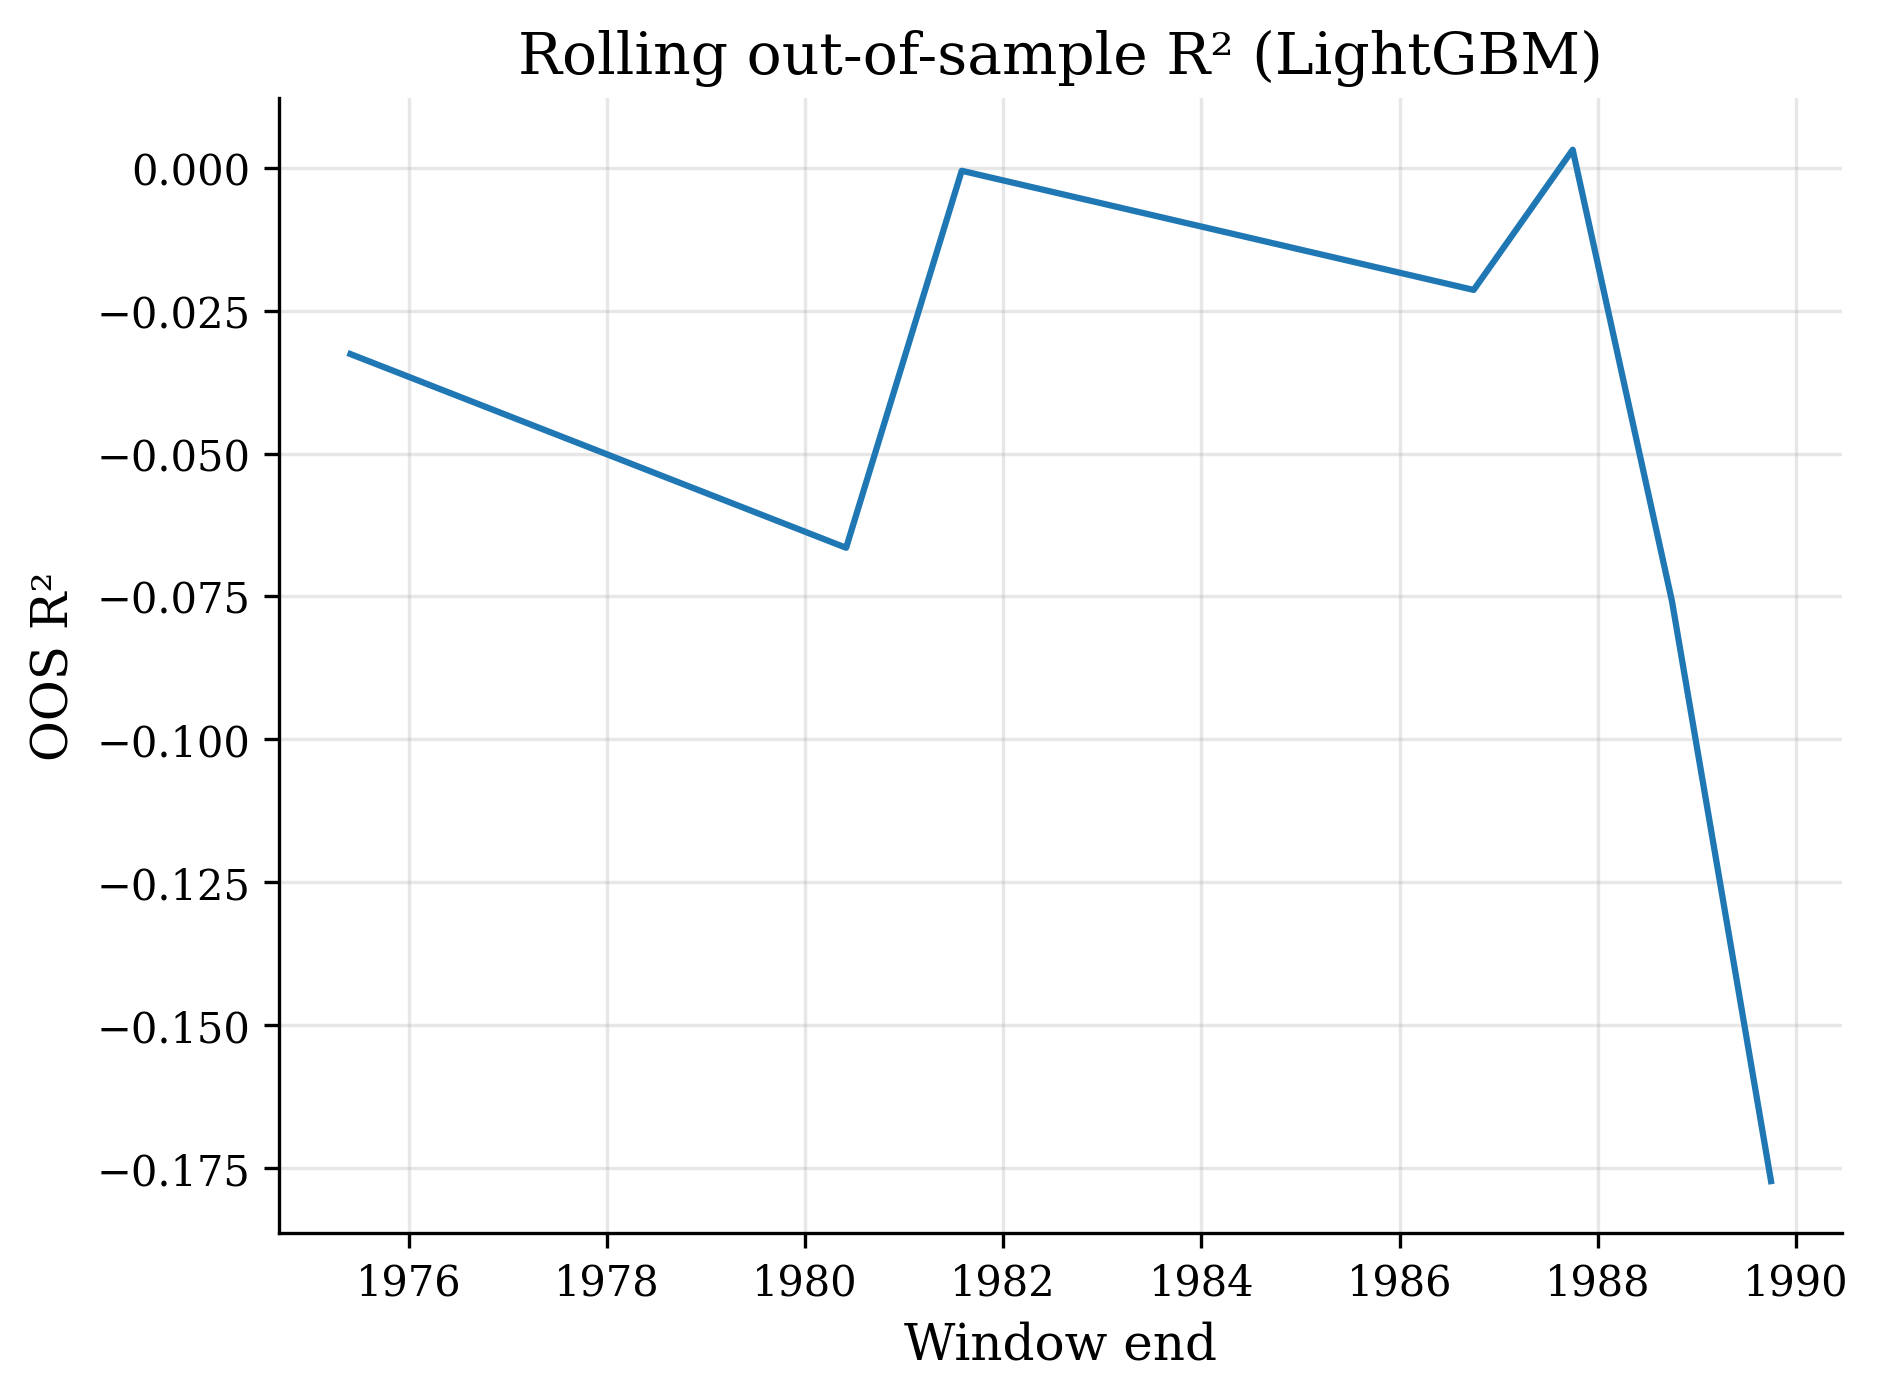

In [ ]:
#@title Visualization 4: Rolling Out-of-Sample R²

if CONFIG.get("make_plots", True):
    import matplotlib.pyplot as plt

    df_enet = pd.DataFrame(r2_records_enet).dropna(subset=["window_end", "r2_oos"])
    df_lgbm = pd.DataFrame(r2_records_lgbm).dropna(subset=["window_end", "r2_oos"])

    plt.figure()
    plt.plot(df_enet["window_end"], df_enet["r2_oos"])
    plt.xlabel("Window end")
    plt.ylabel("OOS R²")
    plt.title("Rolling out-of-sample R² (Elastic Net)")
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(df_lgbm["window_end"], df_lgbm["r2_oos"])
    plt.xlabel("Window end")
    plt.ylabel("OOS R²")
    plt.title("Rolling out-of-sample R² (LightGBM)")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped (make_plots=False)")

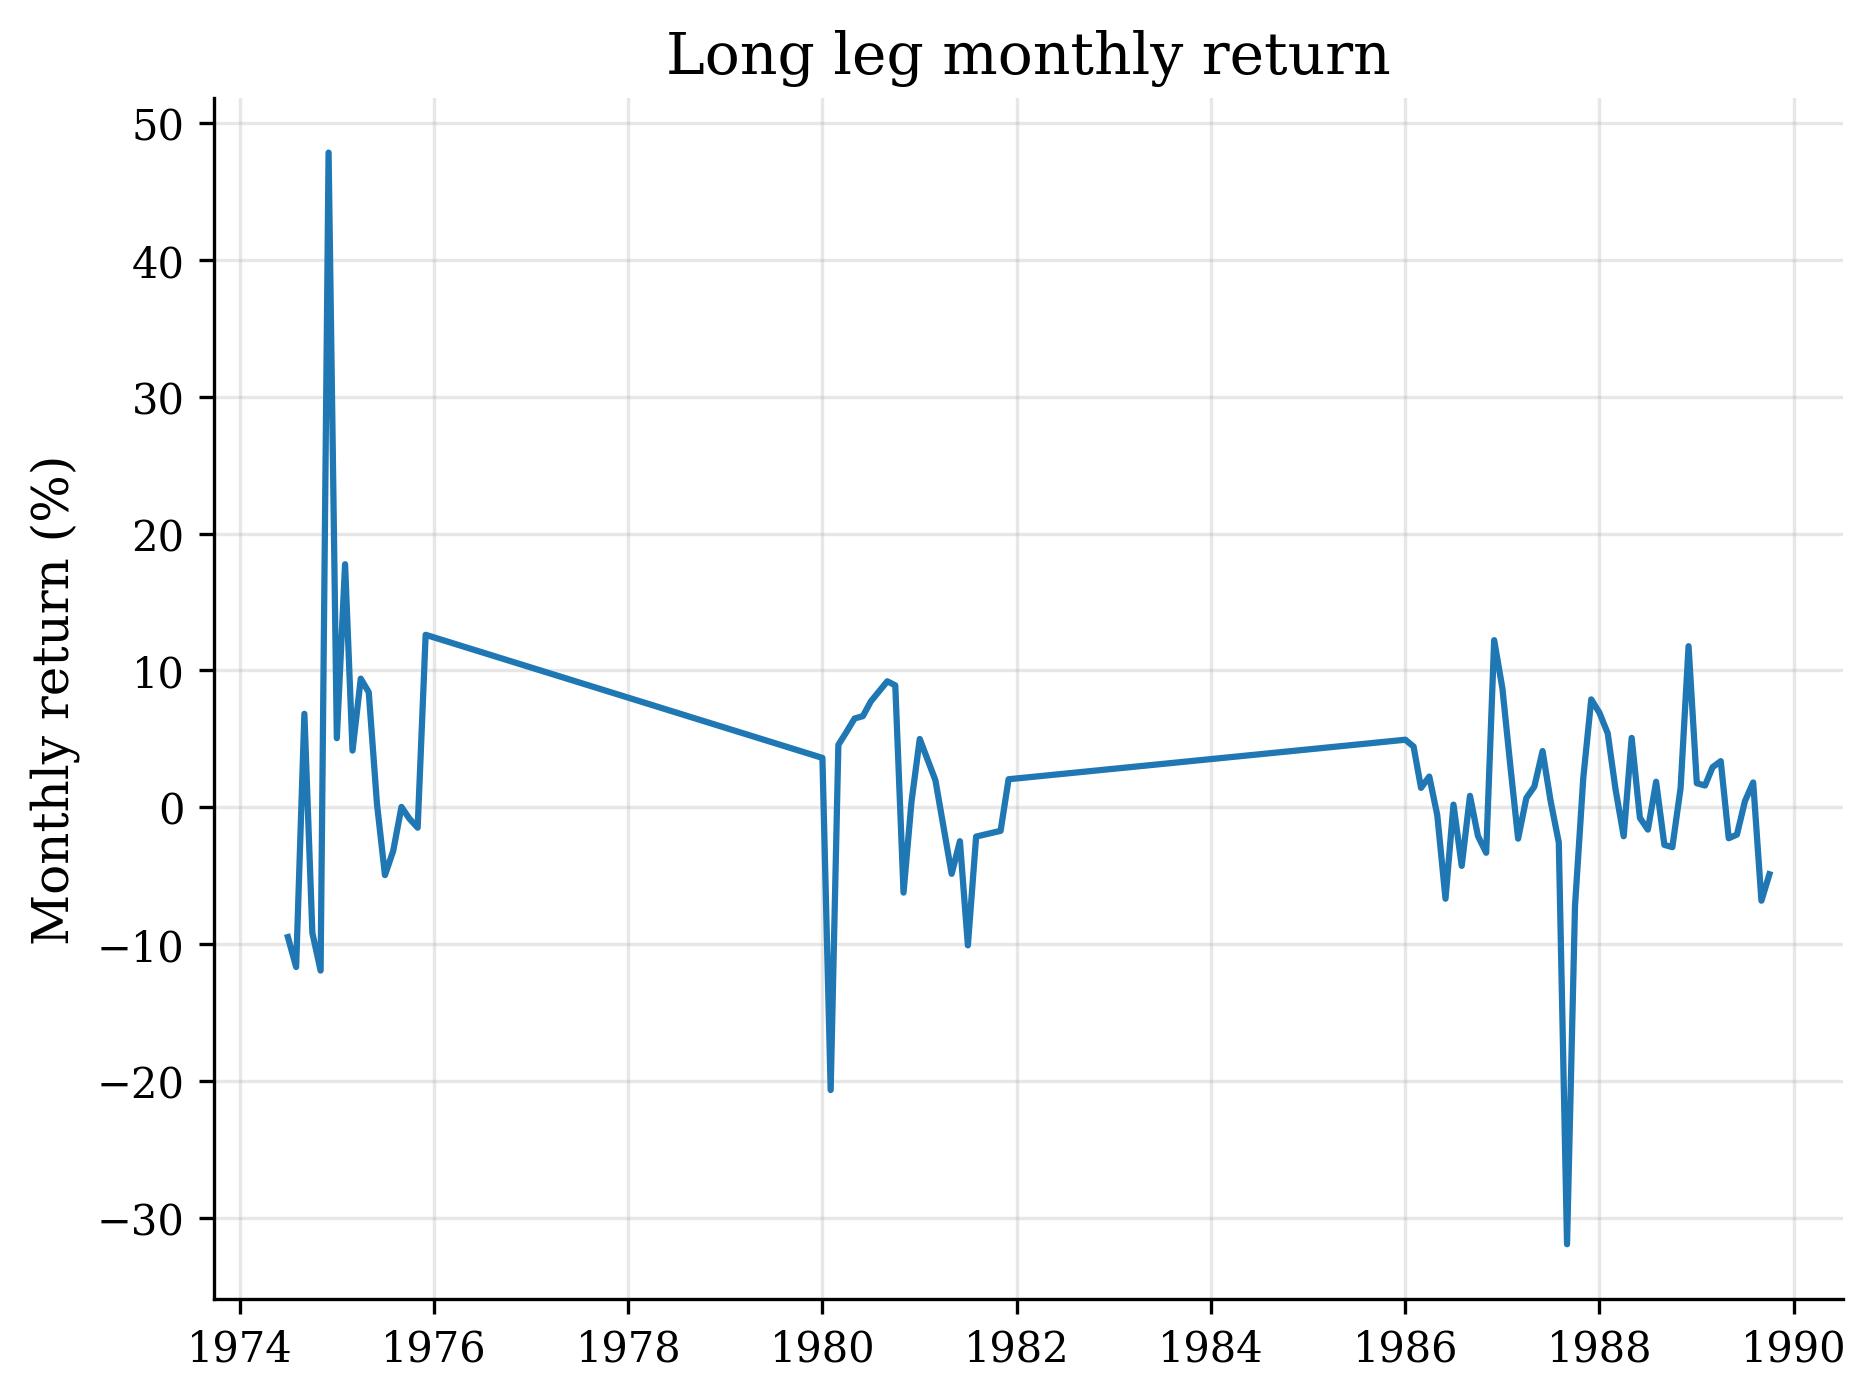

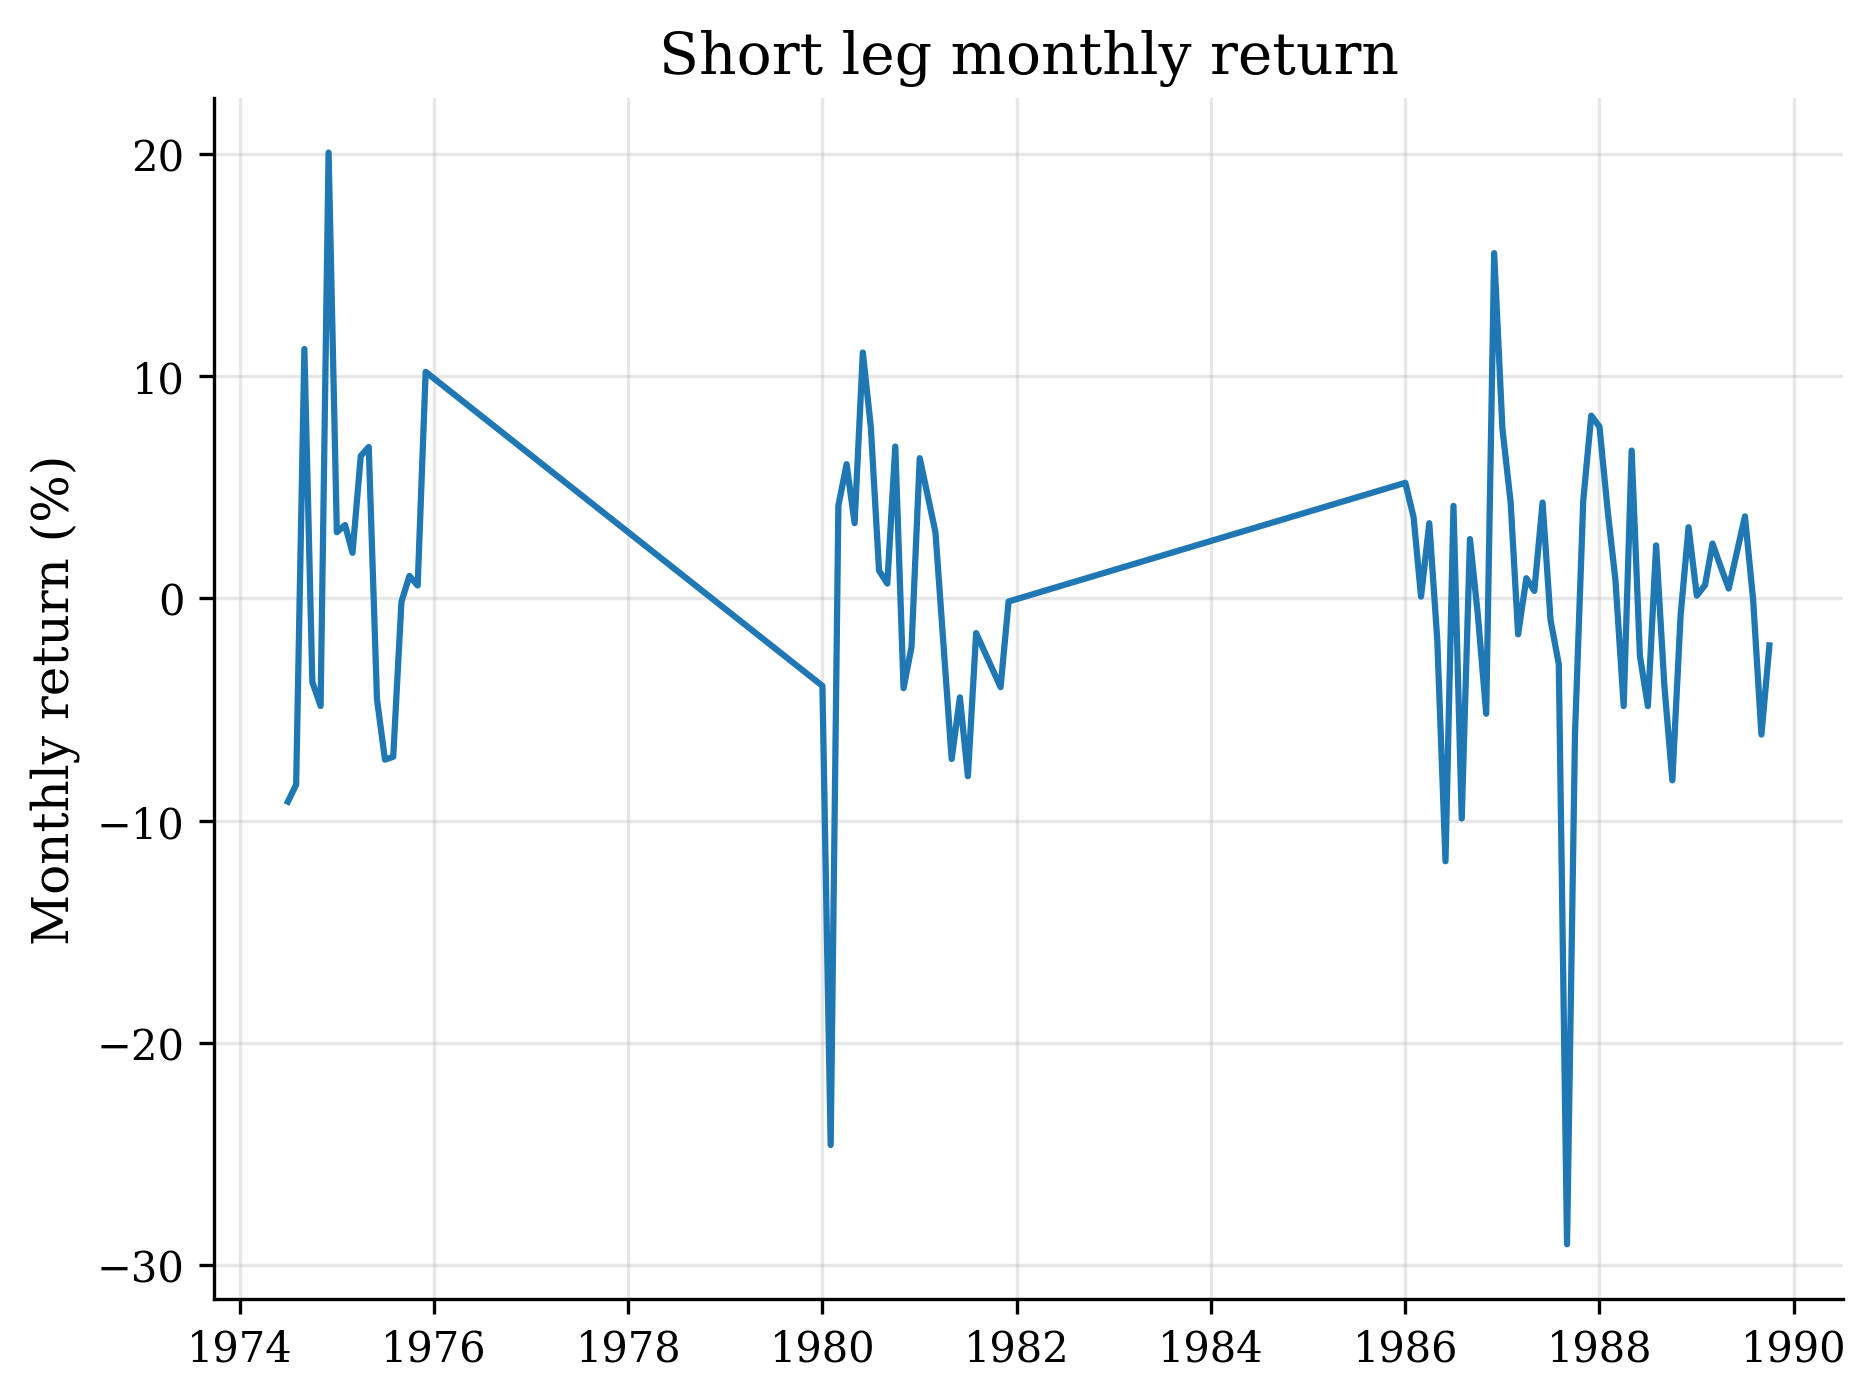

In [ ]:
#@title Visualization 5: Long vs Short Contribution

if CONFIG.get("make_plots", True):
    import matplotlib.pyplot as plt

    pred_col = "prediction" if "prediction" in preds_df.columns else "pred"
    pct = CONFIG["long_short_pct"]
    clean = preds_df.dropna(subset=[pred_col, "ret_excess_lead"])
    dates_arr = clean["date"].values
    preds_arr = clean[pred_col].values.astype(np.float32)
    rets_arr  = clean["ret_excess_lead"].values.astype(np.float32)

    unique_dates = np.unique(dates_arr)
    long_ret_arr  = np.empty(len(unique_dates), dtype=np.float64)
    short_ret_arr = np.empty(len(unique_dates), dtype=np.float64)

    for i, dt in enumerate(unique_dates):
        mask = dates_arr == dt
        p, r = preds_arr[mask], rets_arr[mask]
        k = int(np.floor(len(p) * pct))
        if k < 1:
            long_ret_arr[i] = short_ret_arr[i] = np.nan
            continue
        idx = np.argpartition(p, (k, len(p) - k))
        long_ret_arr[i]  = r[idx[-k:]].mean()
        short_ret_arr[i] = r[idx[:k]].mean()

    dt_index = pd.to_datetime(unique_dates)
    valid_l = ~np.isnan(long_ret_arr)
    valid_s = ~np.isnan(short_ret_arr)

    plt.figure()
    plt.plot(dt_index[valid_l], long_ret_arr[valid_l] * 100)
    plt.ylabel("Monthly return (%)")
    plt.title("Long leg monthly return")
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(dt_index[valid_s], short_ret_arr[valid_s] * 100)
    plt.ylabel("Monthly return (%)")
    plt.title("Short leg monthly return")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped (make_plots=False)")



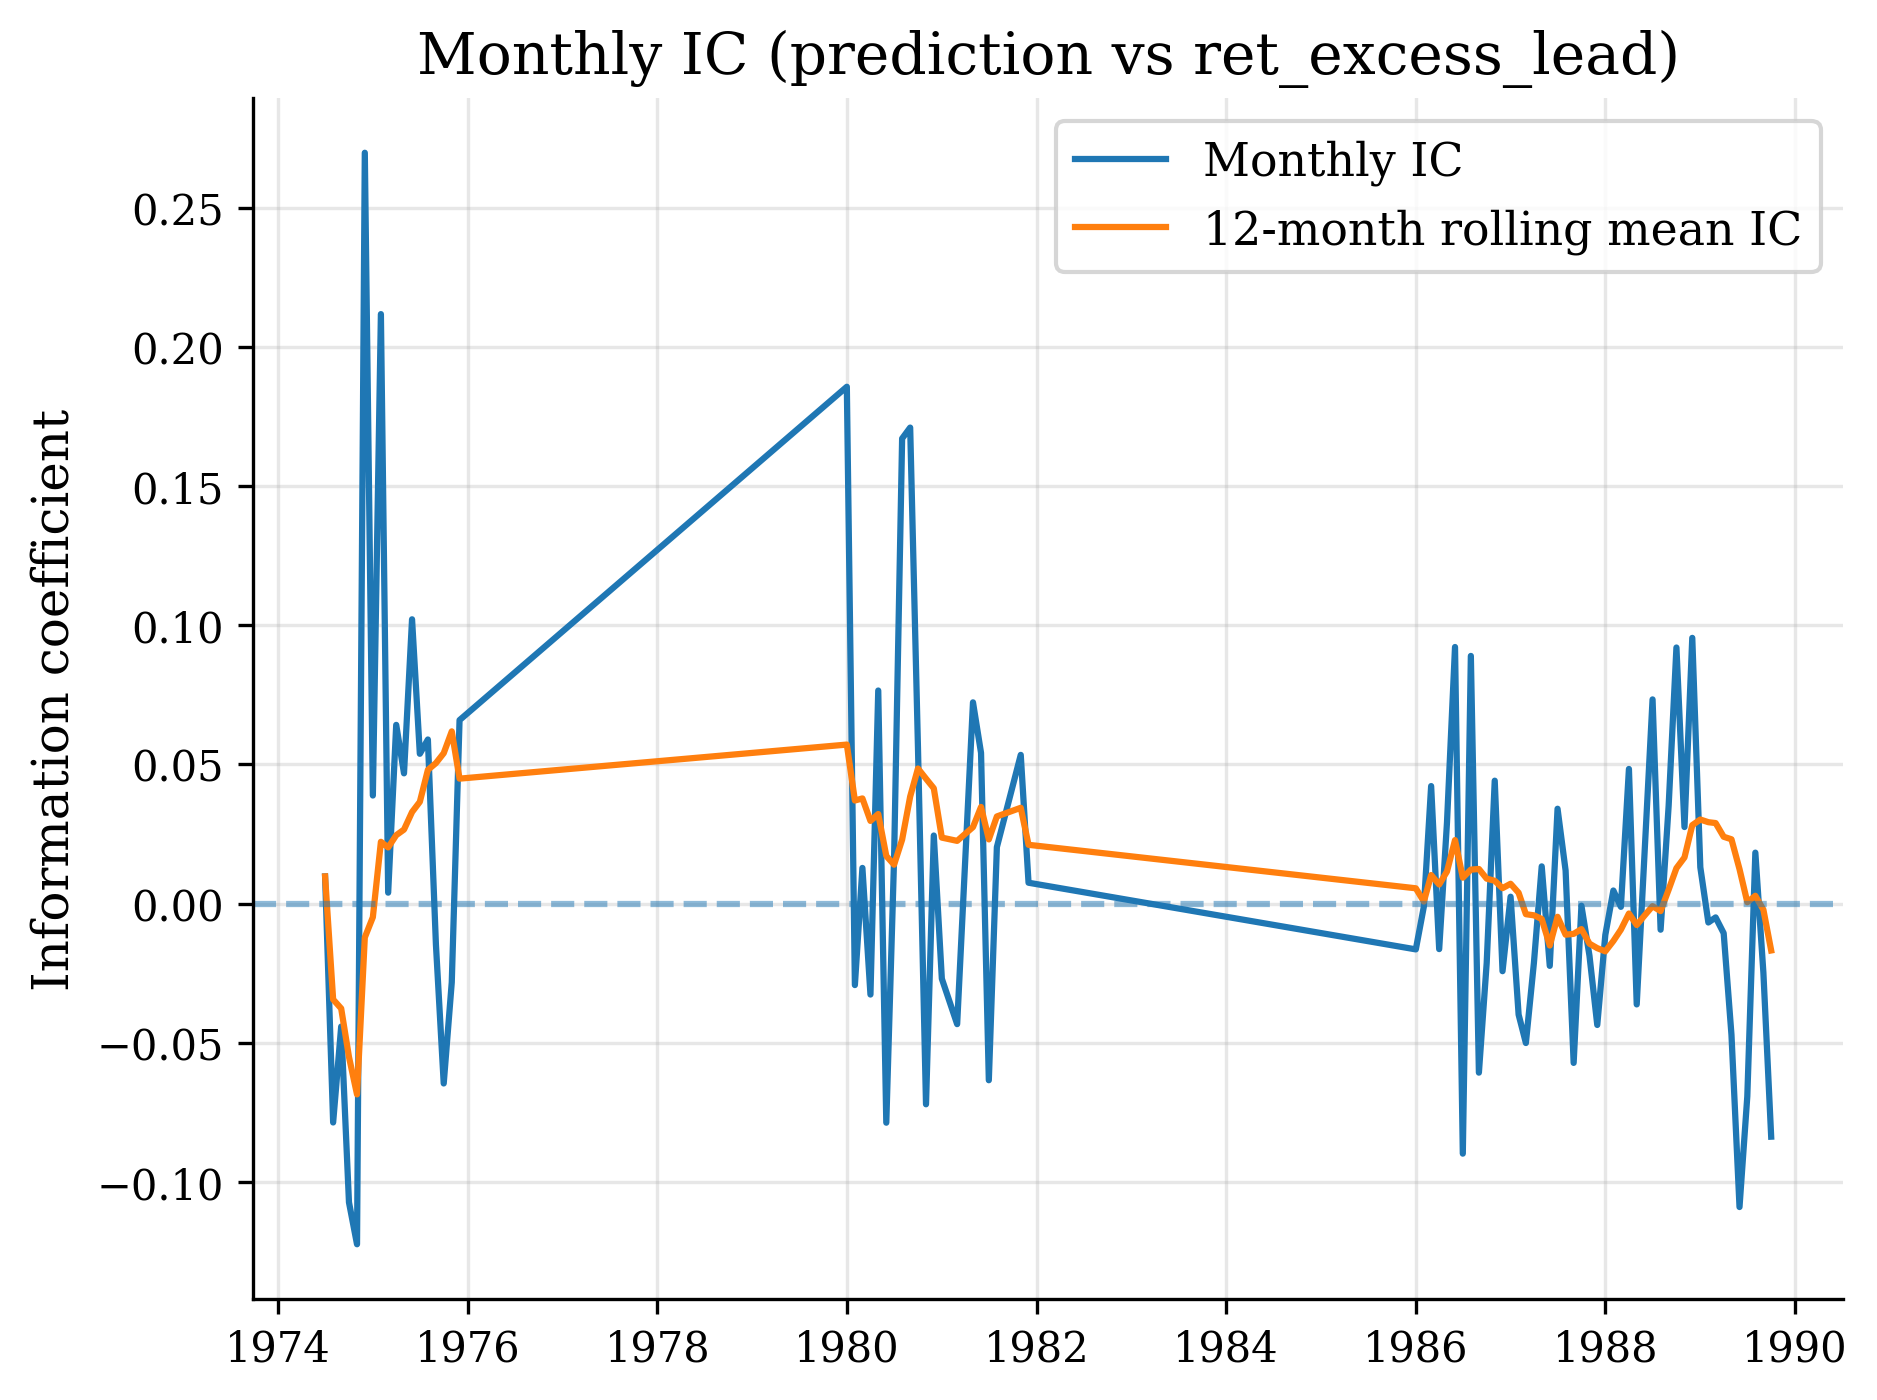

In [ ]:
#@title Visualization: Monthly Information Coefficient (IC)

if CONFIG.get("make_plots", True):
    import matplotlib.pyplot as plt

    pred_col = "prediction" if "prediction" in preds_df.columns else "pred"
    clean = preds_df.dropna(subset=[pred_col, "ret_excess_lead"])
    dates_arr = clean["date"].values
    p_arr = clean[pred_col].values
    r_arr = clean["ret_excess_lead"].values

    unique_dates = np.unique(dates_arr)
    ic_vals = np.empty(len(unique_dates), dtype=np.float64)
    for i, dt in enumerate(unique_dates):
        mask = dates_arr == dt
        if mask.sum() < 3:
            ic_vals[i] = np.nan
            continue
        ic_vals[i] = np.corrcoef(p_arr[mask], r_arr[mask])[0, 1]

    ic_series = pd.Series(ic_vals, index=pd.to_datetime(unique_dates)).dropna()
    roll_ic = ic_series.rolling(12, min_periods=1).mean()

    plt.figure()
    plt.plot(ic_series.index, ic_series.values, label="Monthly IC")
    plt.plot(roll_ic.index, roll_ic.values, label="12-month rolling mean IC")
    plt.axhline(0, linestyle="--", alpha=0.5)
    plt.ylabel("Information coefficient")
    plt.title("Monthly IC (prediction vs ret_excess_lead)")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Skipped (make_plots=False)")

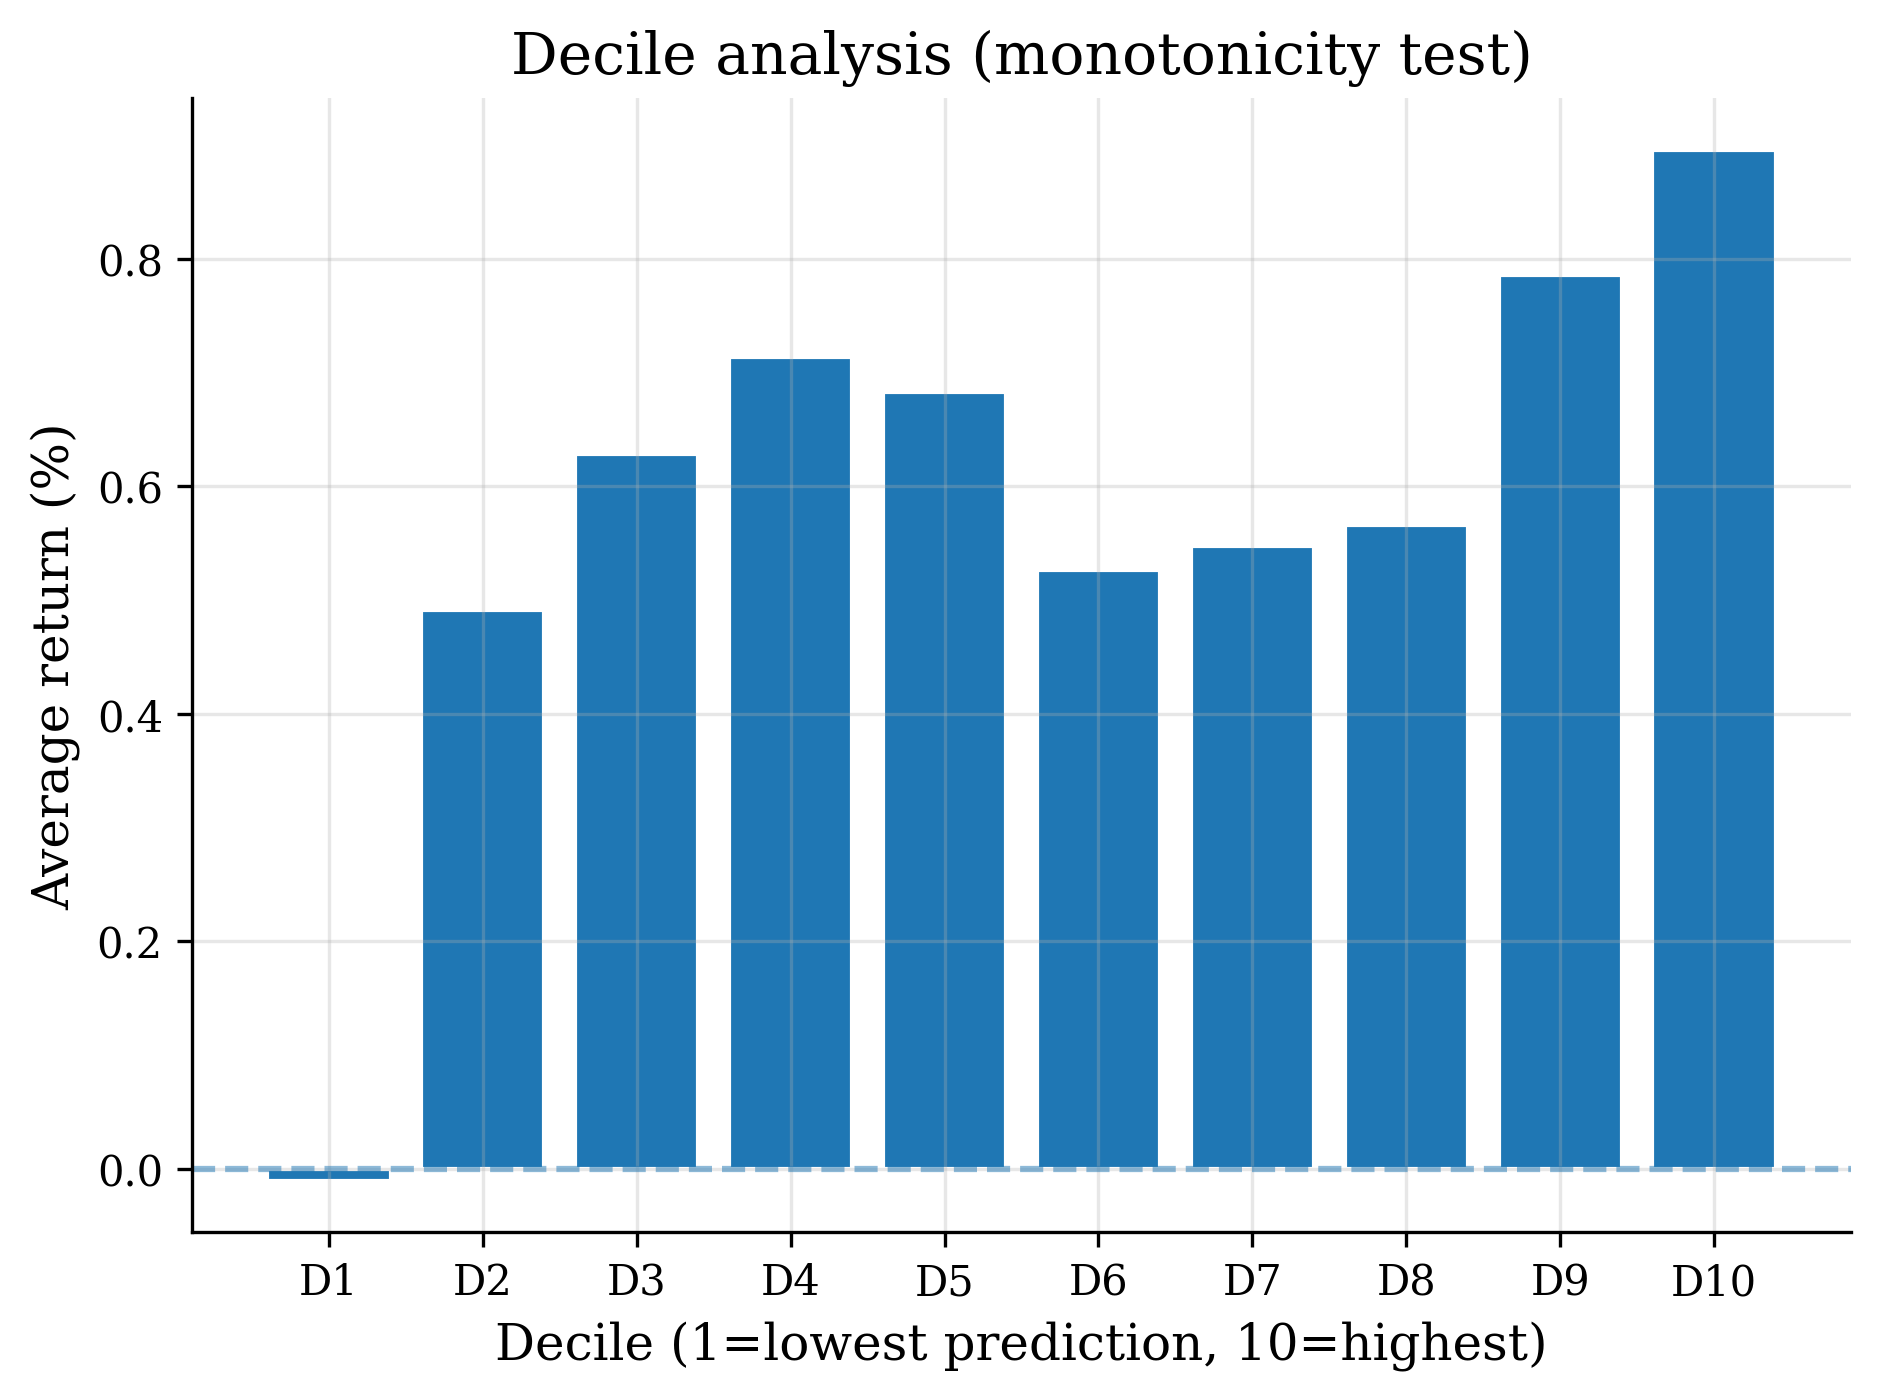

In [ ]:
#@title Visualization: Decile Analysis (Monotonicity Test)

if CONFIG.get("make_plots", True):
    import matplotlib.pyplot as plt

    pred_col = "prediction" if "prediction" in preds_df.columns else "pred"
    _df_dec = preds_df[["date", pred_col, "ret_excess_lead"]].dropna()
    _df_dec["decile"] = _df_dec.groupby("date")[pred_col].transform(
        lambda x: pd.qcut(x.rank(method="first"), 10, labels=np.arange(1, 11))
    )
    decile_avg = _df_dec.groupby("decile")["ret_excess_lead"].mean()
    x_pos = np.arange(len(decile_avg))

    plt.figure()
    plt.bar(x_pos, decile_avg.values * 100, edgecolor="white")
    plt.xticks(x_pos, [f"D{d}" for d in decile_avg.index])
    plt.xlabel("Decile (1=lowest prediction, 10=highest)")
    plt.ylabel("Average return (%)")
    plt.title("Decile analysis (monotonicity test)")
    plt.axhline(0, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
    del _df_dec
else:
    print("Skipped (make_plots=False)")

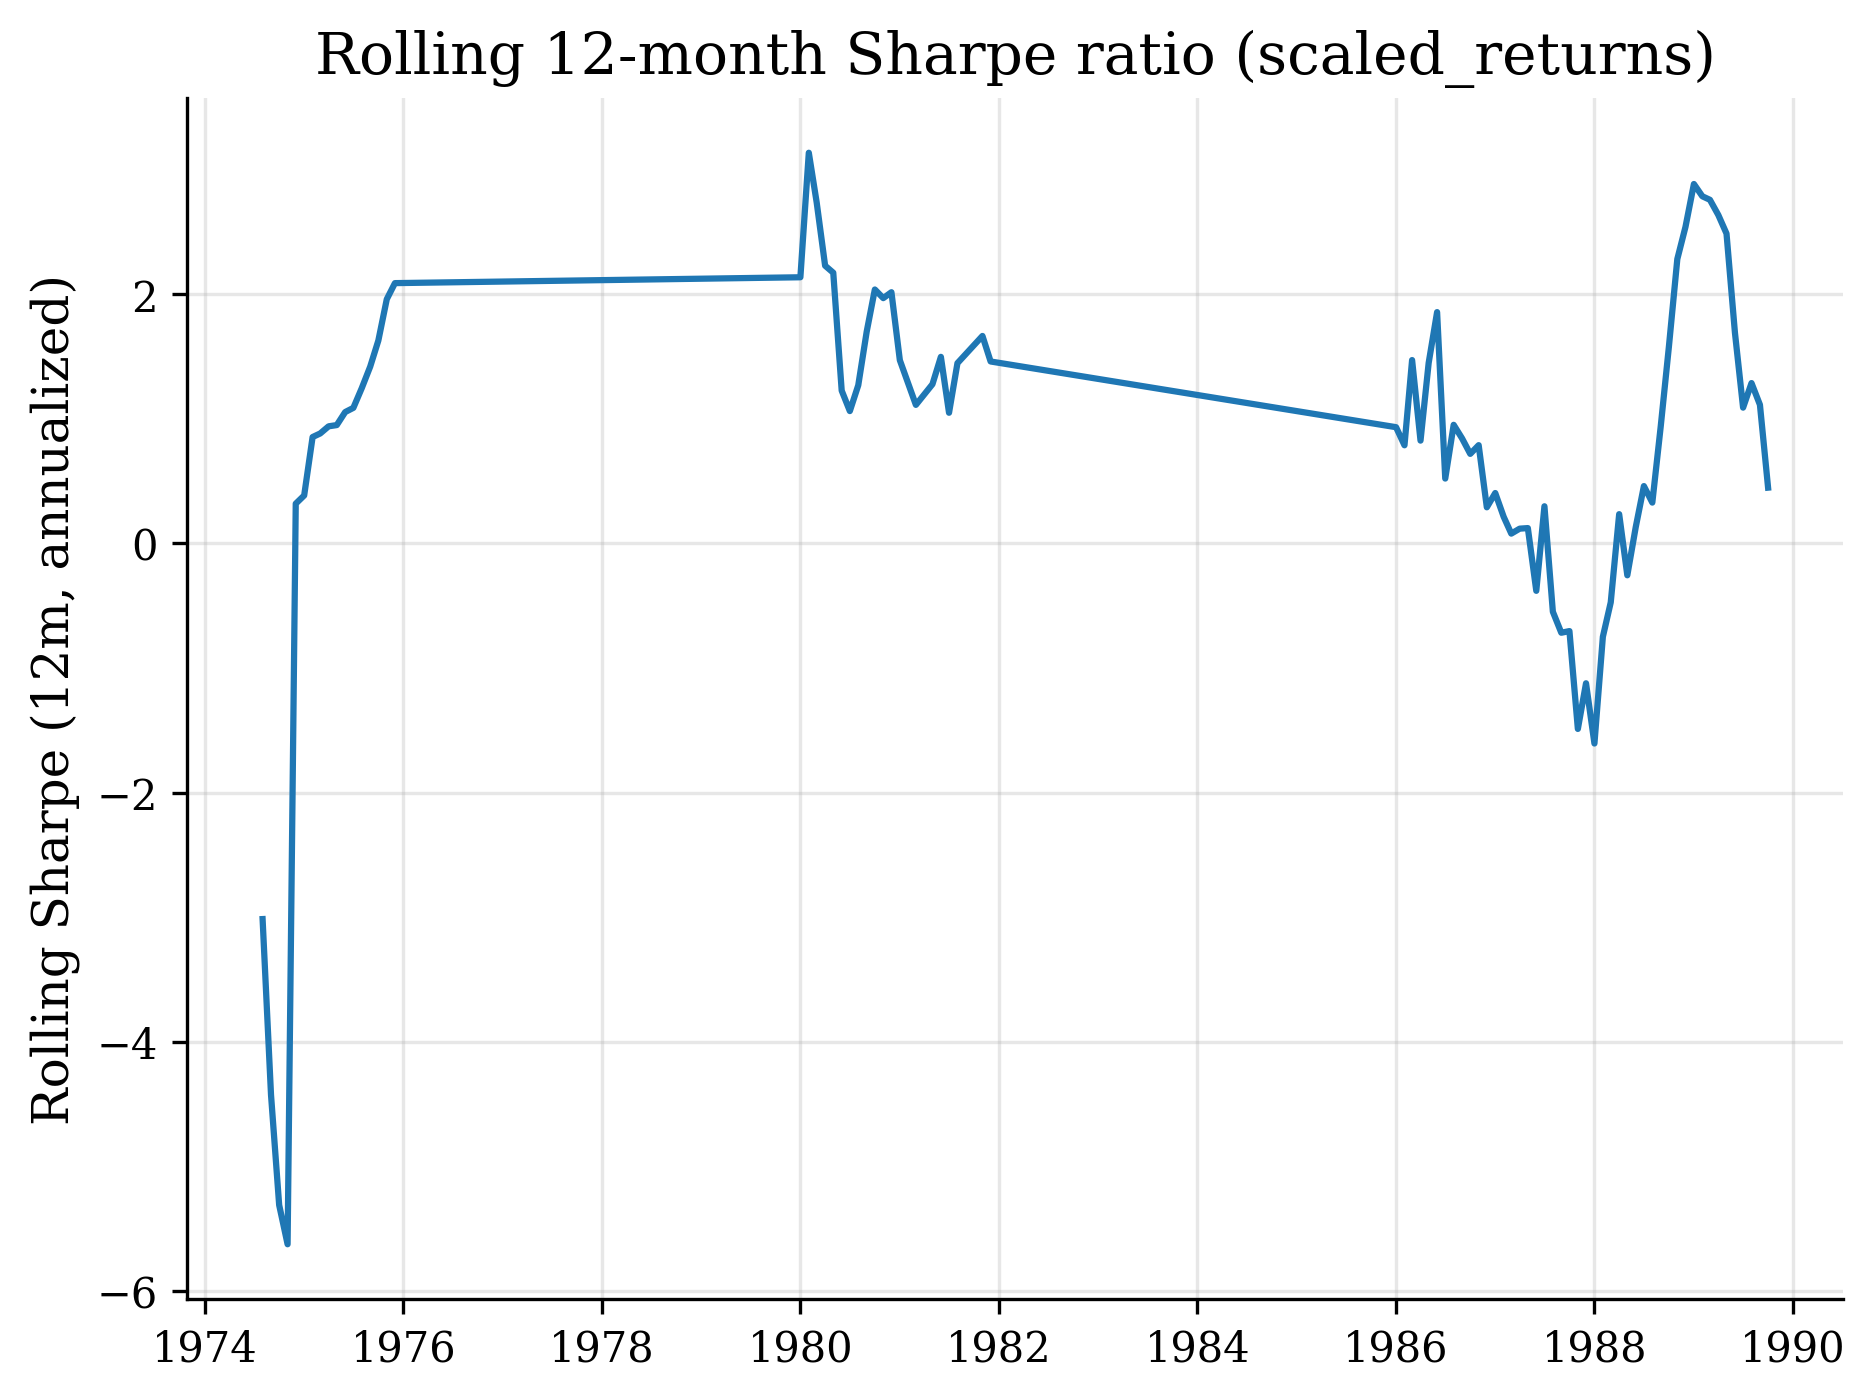

In [ ]:
#@title Visualization: Rolling Sharpe Ratio (12M)

if CONFIG.get("make_plots", True):
    import matplotlib.pyplot as plt

    r = scaled_returns.dropna()
    roll = r.rolling(12, min_periods=1)
    roll_sharpe = (roll.mean() / roll.std().replace(0, np.nan)) * np.sqrt(12)
    roll_sharpe = roll_sharpe.dropna()

    plt.figure()
    plt.plot(roll_sharpe.index, roll_sharpe.values)
    plt.ylabel("Rolling Sharpe (12m, annualized)")
    plt.title("Rolling 12-month Sharpe ratio (scaled_returns)")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped (make_plots=False)")

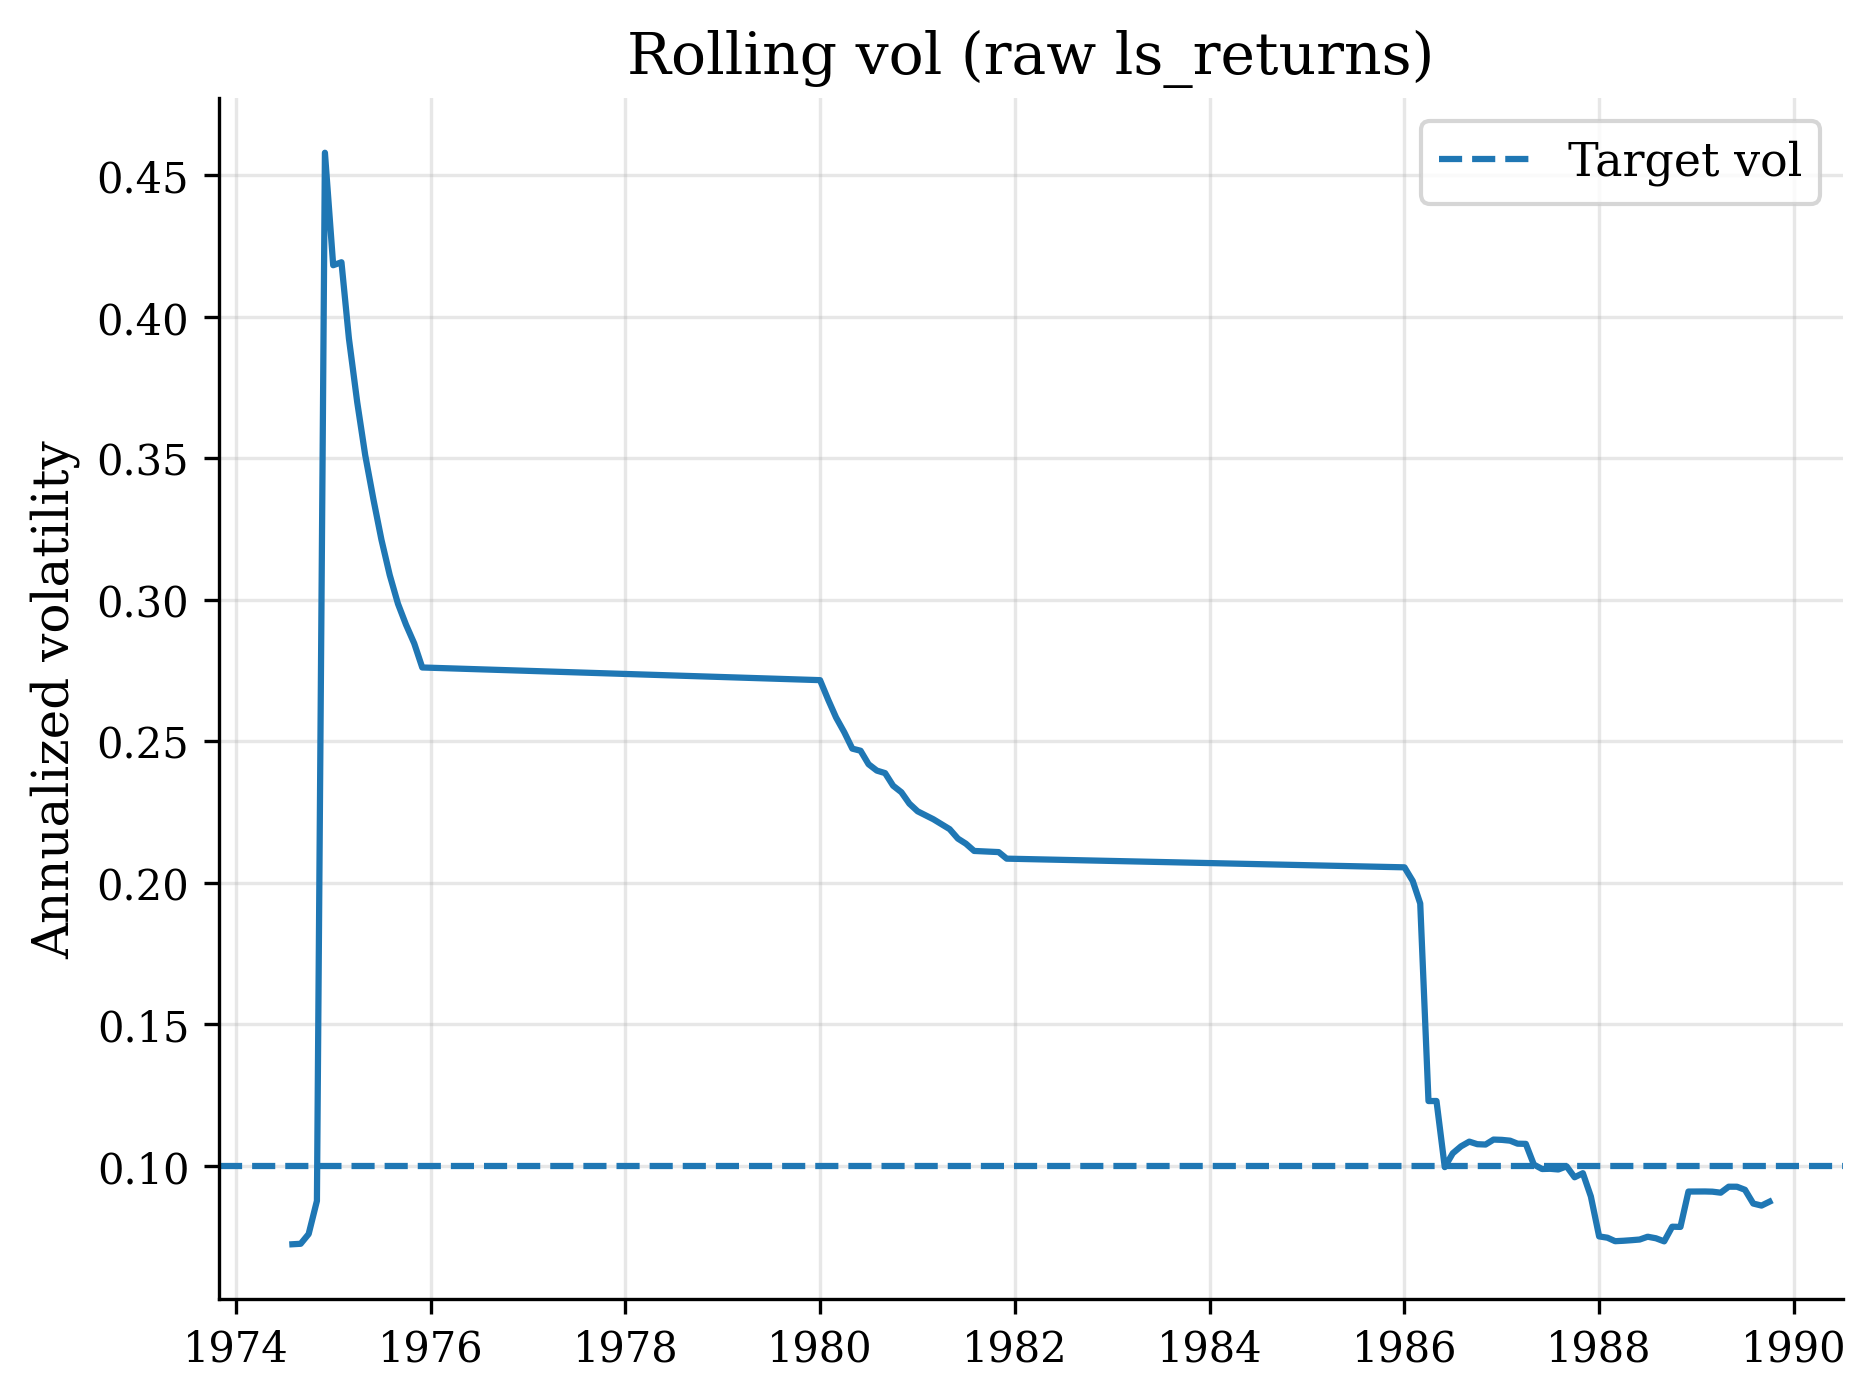

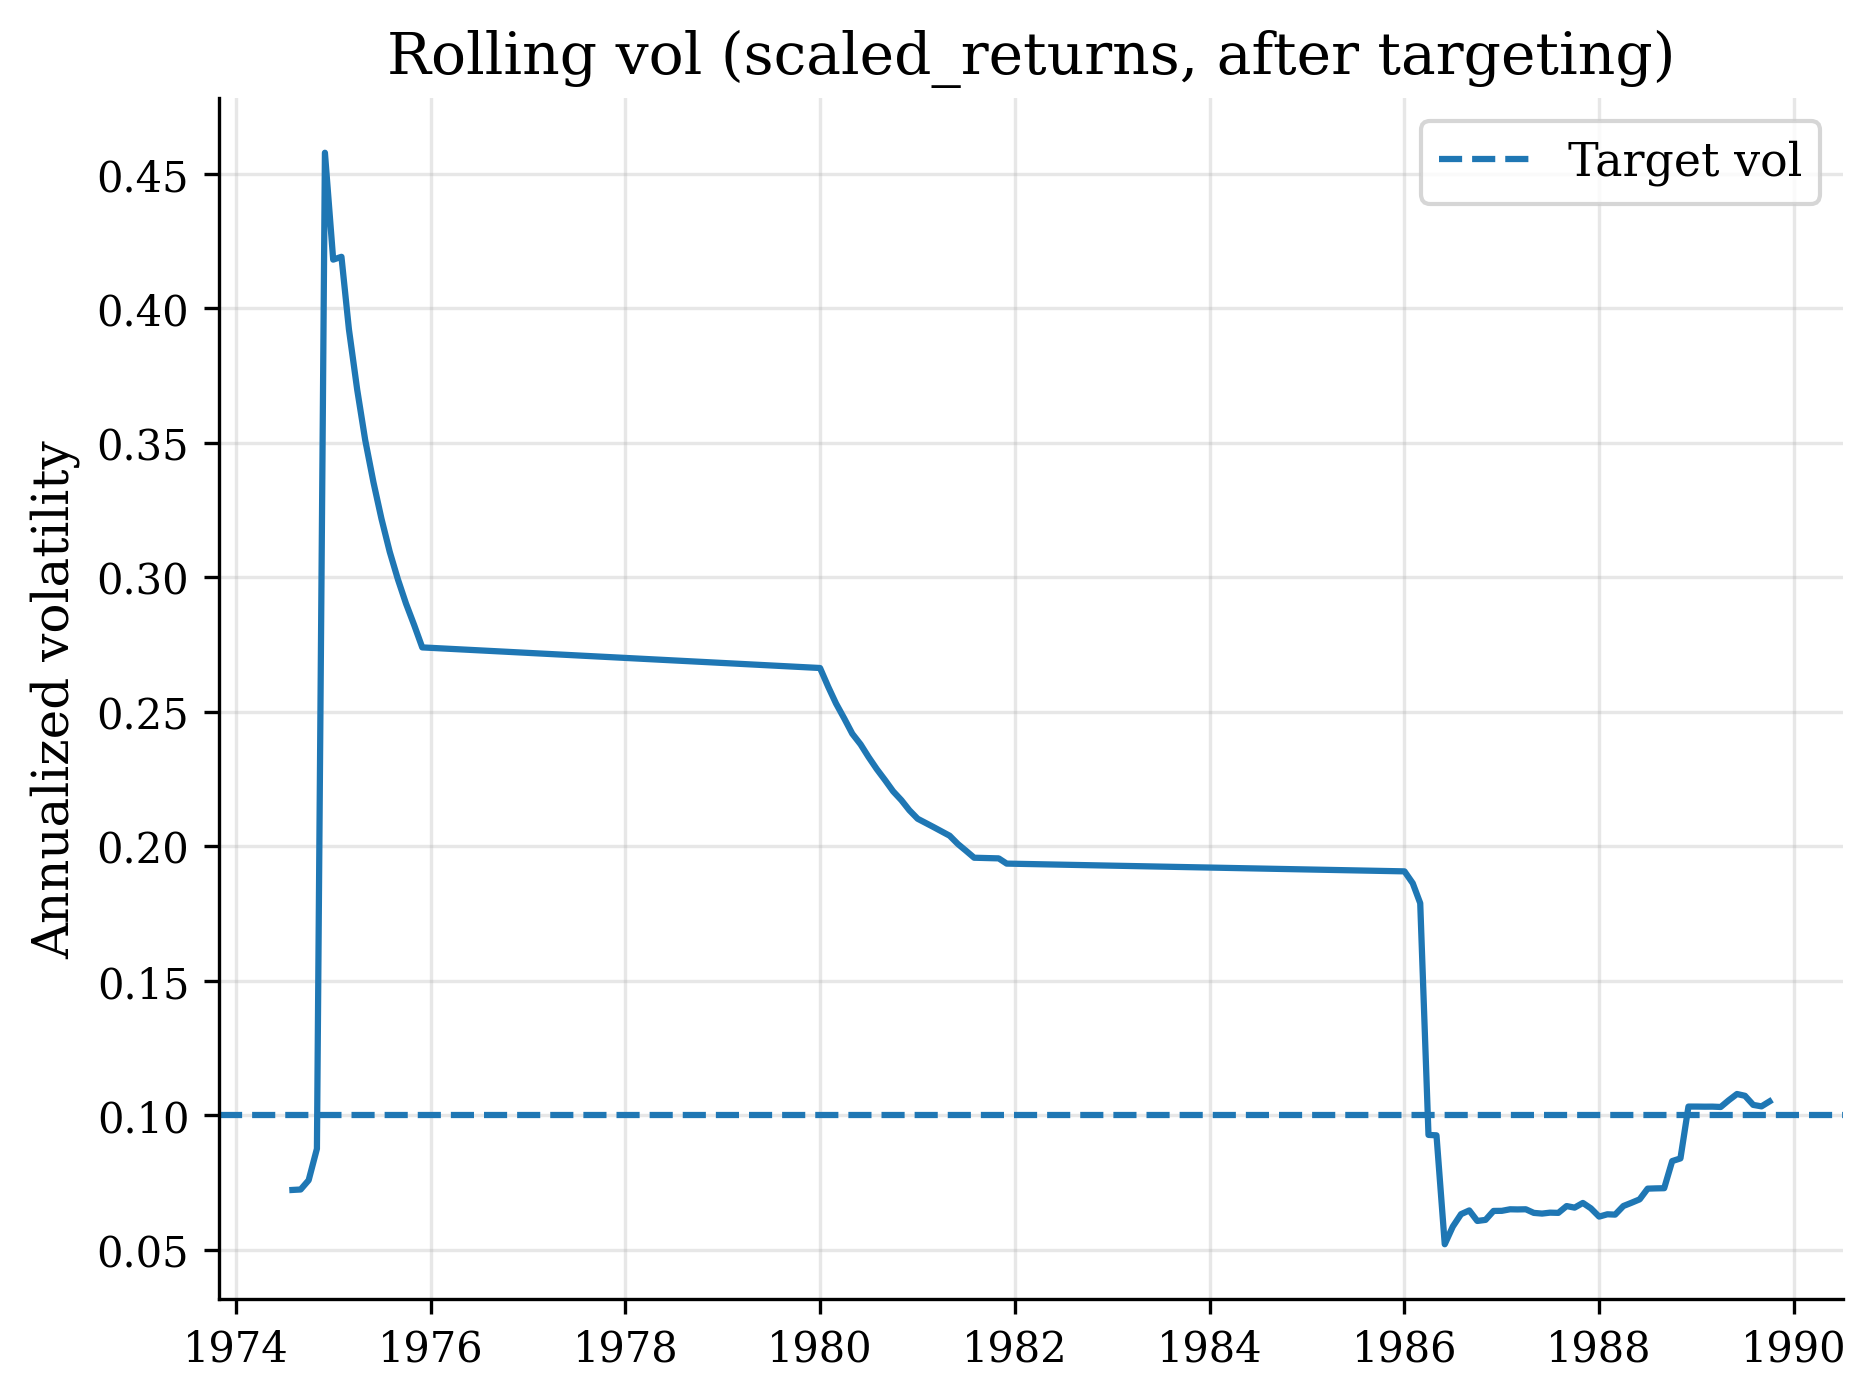

In [ ]:
#@title Visualization: Volatility Targeting Check

if CONFIG.get("make_plots", True):
    import matplotlib.pyplot as plt

    ls_returns = strategy_returns.dropna()
    scaled_clean = scaled_returns.dropna()
    vol_window = CONFIG["vol_window"]
    target_vol_annual = CONFIG.get("target_vol_annual", CONFIG["target_vol"])

    vol_raw = ls_returns.rolling(vol_window, min_periods=1).std() * np.sqrt(12)
    vol_scaled = scaled_clean.rolling(vol_window, min_periods=1).std() * np.sqrt(12)

    plt.figure()
    plt.plot(vol_raw.index, vol_raw.values)
    plt.axhline(target_vol_annual, linestyle="--", label="Target vol")
    plt.ylabel("Annualized volatility")
    plt.title("Rolling vol (raw ls_returns)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(vol_scaled.index, vol_scaled.values)
    plt.axhline(target_vol_annual, linestyle="--", label="Target vol")
    plt.ylabel("Annualized volatility")
    plt.title("Rolling vol (scaled_returns, after targeting)")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Skipped (make_plots=False)")

In [ ]:
#@title Execution Toggles (re-override — only needed if running cells individually)
# On "Run All", CONFIG in Cell 3 is the single source of truth.
# Use this cell only to change flags mid-session without rerunning Cell 3.

run_smoke_tests = True       #@param {type:"boolean"}
run_monte_carlo = True       #@param {type:"boolean"}
monte_carlo_sims_fast = 200  #@param {type:"integer"}
make_plots = True            #@param {type:"boolean"}
run_diagnostics = True       #@param {type:"boolean"}
run_regime_analysis = True   #@param {type:"boolean"}

CONFIG.update({
    "run_smoke_tests": run_smoke_tests, "run_monte_carlo": run_monte_carlo,
    "monte_carlo_sims": monte_carlo_sims_fast, "make_plots": make_plots,
    "run_diagnostics": run_diagnostics, "run_regime_analysis": run_regime_analysis,
})

In [ ]:
#@title Portfolio Diagnostics: Names, Turnover, Leverage Cap Bind

if not CONFIG.get("run_diagnostics", True):
    print("Skipped (run_diagnostics=False)")
else:
    cap = CONFIG.get("leverage_cap", CONFIG["max_leverage"])
    tol = 1e-6

    n_long = weight_matrix[weight_matrix["weight"] > 0].groupby("date").size()
    n_short = weight_matrix[weight_matrix["weight"] < 0].groupby("date").size()
    avg_long = n_long.mean()
    avg_short = n_short.mean()

    scale_series = scale_t.dropna()
    avg_leverage = scale_series.mean()
    pct_cap_bind = (scale_series >= cap - tol).mean() * 100

    avg_turnover, _ = compute_turnover(weight_matrix)

    diag = pd.DataFrame([
        {"Metric": "Avg long names/month", "Value": round(avg_long, 1)},
        {"Metric": "Avg short names/month", "Value": round(avg_short, 1)},
        {"Metric": "Avg gross leverage (scale)", "Value": round(avg_leverage, 4)},
        {"Metric": "% months leverage cap binds", "Value": round(pct_cap_bind, 2)},
        {"Metric": "Avg monthly turnover", "Value": round(avg_turnover, 4)},
    ])
    print(diag.to_string(index=False))

                     Metric    Value
       Avg long names/month 485.9000
      Avg short names/month 485.9000
 Avg gross leverage (scale)   0.8377
% months leverage cap binds   0.0000
       Avg monthly turnover   0.9241


In [ ]:
#@title Regime Performance Summary

if not CONFIG.get("run_regime_analysis", True):
    print("Skipped (run_regime_analysis=False)")
else:
    r = scaled_returns.dropna()
    regimes = [
        ("Before 2000", r[r.index < "2000-01-01"]),
        ("2000-2009", r[(r.index >= "2000-01-01") & (r.index < "2010-01-01")]),
        ("2010+", r[r.index >= "2010-01-01"]),
    ]
    rows = []
    for name, sub in regimes:
        if len(sub) < 2:
            rows.append({"Regime": name, "Ann Return": np.nan, "Ann Vol": np.nan,
                         "Sharpe": np.nan, "Max DD": np.nan})
            continue
        n = len(sub)
        ann_ret = (1 + sub).prod() ** (12 / n) - 1
        ann_vol = sub.std() * np.sqrt(12)
        sharpe = (np.sqrt(12) * sub.mean() / sub.std()) if sub.std() > 0 else np.nan
        cum = (1 + sub).cumprod()
        max_dd = (cum / cum.cummax() - 1).min()
        rows.append({"Regime": name, "Ann Return": ann_ret, "Ann Vol": ann_vol,
                     "Sharpe": sharpe, "Max DD": max_dd})
    regime_table = pd.DataFrame(rows)
    print(regime_table.to_string(index=False))

     Regime  Ann Return  Ann Vol   Sharpe    Max DD
Before 2000    0.097033 0.148332 0.693603 -0.187316
  2000-2009         NaN      NaN      NaN       NaN
      2010+         NaN      NaN      NaN       NaN


In [ ]:
#@title Transaction Cost Sensitivity

import pandas as pd
import numpy as np

if "turnover_series" not in dir() or turnover_series is None:
    w = weight_matrix.pivot_table(index="date", columns="permno", values="weight", fill_value=0).sort_index()
    turnover_series = (0.5 * w.diff().abs().sum(axis=1)).dropna()

r = scaled_returns.dropna()
cost_bps_list = [0, 5, 10, 20]
rows = []
for cost_bps in cost_bps_list:
    cost_rate = cost_bps / 10000
    net = r - cost_rate * turnover_series.reindex(r.index).fillna(0)
    net = net.dropna()
    if len(net) < 2:
        rows.append({"Cost (bps)": cost_bps, "Sharpe": np.nan})
        continue
    sharpe = np.sqrt(12) * net.mean() / net.std(ddof=1) if net.std(ddof=1) > 0 else np.nan
    rows.append({"Cost (bps)": cost_bps, "Sharpe": sharpe})
sensitivity_table = pd.DataFrame(rows)
print(sensitivity_table.to_string(index=False))

 Cost (bps)   Sharpe
          0 0.693603
          5 0.656088
         10 0.618576
         20 0.543567
